Original Shape: (14592, 8)

Columns:
Index(['From_Date', 'To_Date', 'PM2_5', 'PM10', 'RH', 'WS', 'WD', 'SR'], dtype='object')

First 5 rows:
          From_Date           To_Date  PM2_5  PM10  RH  WS  WD  SR
0  10-12-2025 00:00  10-12-2025 00:15    NaN   NaN NaN NaN NaN NaN
1  10-12-2025 00:15  10-12-2025 00:30    NaN   NaN NaN NaN NaN NaN
2  10-12-2025 00:30  10-12-2025 00:45    NaN   NaN NaN NaN NaN NaN
3  10-12-2025 00:45  10-12-2025 01:00    NaN   NaN NaN NaN NaN NaN
4  10-12-2025 01:00  10-12-2025 01:15    NaN   NaN NaN NaN NaN NaN

Missing values before cleaning:
From_Date      0
To_Date        0
PM2_5        799
PM10         728
RH           534
WS           534
WD           534
SR           534
dtype: int64

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14592 entries, 0 to 14591
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   From_Date  14592 non-null  object 
 1   To_Date    14592 non

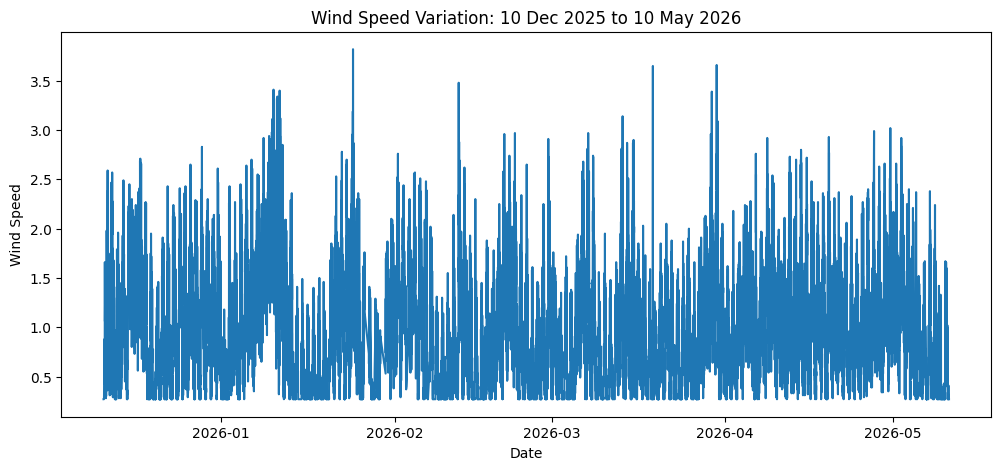

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
file_path = "/content/royapuram_10Dec2025_to_10May2026.csv"
df = pd.read_csv(file_path)

# -----------------------------
# 1. Basic dataset analysis
# -----------------------------

print("Original Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())

print("\nMissing values before cleaning:")
print(df.isnull().sum())

print("\nDataset information:")
print(df.info())

print("\nStatistical summary:")
print(df.describe())

# -----------------------------
# 2. Date conversion
# -----------------------------

df["From_Date"] = pd.to_datetime(df["From_Date"], dayfirst=True, errors="coerce")
df["To_Date"] = pd.to_datetime(df["To_Date"], dayfirst=True, errors="coerce")

# -----------------------------
# 3. Convert numeric columns
# -----------------------------

numeric_cols = ["PM2_5", "PM10", "RH", "WS", "WD", "SR"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# -----------------------------
# 4. Remove duplicate rows
# -----------------------------

df = df.drop_duplicates()

# -----------------------------
# 5. Remove invalid dates
# -----------------------------

df = df.dropna(subset=["From_Date"])

# -----------------------------
# 6. Sort by date
# -----------------------------

df = df.sort_values("From_Date")

# -----------------------------
# 7. Invalid value treatment
# -----------------------------

# PM values should not be negative
df.loc[df["PM2_5"] < 0, "PM2_5"] = np.nan
df.loc[df["PM10"] < 0, "PM10"] = np.nan

# Relative humidity should be 0–100 %
df.loc[(df["RH"] < 0) | (df["RH"] > 100), "RH"] = np.nan

# Wind speed should not be negative
df.loc[(df["WS"] < 0) | (df["WS"] > 50), "WS"] = np.nan

# Wind direction should be 0–360 degrees
df.loc[(df["WD"] < 0) | (df["WD"] > 360), "WD"] = np.nan

# Solar radiation should not be negative
df.loc[df["SR"] < 0, "SR"] = np.nan

# -----------------------------
# 8. Missing value interpolation
# -----------------------------

df = df.set_index("From_Date")

df[numeric_cols] = df[numeric_cols].interpolate(
    method="time",
    limit_direction="both"
)

df = df.reset_index()

# -----------------------------
# 9. Feature engineering
# -----------------------------

df["Year"] = df["From_Date"].dt.year
df["Month"] = df["From_Date"].dt.month
df["Day"] = df["From_Date"].dt.day
df["Hour"] = df["From_Date"].dt.hour
df["Minute"] = df["From_Date"].dt.minute
df["DayOfWeek"] = df["From_Date"].dt.dayofweek

# Wind direction conversion
df["WD_rad"] = np.deg2rad(df["WD"])
df["WD_sin"] = np.sin(df["WD_rad"])
df["WD_cos"] = np.cos(df["WD_rad"])
df = df.drop(columns=["WD_rad"])

# -----------------------------
# 10. Lag features for wind speed
# -----------------------------

df["WS_lag_1"] = df["WS"].shift(1)      # previous 15 min
df["WS_lag_4"] = df["WS"].shift(4)      # previous 1 hour
df["WS_lag_8"] = df["WS"].shift(8)      # previous 2 hours
df["WS_lag_96"] = df["WS"].shift(96)    # previous 24 hours

# Rolling features
df["WS_rolling_1hr"] = df["WS"].rolling(window=4).mean()
df["WS_rolling_3hr"] = df["WS"].rolling(window=12).mean()
df["WS_rolling_24hr"] = df["WS"].rolling(window=96).mean()

# -----------------------------
# 11. Remove NaN after lag creation
# -----------------------------

df_cleaned = df.dropna()

# -----------------------------
# 12. Final dataset analysis
# -----------------------------

print("\nCleaned Shape:", df_cleaned.shape)

print("\nMissing values after cleaning:")
print(df_cleaned.isnull().sum())

print("\nCleaned dataset preview:")
print(df_cleaned.head())

print("\nDate range:")
print(df_cleaned["From_Date"].min())
print(df_cleaned["From_Date"].max())

# -----------------------------
# 13. Save cleaned file
# -----------------------------

df_cleaned.to_csv("royapuram_10Dec2025_to_10May2026_cleaned.csv", index=False)

print("\nSaved successfully:")
print("royapuram_10Dec2025_to_10May2026_cleaned.csv")

# -----------------------------
# 14. Basic visualization
# -----------------------------

plt.figure(figsize=(12,5))
plt.plot(df_cleaned["From_Date"], df_cleaned["WS"])
plt.xlabel("Date")
plt.ylabel("Wind Speed")
plt.title("Wind Speed Variation: 10 Dec 2025 to 10 May 2026")
plt.show()


Original shape: (14496, 23)


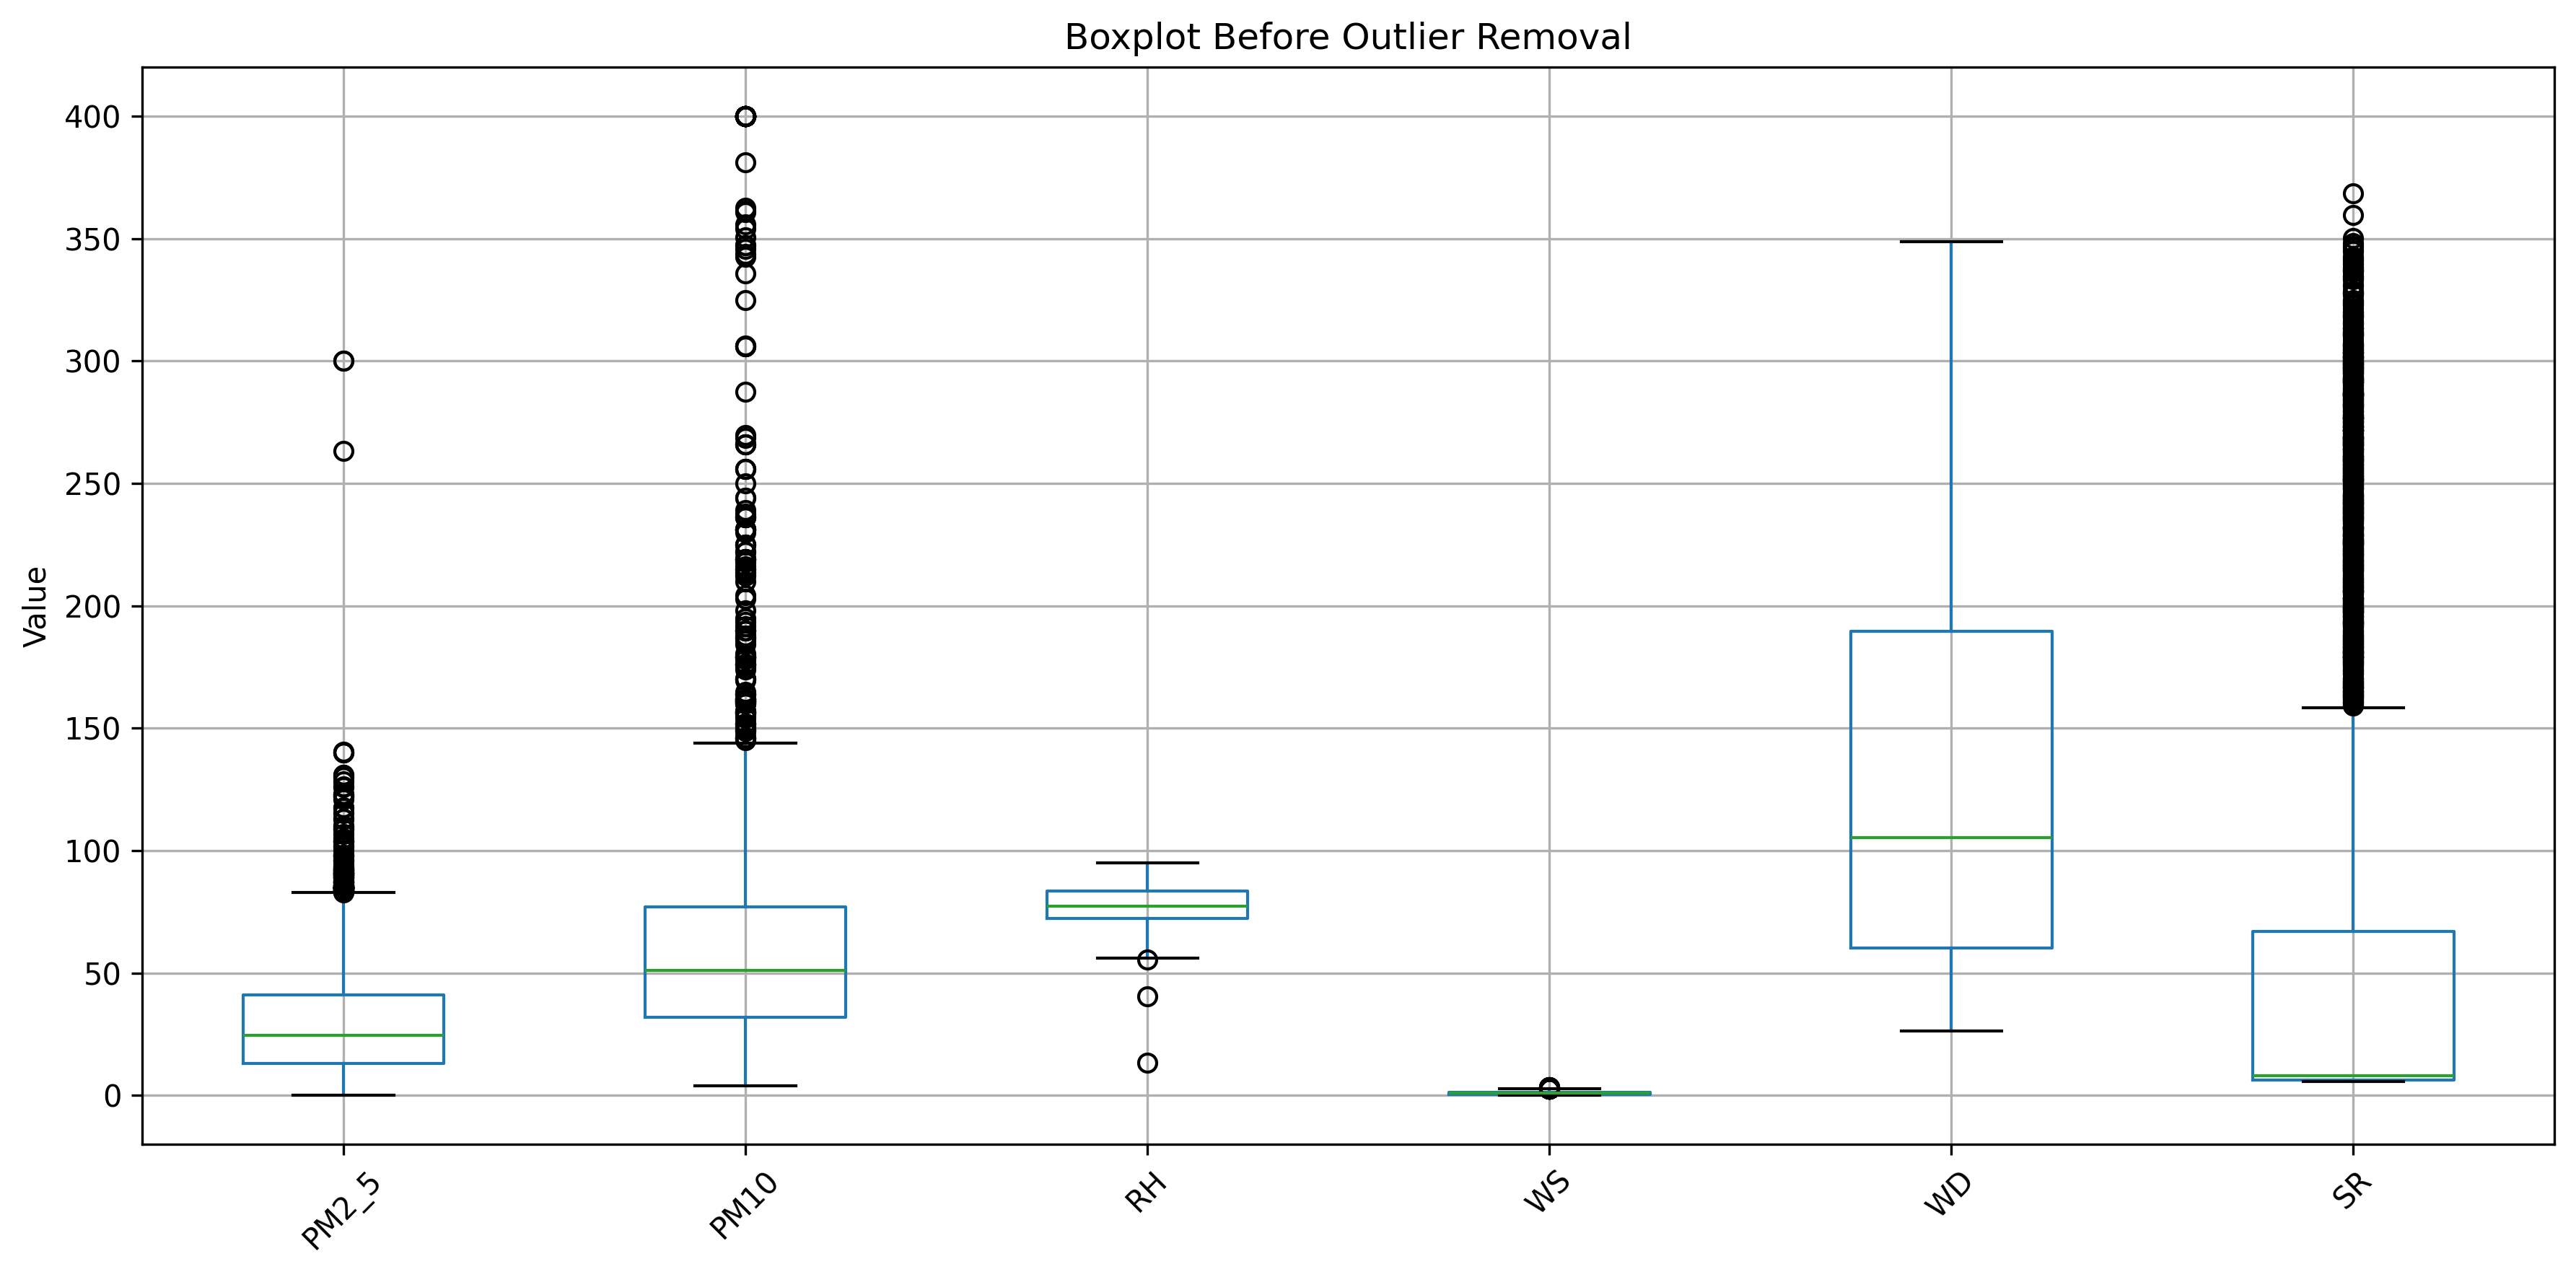


Outlier removal summary:
  Variable       Q1        Q3       IQR  Lower_Limit  Upper_Limit  \
0    PM2_5  13.0000   41.0000   28.0000    -29.00000     83.00000   
1     PM10  32.0000   73.7500   41.7500    -30.62500    136.37500   
2       RH  72.4400   83.5525   11.1125     55.77125    100.22125   
3       WS   0.5000    1.3700    0.8700     -0.80500      2.67500   
4       WD  58.7175  182.0850  123.3675   -126.33375    367.13625   
5       SR   6.2000   69.8150   63.6150    -89.22250    165.23750   

   Outliers_Removed  
0               153  
1               190  
2                 2  
3                38  
4                 0  
5               816  

Shape after outlier removal: (4556, 23)


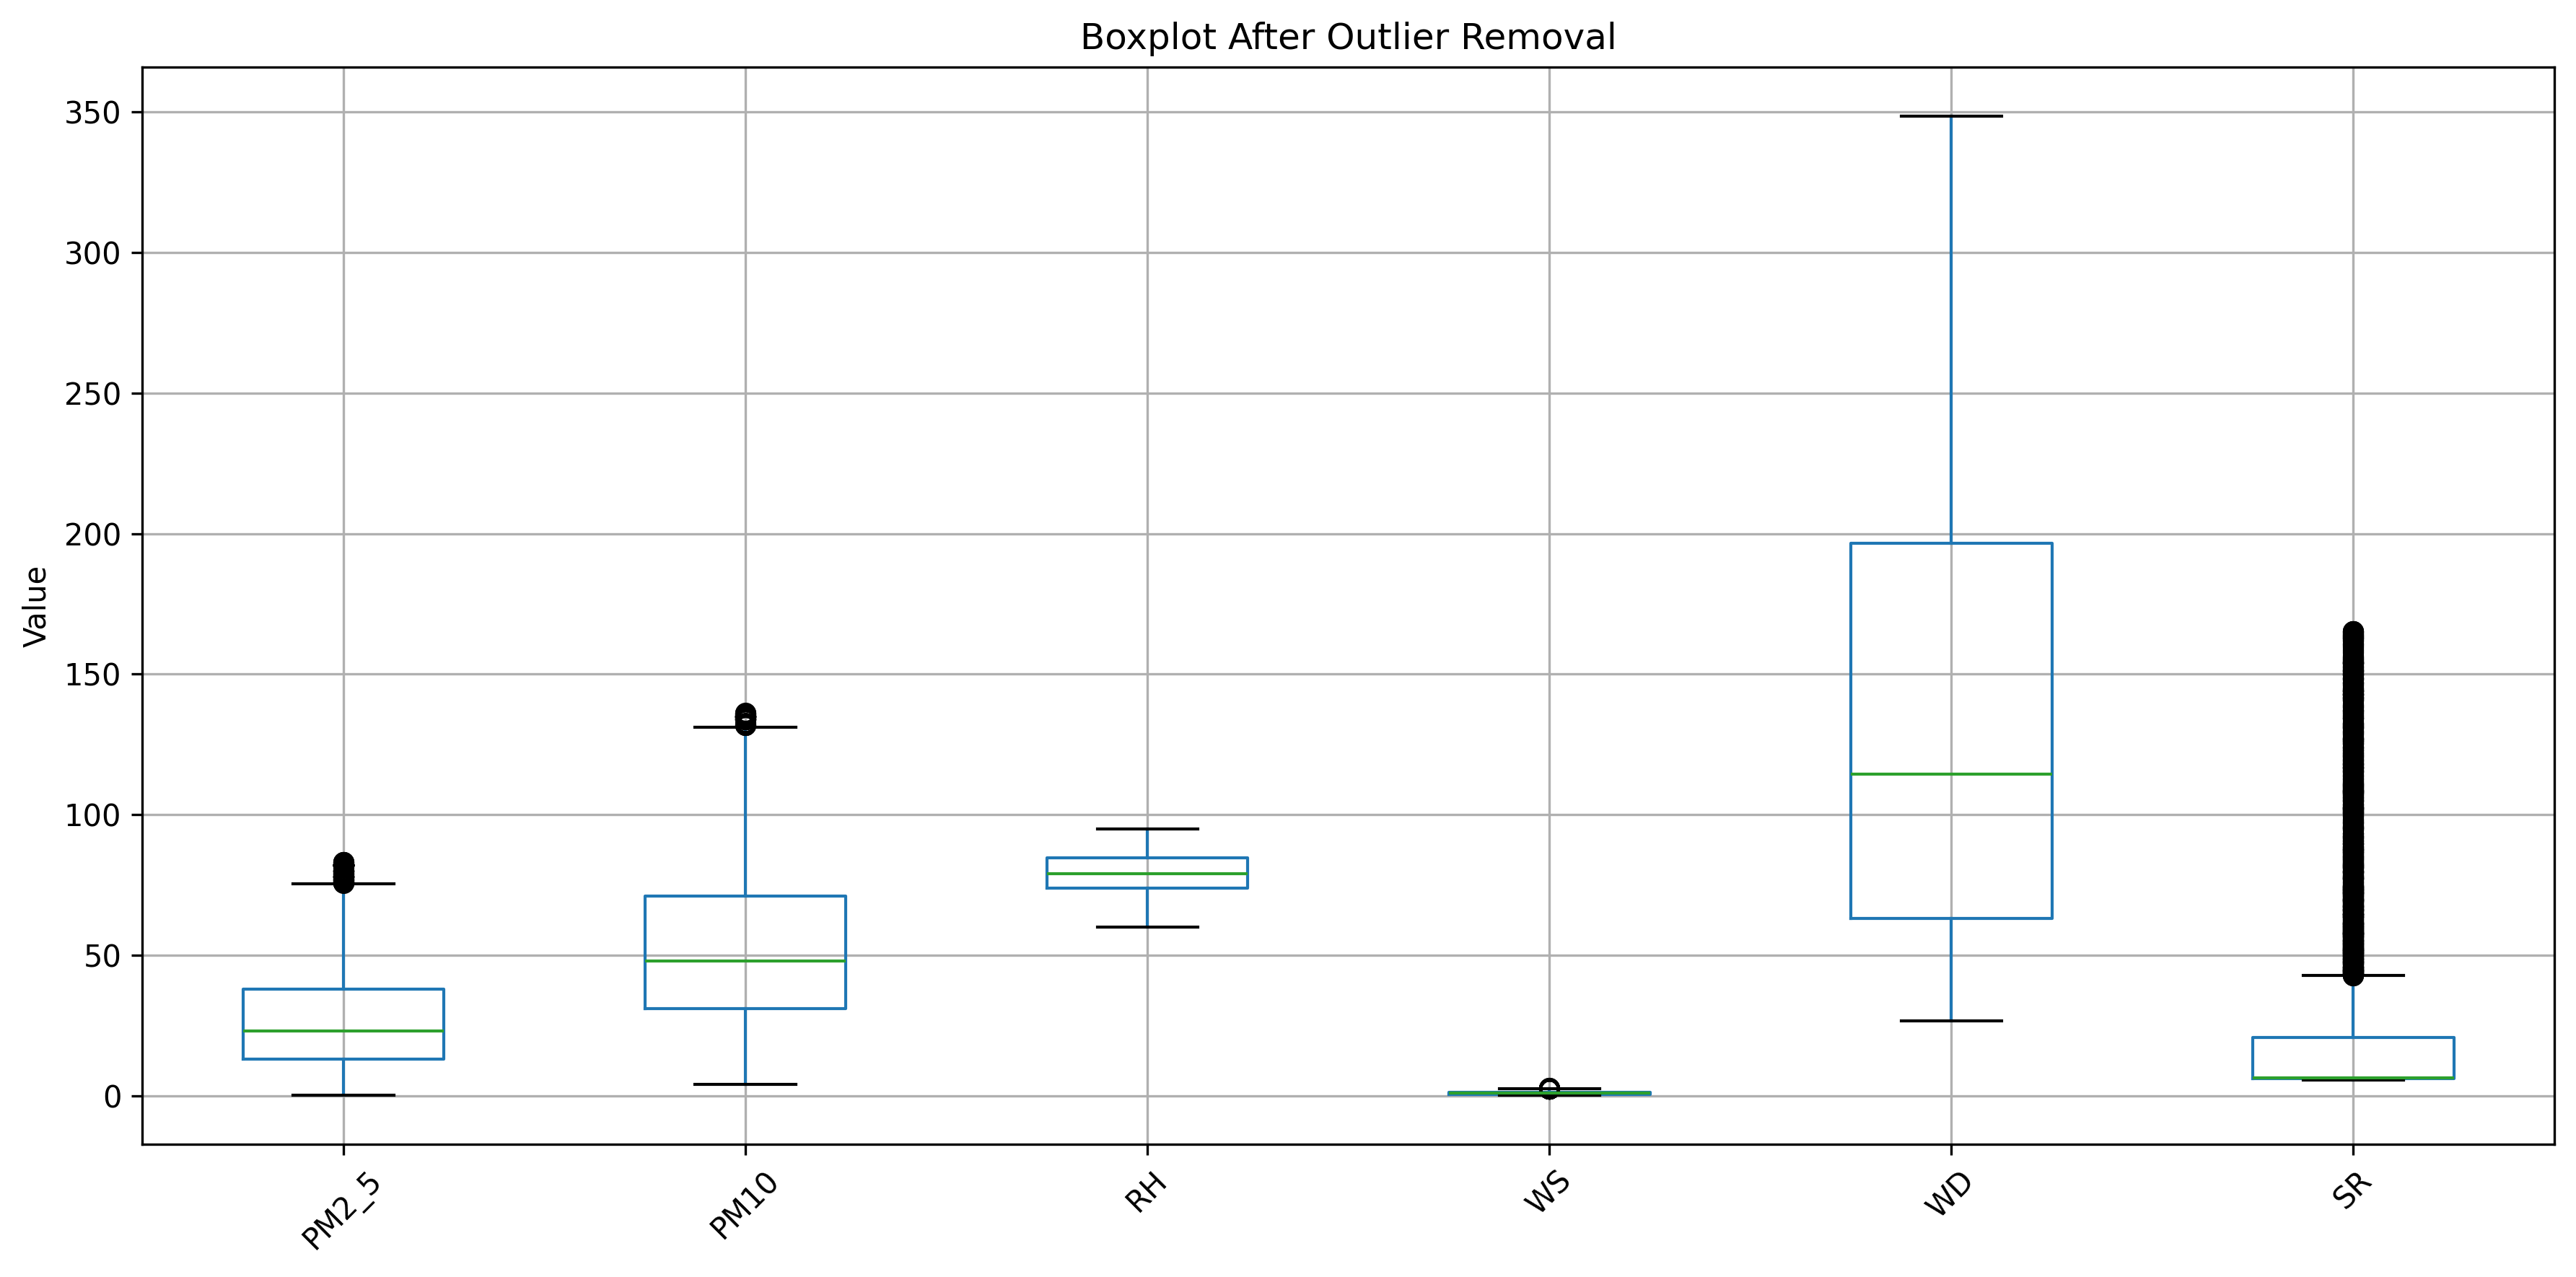

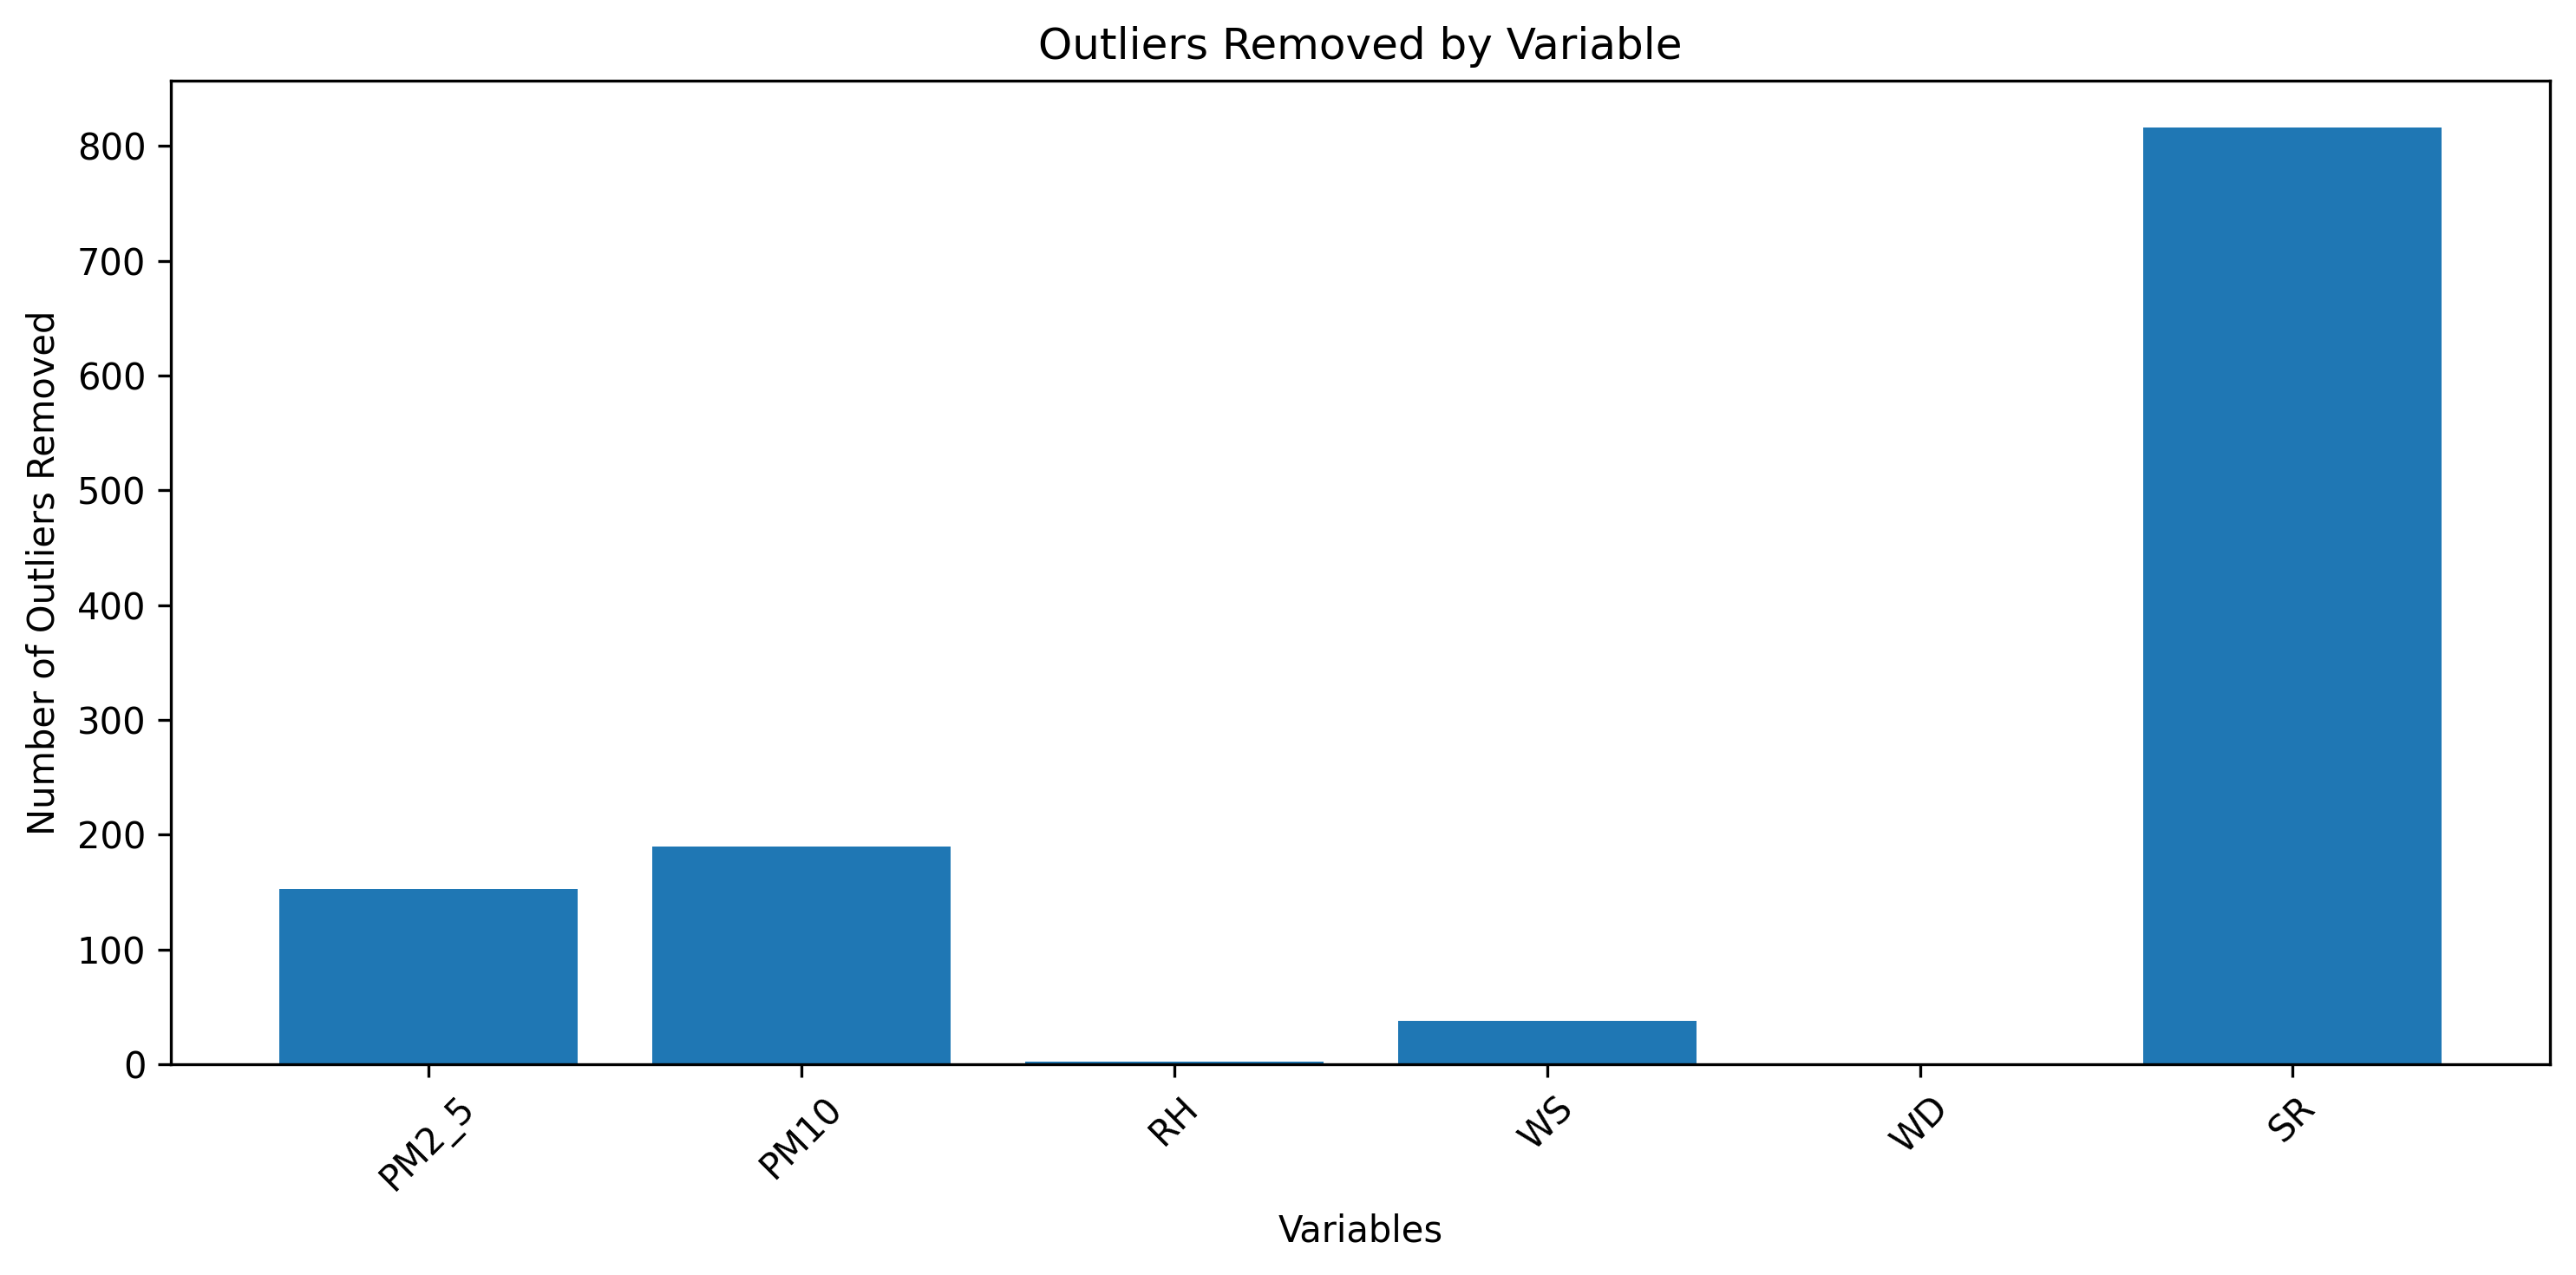

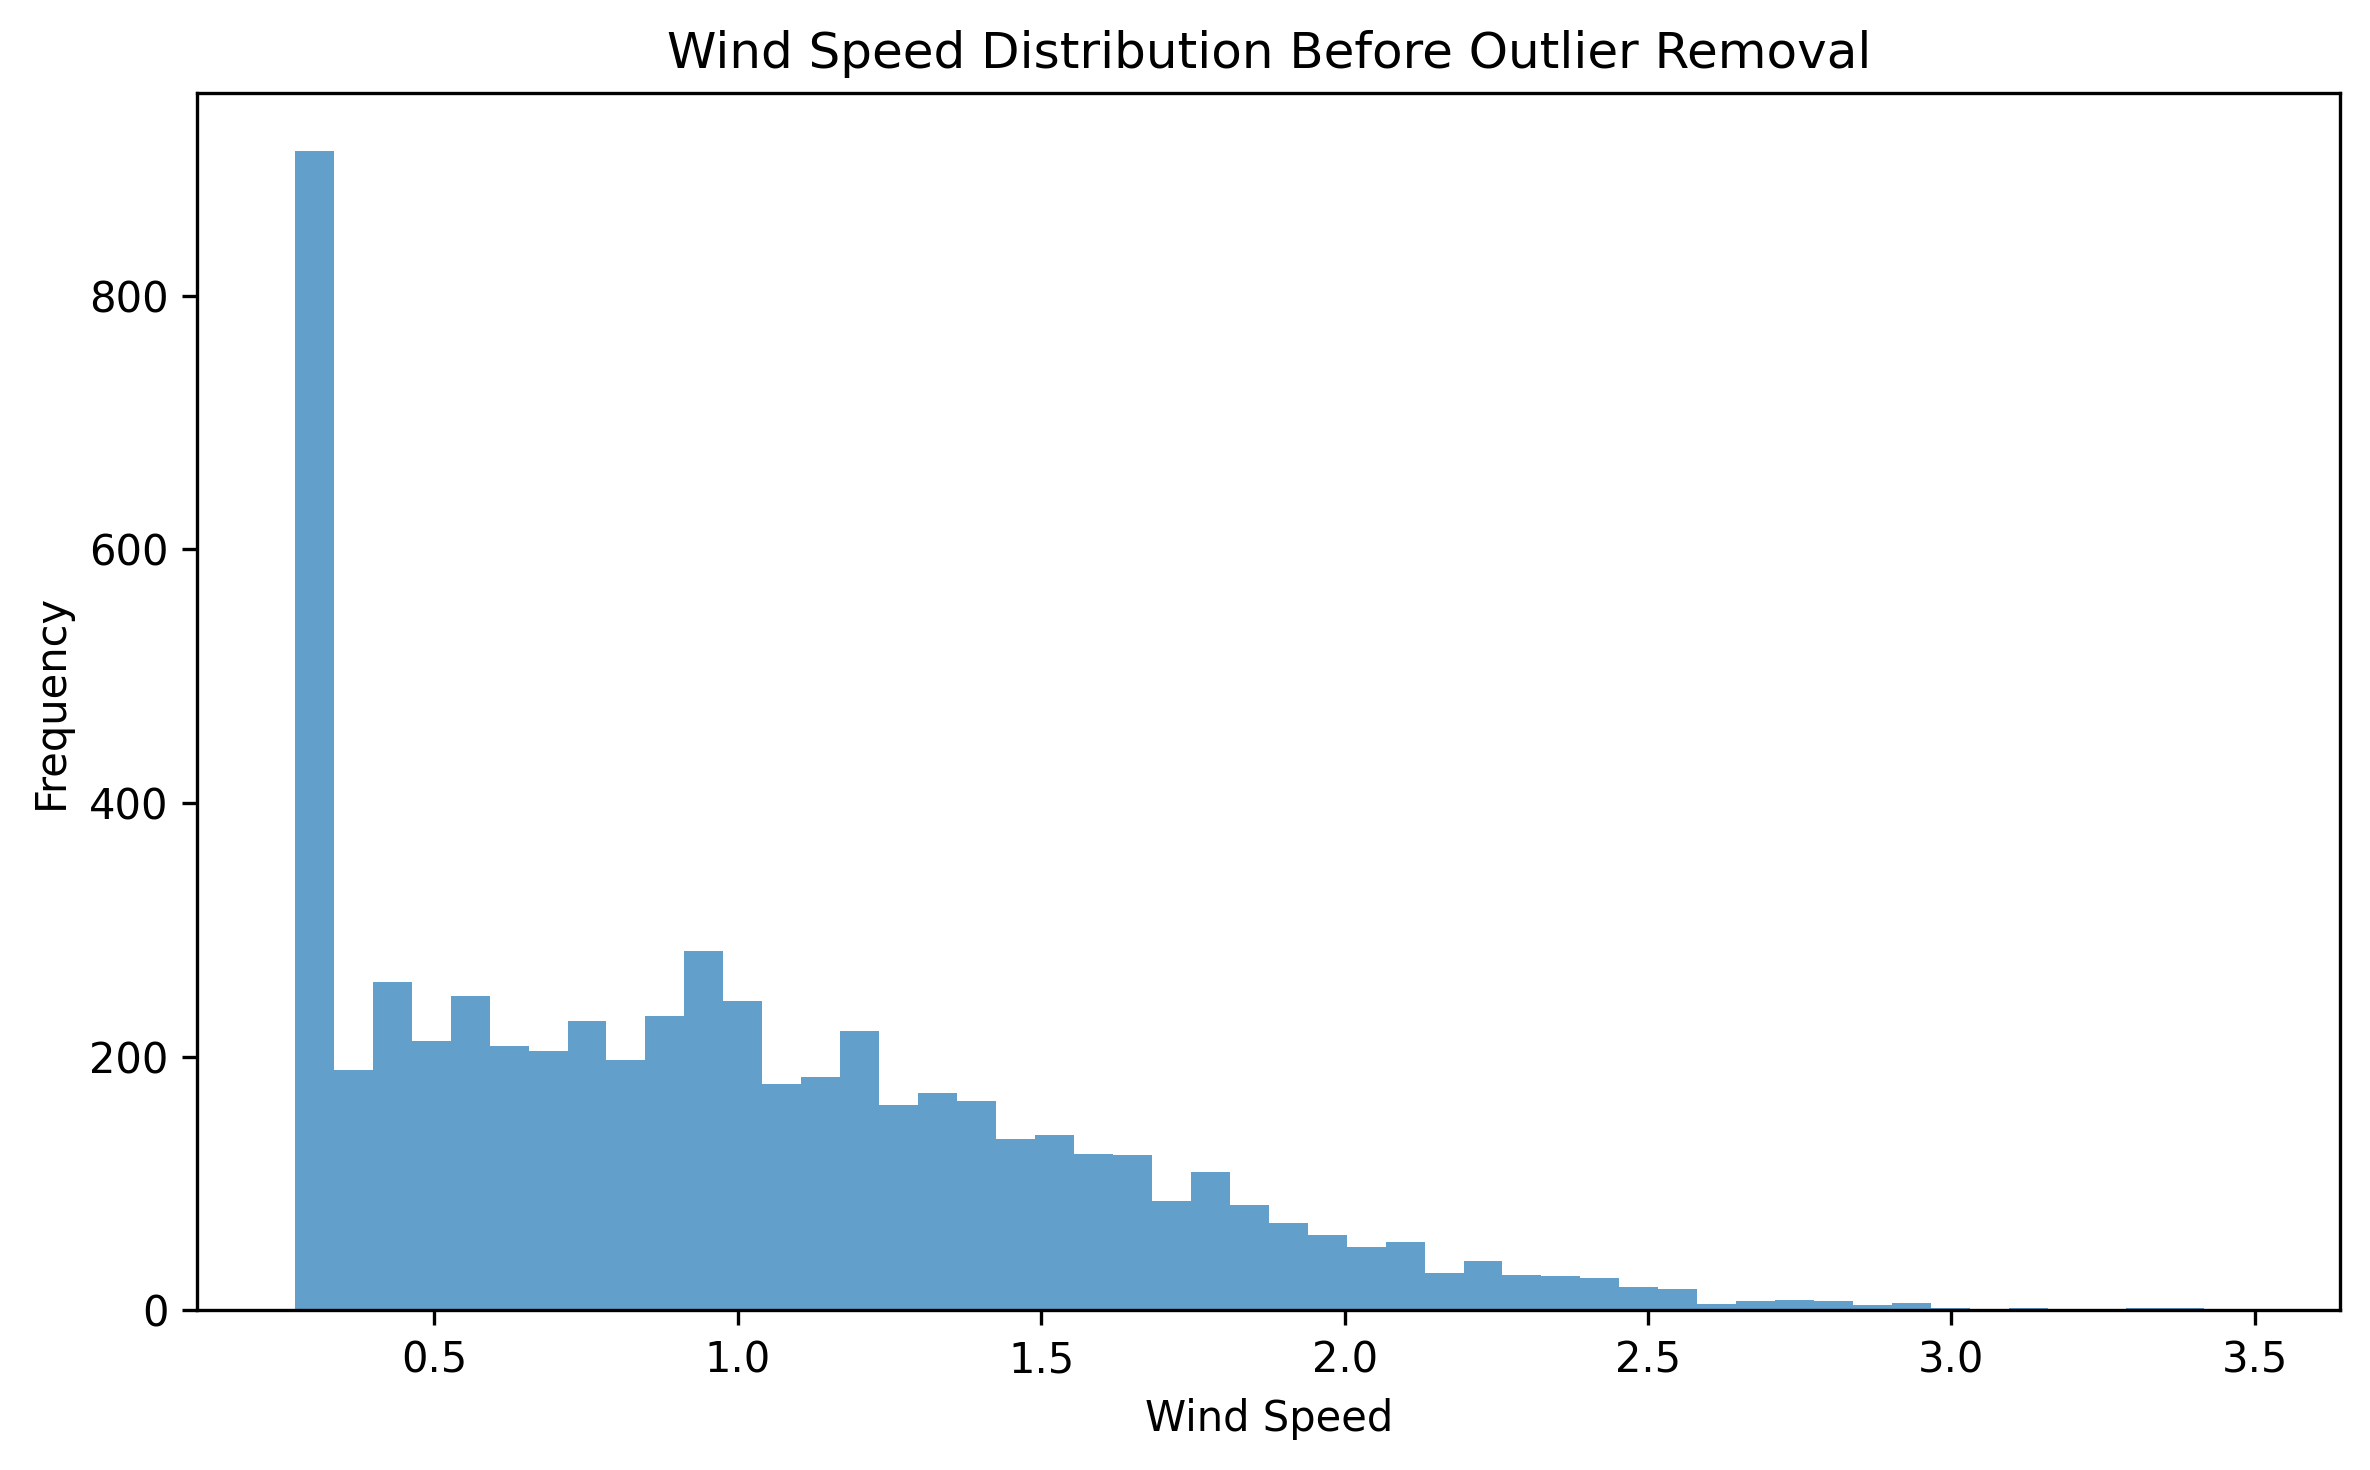

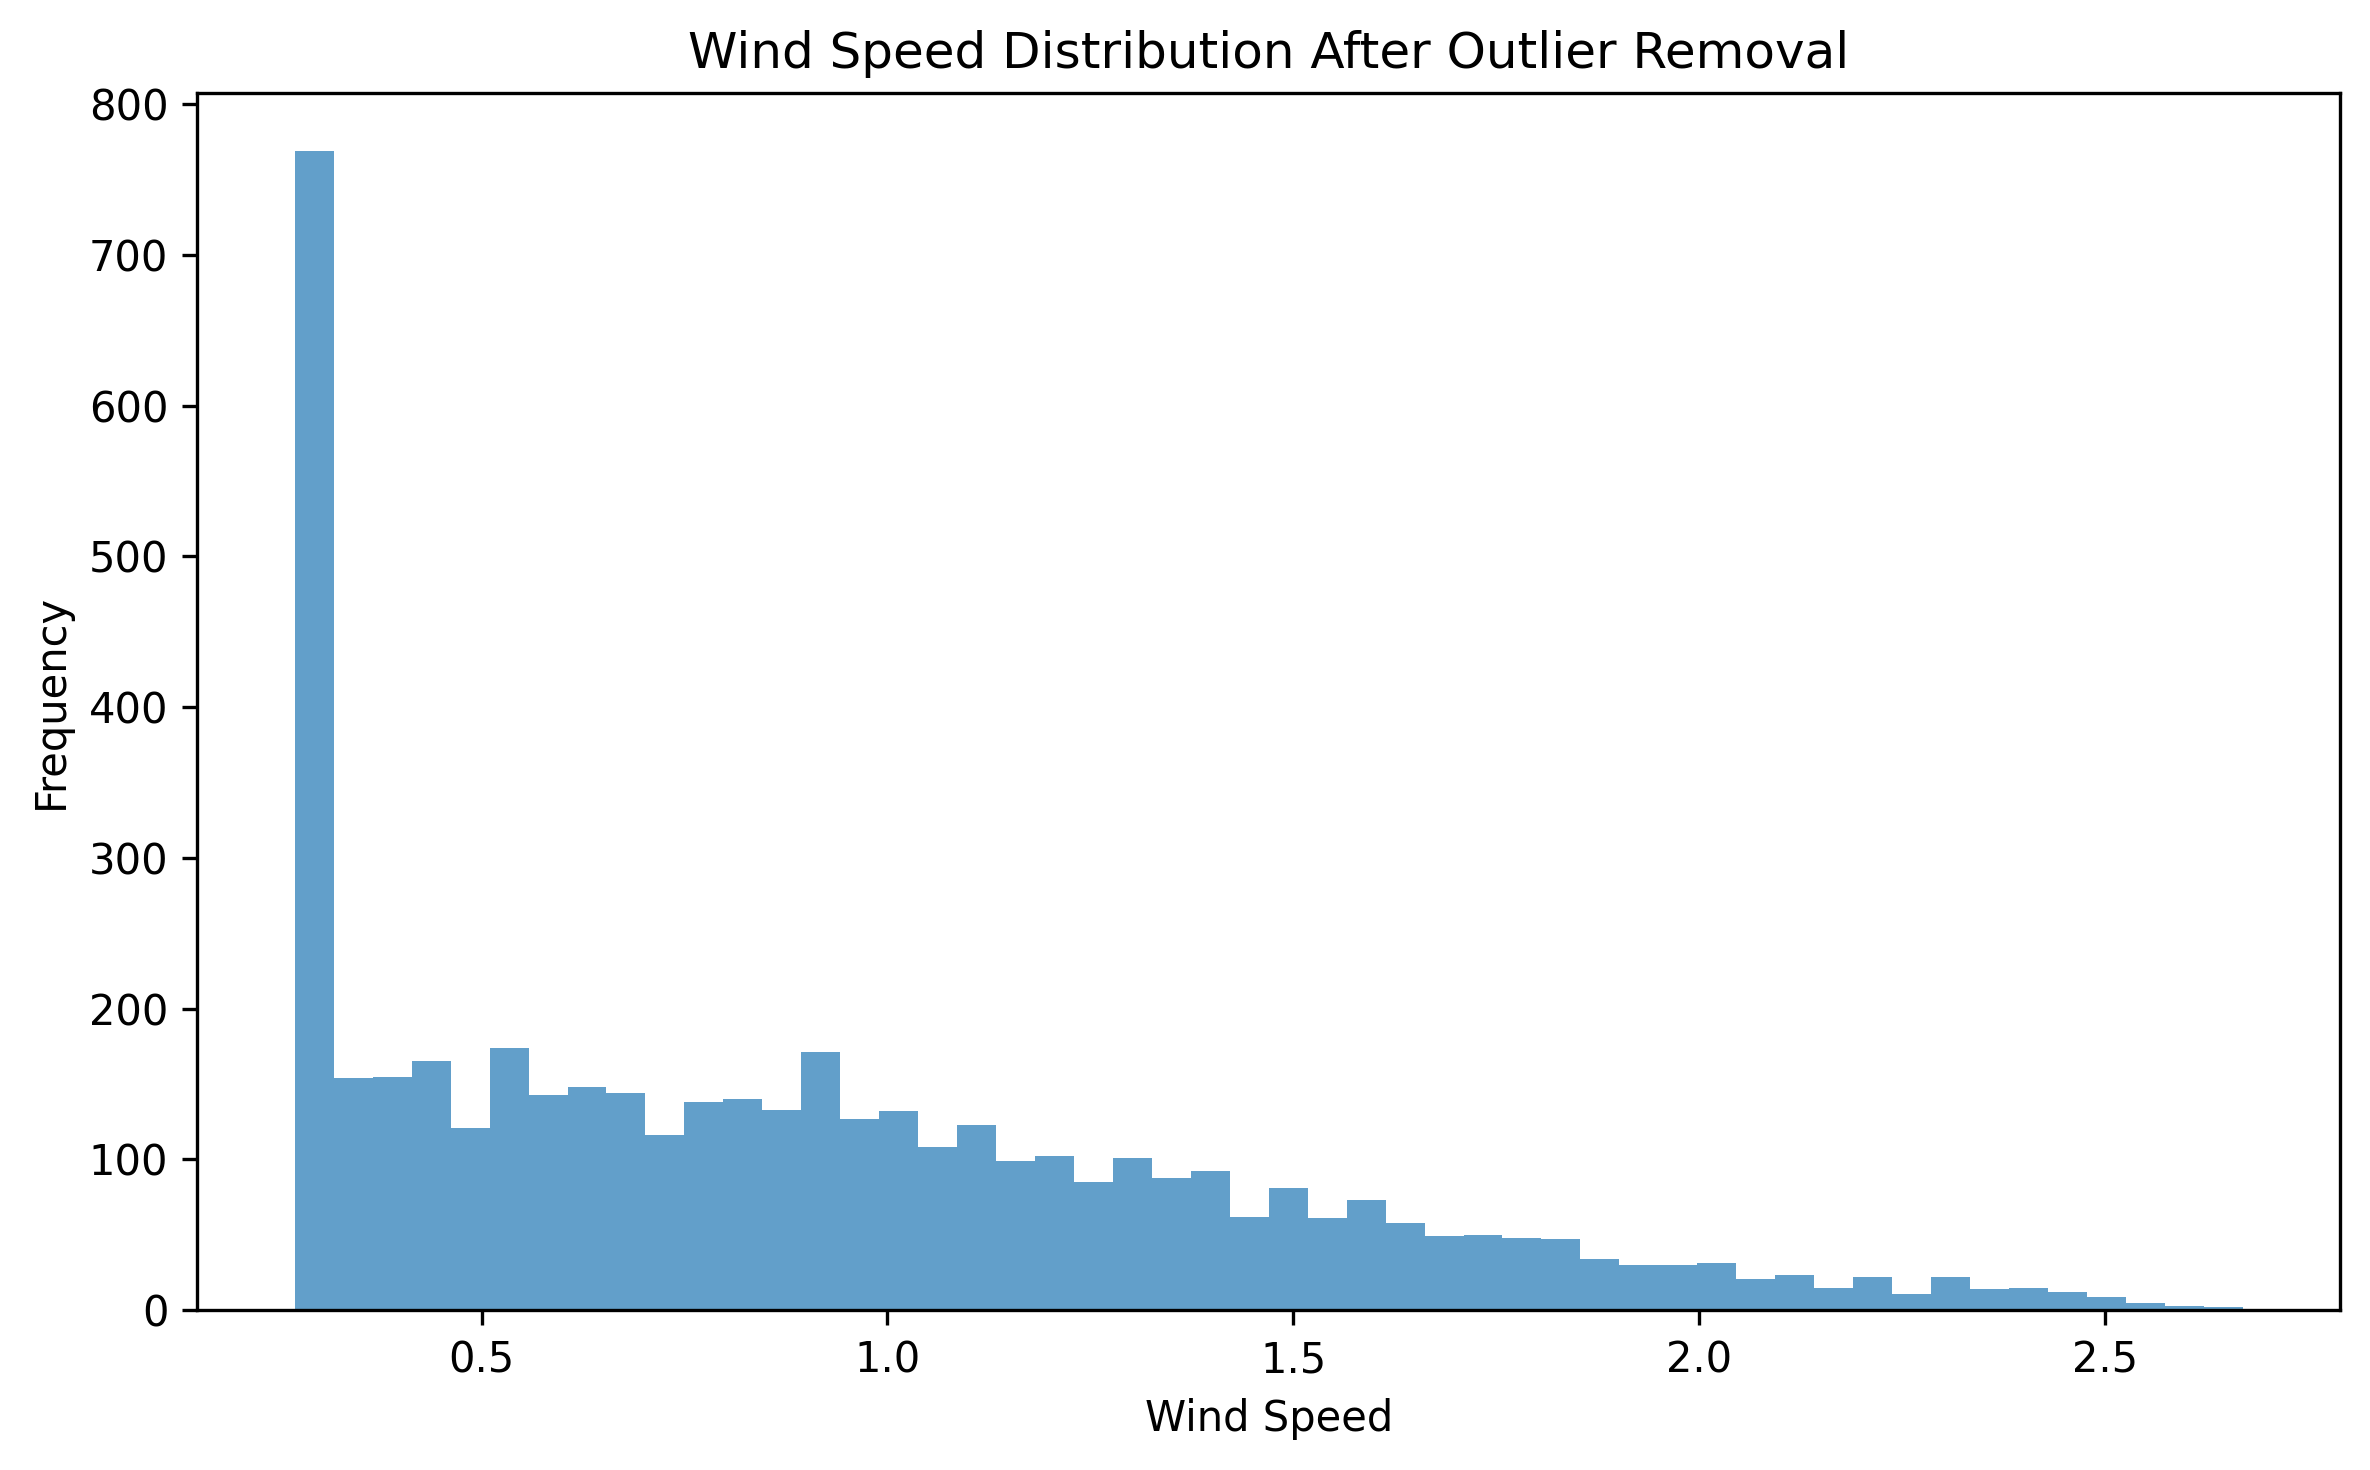


Missing values after outlier removal:
From_Date          0
To_Date            0
PM2_5              0
PM10               0
RH                 0
WS                 0
WD                 0
SR                 0
Year               0
Month              0
Day                0
Hour               0
Minute             0
DayOfWeek          0
WD_sin             0
WD_cos             0
WS_lag_1           0
WS_lag_4           0
WS_lag_8           0
WS_lag_96          0
WS_rolling_1hr     0
WS_rolling_3hr     0
WS_rolling_24hr    0
dtype: int64

Files saved successfully:
1. royapuram_10Dec2025_to_10May2026_no_outliers.csv
2. outlier_removal_summary.csv
3. boxplot_before_outlier_removal.png
4. boxplot_after_outlier_removal.png
5. outlier_count_bar_chart.png
6. wind_speed_distribution_before.png
7. wind_speed_distribution_after.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# 1. LOAD DATASET
# =====================================================

df = pd.read_csv("/content/royapuram_10Dec2025_to_10May2026_cleaned.csv")

print("Original shape:", df.shape)

df["From_Date"] = pd.to_datetime(df["From_Date"], errors="coerce")
df["To_Date"] = pd.to_datetime(df["To_Date"], errors="coerce")

df = df.dropna(subset=["From_Date", "To_Date"])
df = df.sort_values("From_Date").reset_index(drop=True)

# =====================================================
# 2. SELECT COLUMNS FOR OUTLIER ANALYSIS
# =====================================================

cols = ["PM2_5", "PM10", "RH", "WS", "WD", "SR"]

# =====================================================
# 3. BOXPLOT BEFORE OUTLIER REMOVAL
# =====================================================

plt.figure(figsize=(12, 6), dpi=300)
df[cols].boxplot()
plt.title("Boxplot Before Outlier Removal")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("boxplot_before_outlier_removal.png", dpi=300, bbox_inches="tight")
plt.show()

# =====================================================
# 4. REMOVE OUTLIERS USING IQR METHOD
# =====================================================

df_no_outliers = df.copy()
outlier_summary = []

for col in cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    before_count = df_no_outliers.shape[0]

    df_no_outliers = df_no_outliers[
        (df_no_outliers[col] >= lower_limit) &
        (df_no_outliers[col] <= upper_limit)
    ]

    after_count = df_no_outliers.shape[0]
    removed_count = before_count - after_count

    outlier_summary.append({
        "Variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Limit": lower_limit,
        "Upper_Limit": upper_limit,
        "Outliers_Removed": removed_count
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

print("\nOutlier removal summary:")
print(outlier_summary_df)

print("\nShape after outlier removal:", df_no_outliers.shape)

# =====================================================
# 5. BOXPLOT AFTER OUTLIER REMOVAL
# =====================================================

plt.figure(figsize=(12, 6), dpi=300)
df_no_outliers[cols].boxplot()
plt.title("Boxplot After Outlier Removal")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("boxplot_after_outlier_removal.png", dpi=300, bbox_inches="tight")
plt.show()

# =====================================================
# 6. OUTLIER COUNT BAR CHART
# =====================================================

plt.figure(figsize=(10, 5), dpi=300)
plt.bar(
    outlier_summary_df["Variable"],
    outlier_summary_df["Outliers_Removed"]
)
plt.xlabel("Variables")
plt.ylabel("Number of Outliers Removed")
plt.title("Outliers Removed by Variable")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outlier_count_bar_chart.png", dpi=300, bbox_inches="tight")
plt.show()

# =====================================================
# 7. WIND SPEED DISTRIBUTION BEFORE AND AFTER
# =====================================================

plt.figure(figsize=(8, 5), dpi=300)
plt.hist(df["WS"], bins=50, alpha=0.7)
plt.xlabel("Wind Speed")
plt.ylabel("Frequency")
plt.title("Wind Speed Distribution Before Outlier Removal")
plt.tight_layout()
plt.savefig("wind_speed_distribution_before.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5), dpi=300)
plt.hist(df_no_outliers["WS"], bins=50, alpha=0.7)
plt.xlabel("Wind Speed")
plt.ylabel("Frequency")
plt.title("Wind Speed Distribution After Outlier Removal")
plt.tight_layout()
plt.savefig("wind_speed_distribution_after.png", dpi=300, bbox_inches="tight")
plt.show()

# =====================================================
# 8. CHECK MISSING VALUES AFTER OUTLIER REMOVAL
# =====================================================

print("\nMissing values after outlier removal:")
print(df_no_outliers.isnull().sum())

# =====================================================
# 9. SAVE FILES
# =====================================================

df_no_outliers.to_csv(
    "royapuram_10Dec2025_to_10May2026_no_outliers.csv",
    index=False
)

outlier_summary_df.to_csv(
    "outlier_removal_summary.csv",
    index=False
)

print("\nFiles saved successfully:")
print("1. royapuram_10Dec2025_to_10May2026_no_outliers.csv")
print("2. outlier_removal_summary.csv")
print("3. boxplot_before_outlier_removal.png")
print("4. boxplot_after_outlier_removal.png")
print("5. outlier_count_bar_chart.png")
print("6. wind_speed_distribution_before.png")
print("7. wind_speed_distribution_after.png")

# =====================================================
# 10. DOWNLOAD FILES IN COLAB
# =====================================================

from google.colab import files

files.download("royapuram_10Dec2025_to_10May2026_no_outliers.csv")
files.download("outlier_removal_summary.csv")
files.download("boxplot_before_outlier_removal.png")
files.download("boxplot_after_outlier_removal.png")
files.download("outlier_count_bar_chart.png")
files.download("wind_speed_distribution_before.png")
files.download("wind_speed_distribution_after.png")

Dataset shape after loading: (4556, 23)
Number of VMD modes generated: 8
VMD features created:
['VMD_Mode_1', 'VMD_Mode_2', 'VMD_Mode_3', 'VMD_Mode_4', 'VMD_Mode_5', 'VMD_Mode_6', 'VMD_Mode_7', 'VMD_Mode_8', 'VMD_residual']

Correlation with Future Wind Speed:
WS_future       1.000000
WS_roll_4       0.804841
WS_roll_8       0.758733
WS_EMA_12       0.752901
WS_lag_1        0.744886
WS_lag_2        0.714172
VMD_Mode_2      0.709870
WS_roll_12      0.705353
WS_lag_3        0.670275
WS_EMA_24       0.659474
WS_lag_4        0.634281
VMD_Mode_1      0.621350
WS_roll_24      0.558788
WS_EMA_48       0.525184
WS_diff_24      0.507349
WS_lag_8        0.489427
VMD_Mode_3      0.404328
WS_lag_12       0.368763
WS_EMA_96       0.367118
WS_roll_48      0.345655
SR              0.294418
VMD_Mode_4      0.216204
WS_diff_4       0.188216
WS_roll_96      0.135343
VMD_residual    0.127636
WS_lag_24       0.120339
VMD_Mode_5      0.102854
WS_diff_1       0.064844
WD_sin          0.056239
WS_lag_192    

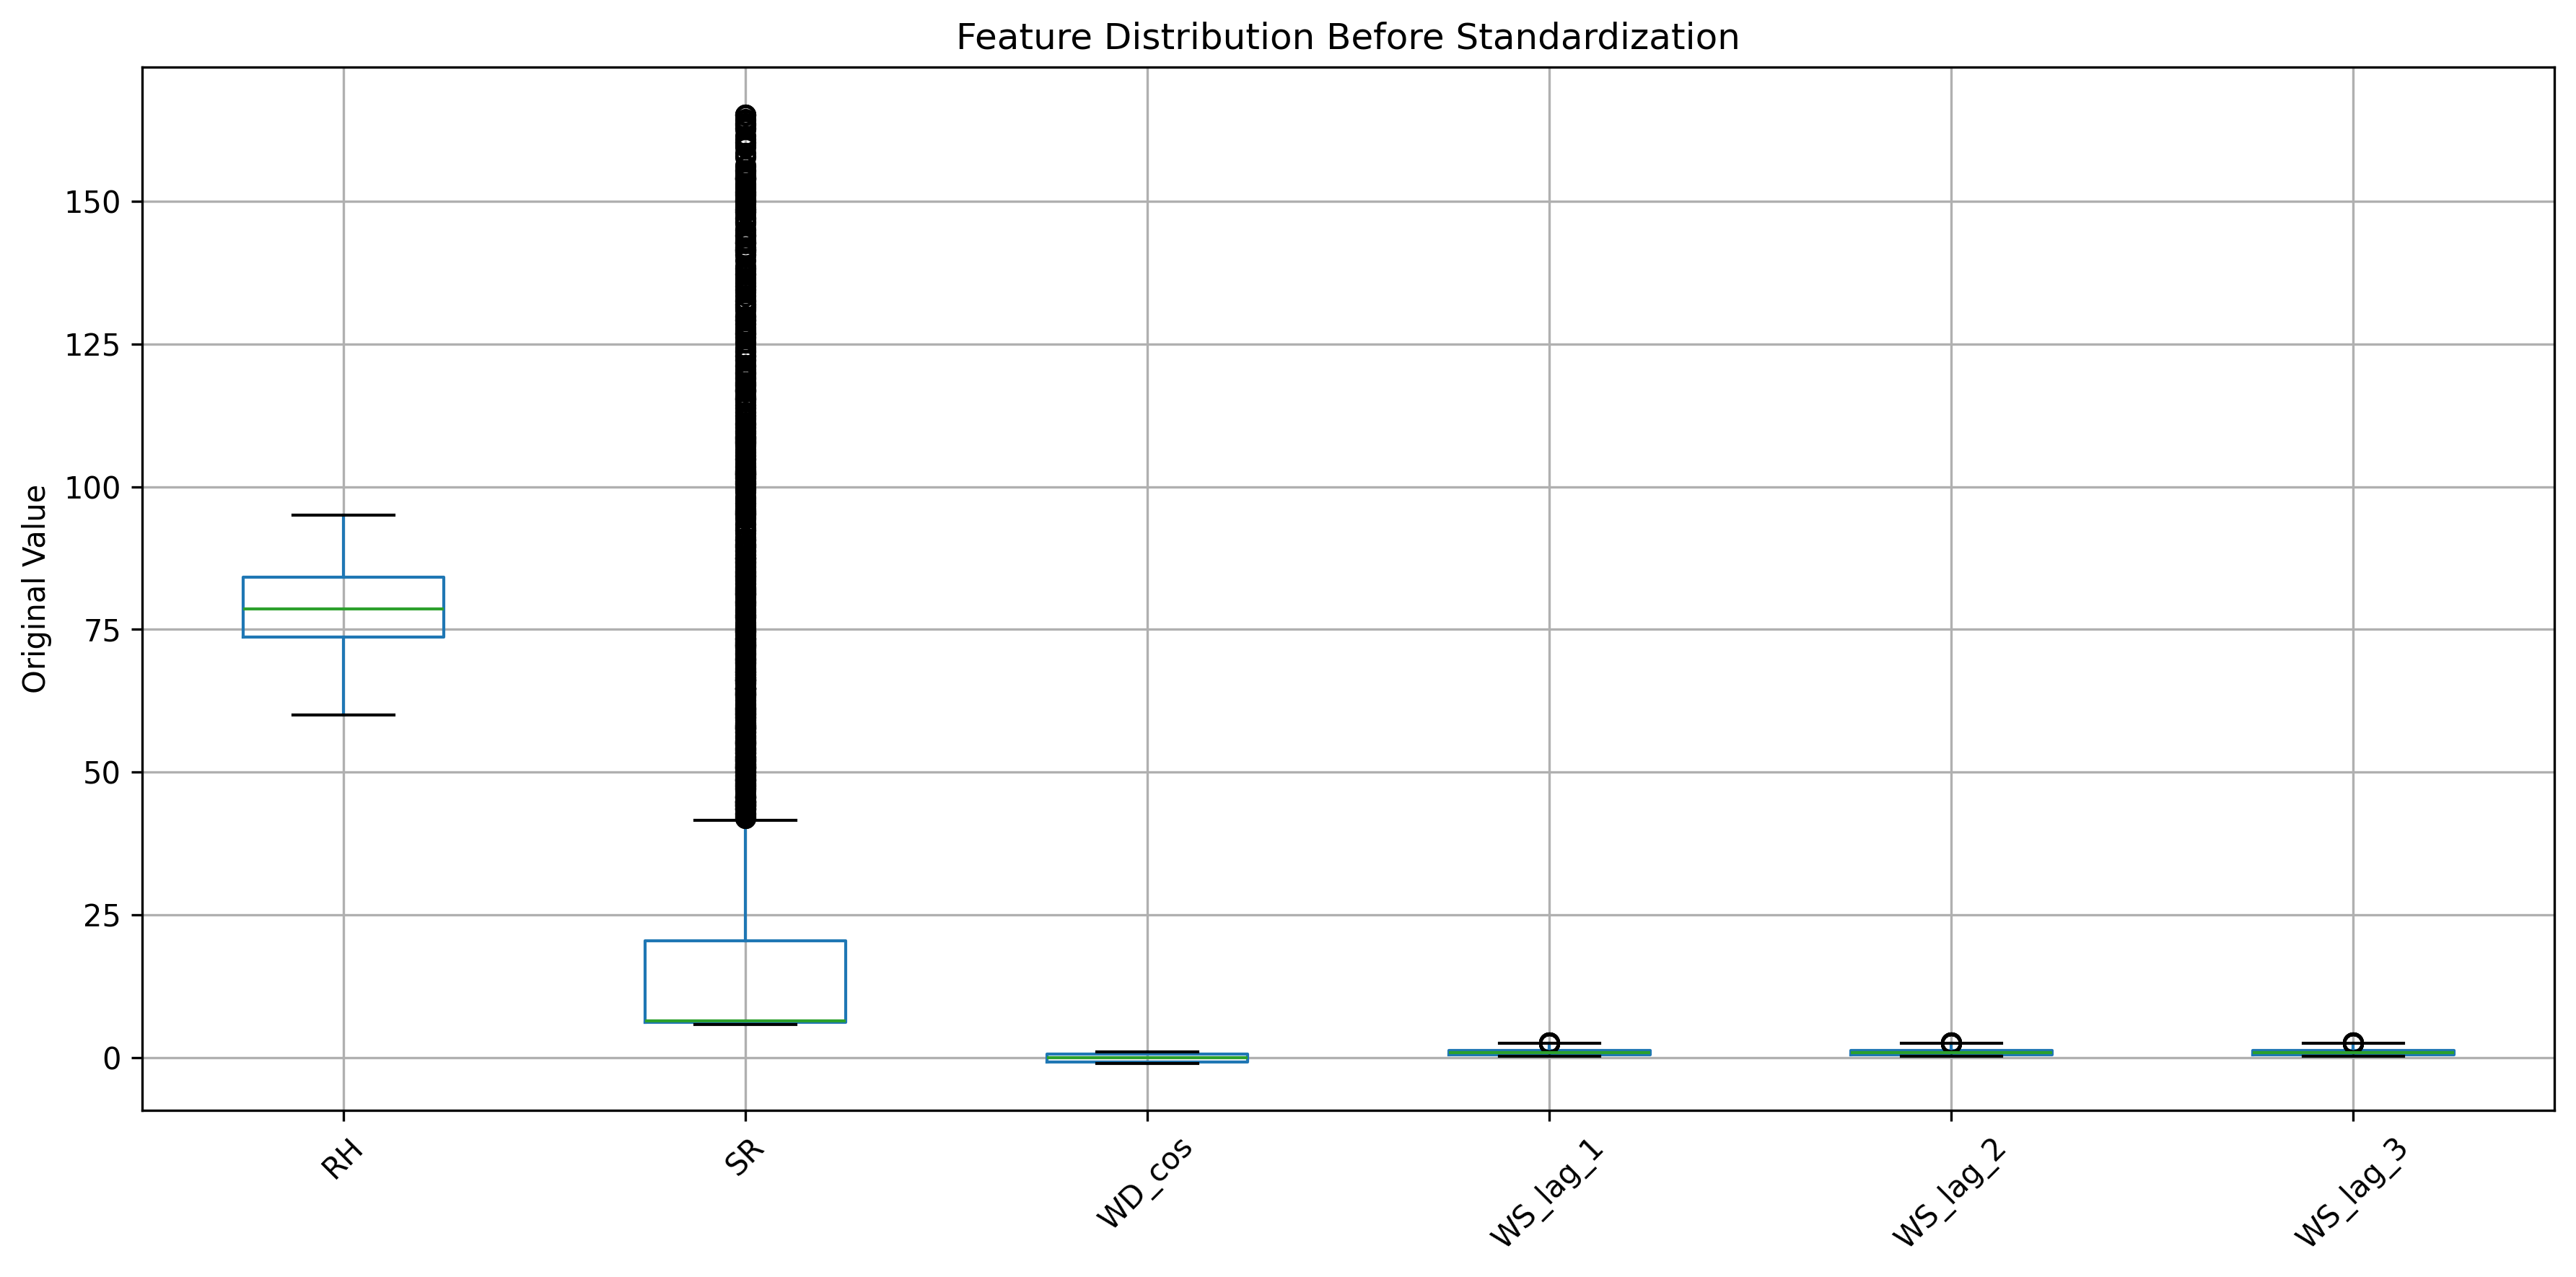

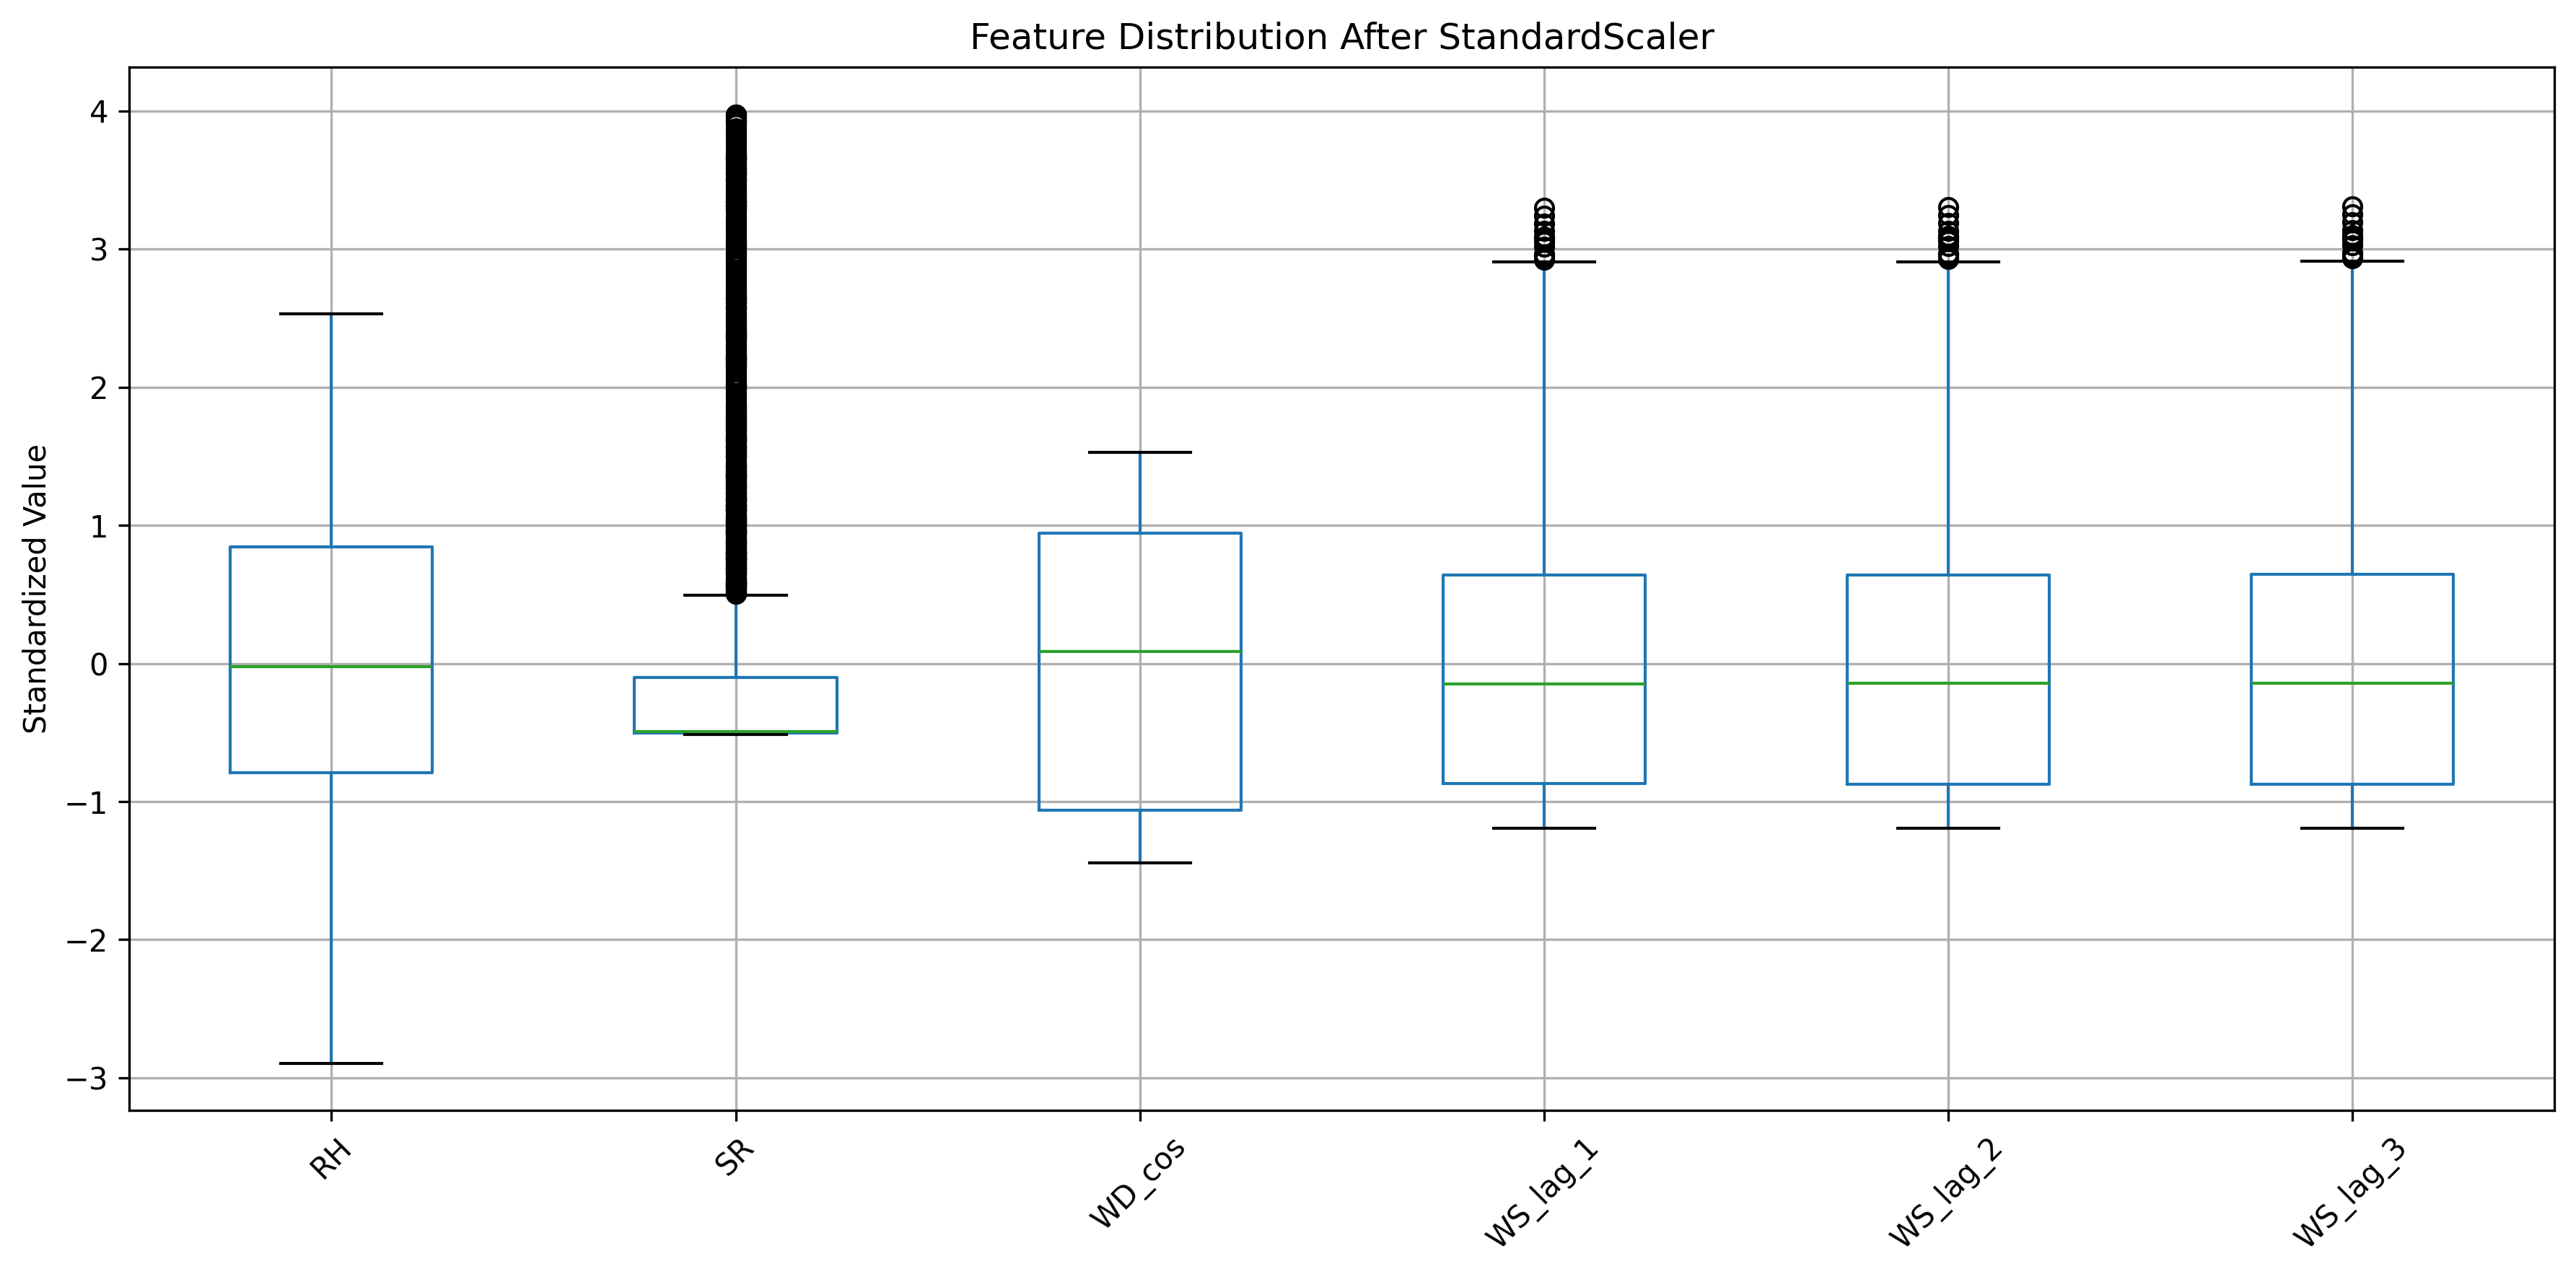

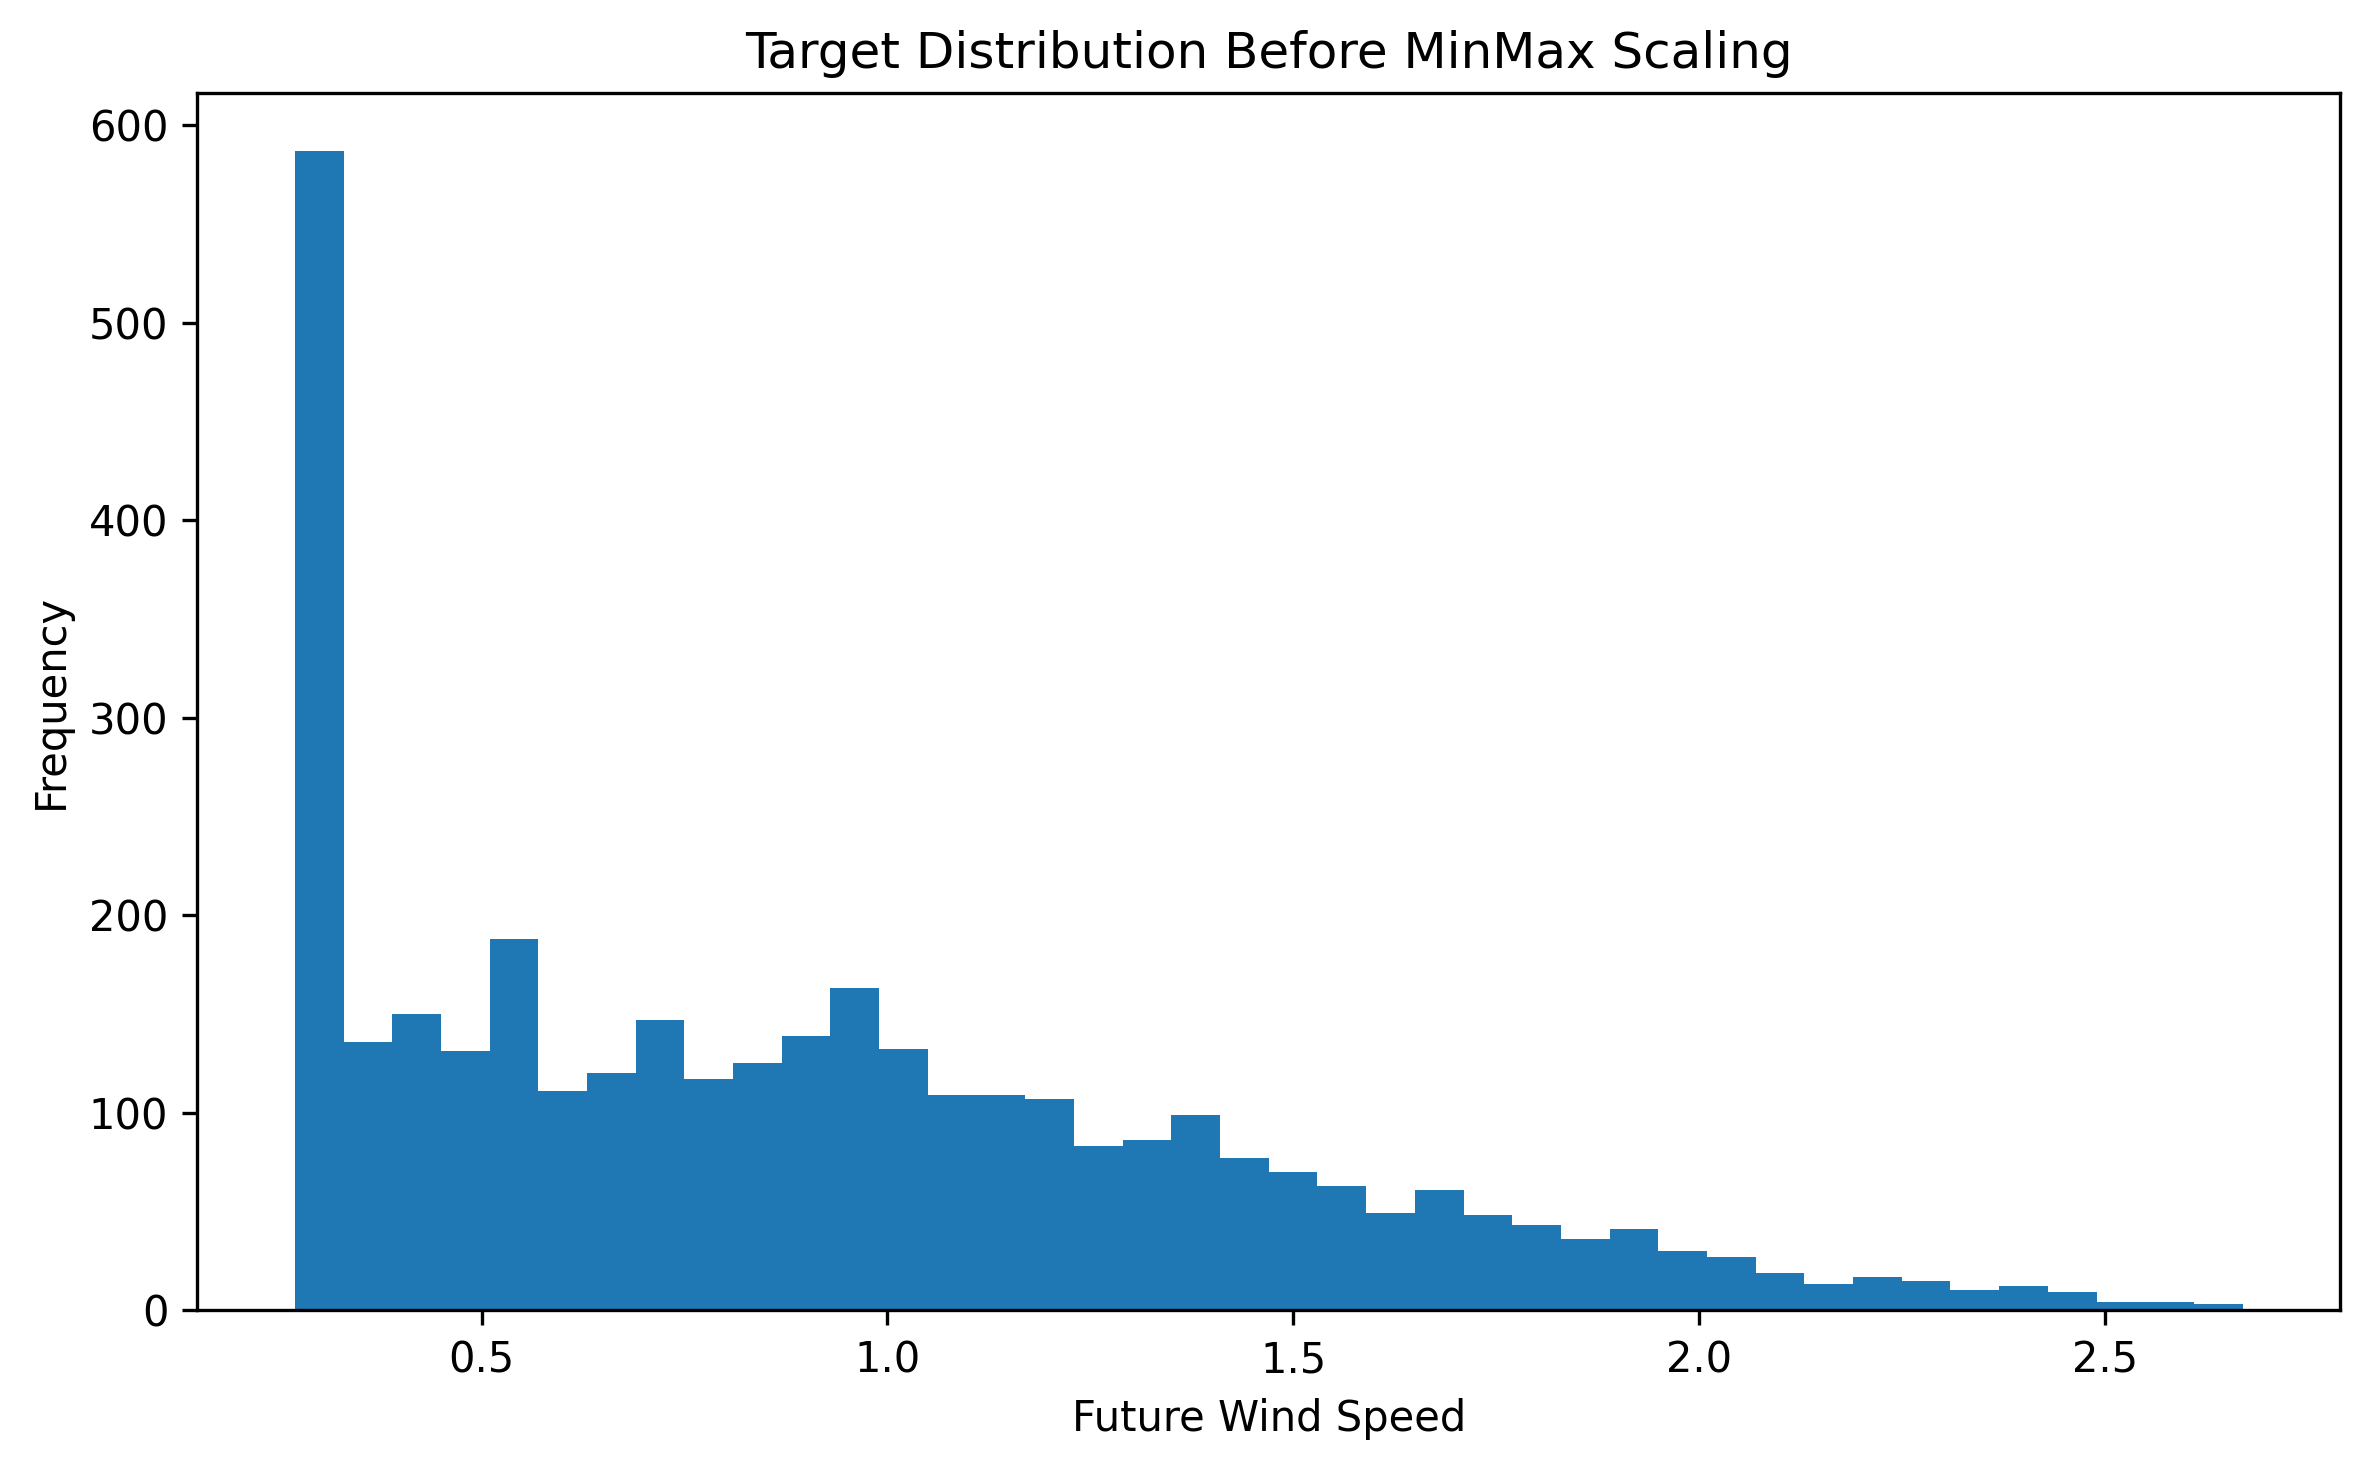

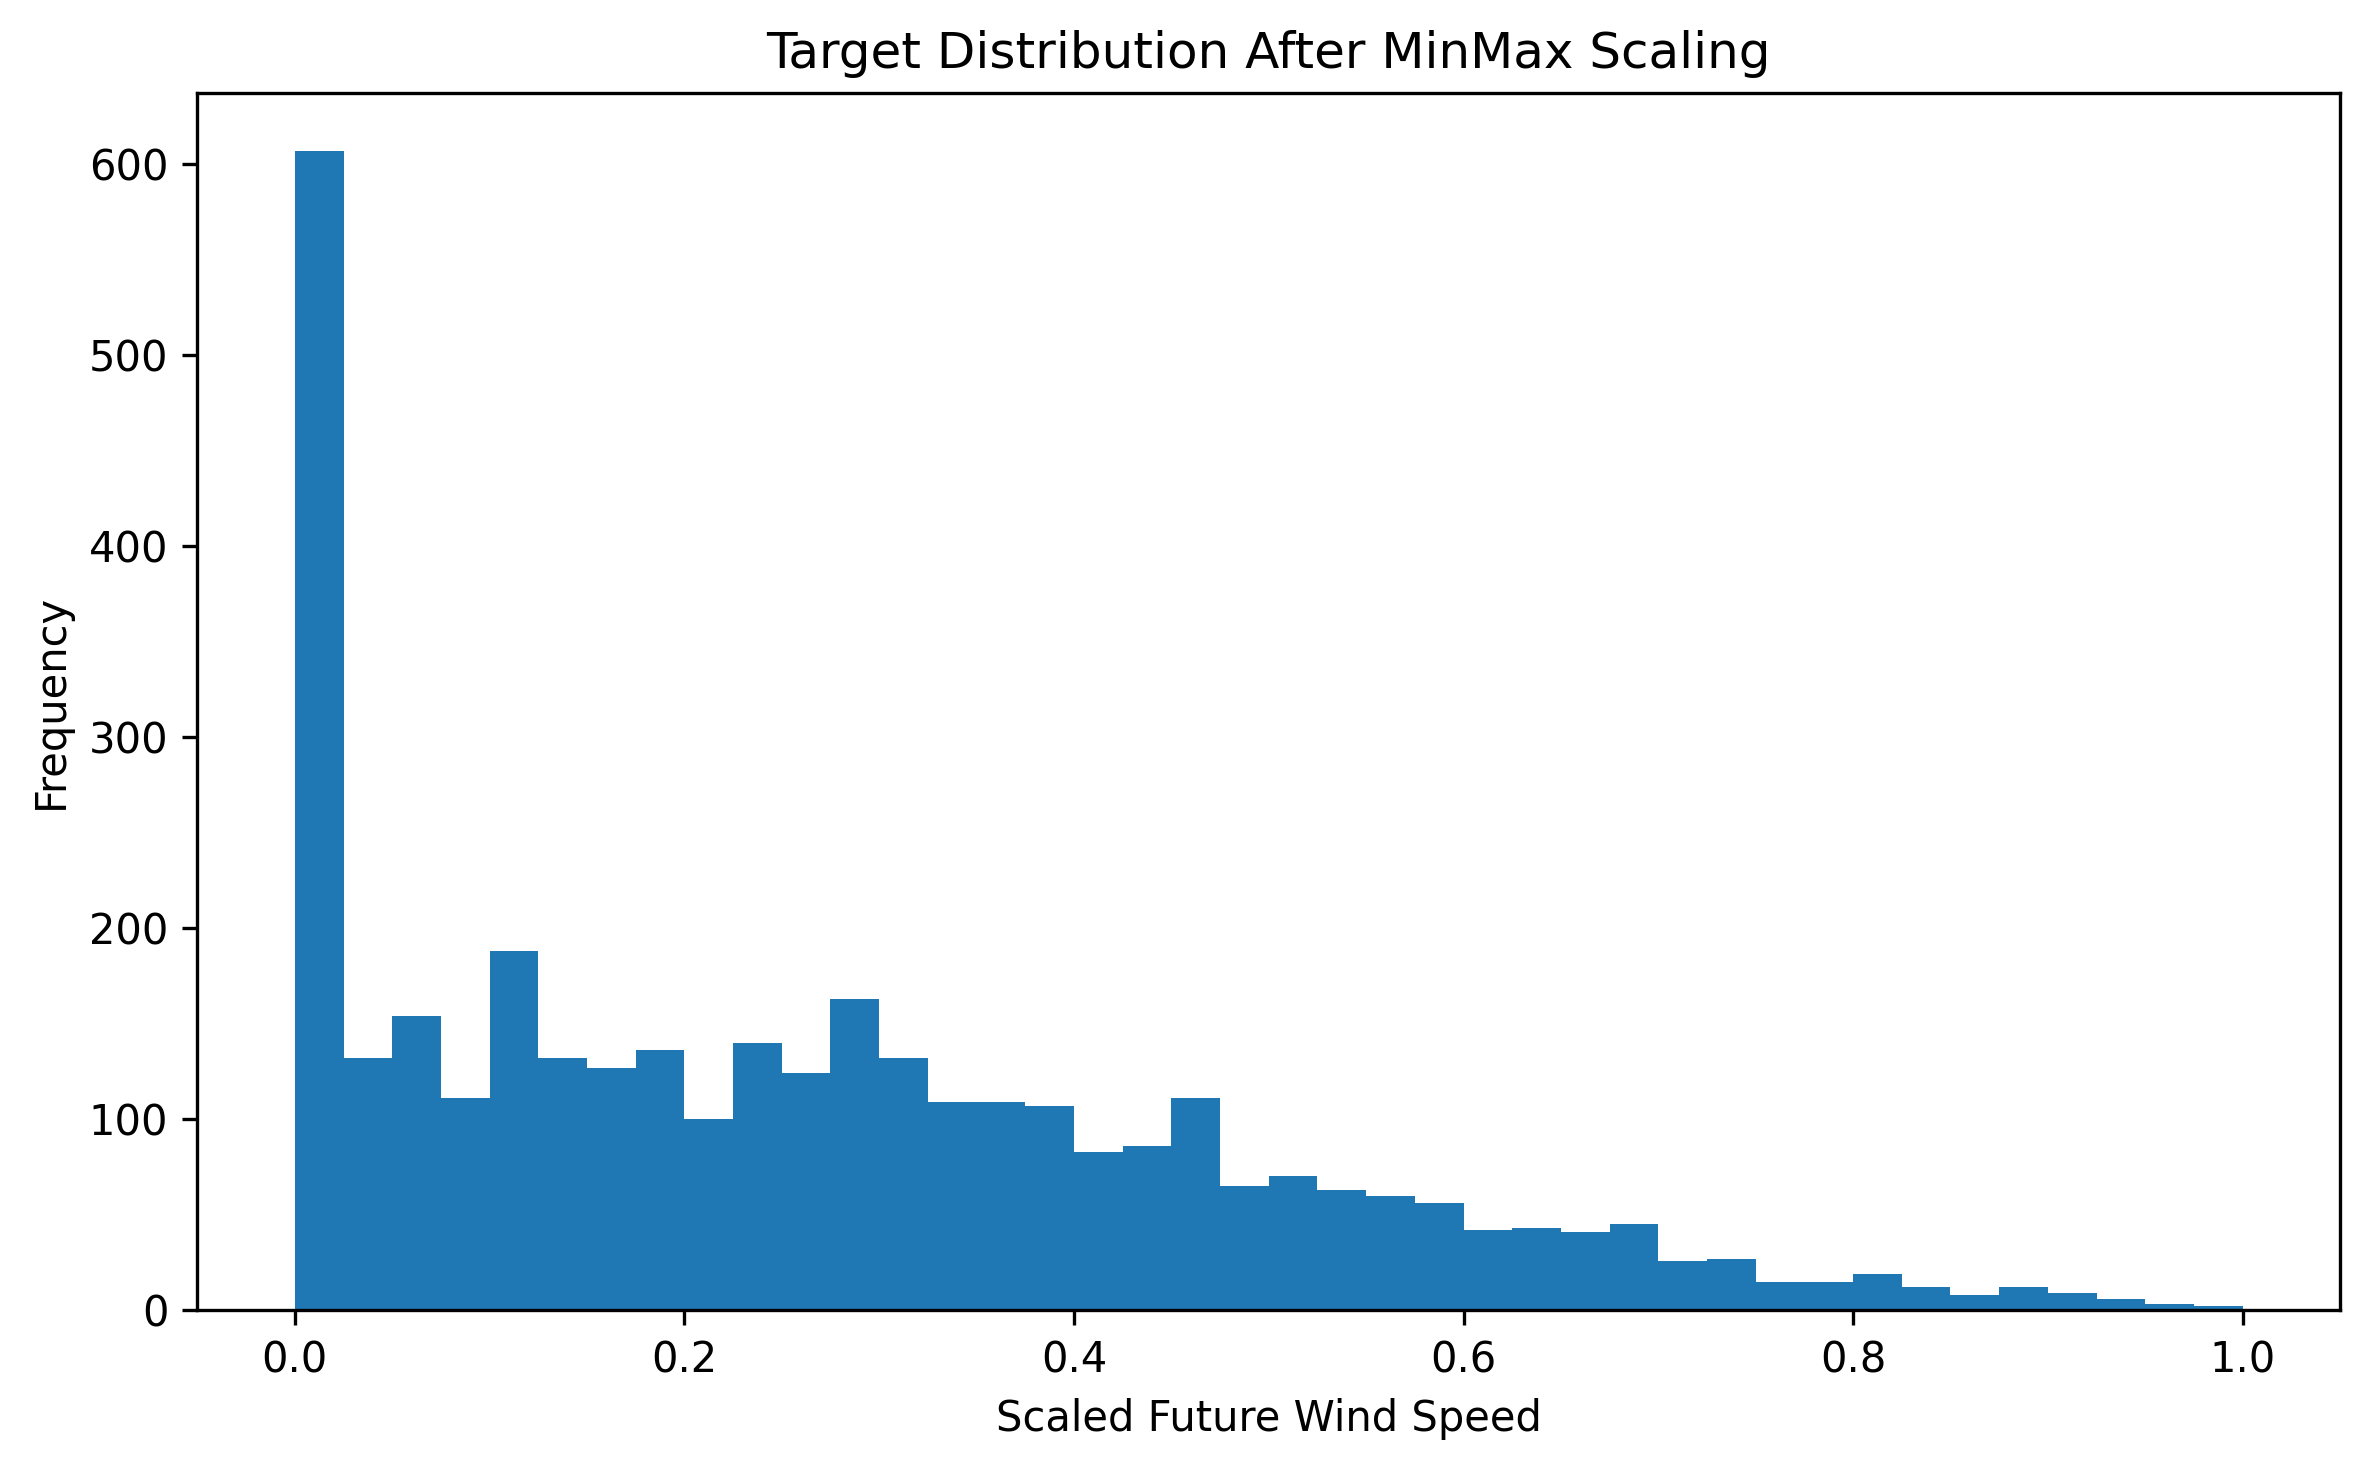


BiLSTM X_train shape: (3394, 96, 32)
BiLSTM X_test shape : (777, 96, 32)
Epoch 1/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 49s 712ms/step - loss: 0.0187 - val_loss: 0.0100 - learning_rate: 3.0000e-04
Epoch 2/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 36s 658ms/step - loss: 0.0083 - val_loss: 0.0075 - learning_rate: 3.0000e-04
Epoch 3/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 37s 686ms/step - loss: 0.0066 - val_loss: 0.0061 - learning_rate: 3.0000e-04
Epoch 4/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 37s 690ms/step - loss: 0.0058 - val_loss: 0.0048 - learning_rate: 3.0000e-04
Epoch 5/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 42s 715ms/step - loss: 0.0052 - val_loss: 0.0045 - learning_rate: 3.0000e-04
Epoch 6/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 38s 658ms/step - loss: 0.0045 - val_loss: 0.0045 - learning_rate: 3.0000e-04
Epoch 7/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 38s 699ms/step - loss: 0.0039 - val_loss: 0.0039 - learning_rate: 3.0000e-04
Epoch 8/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 37s 689ms/step - loss: 0.0038 - val_loss: 0.0040 - learning_rate: 3.0000e-0

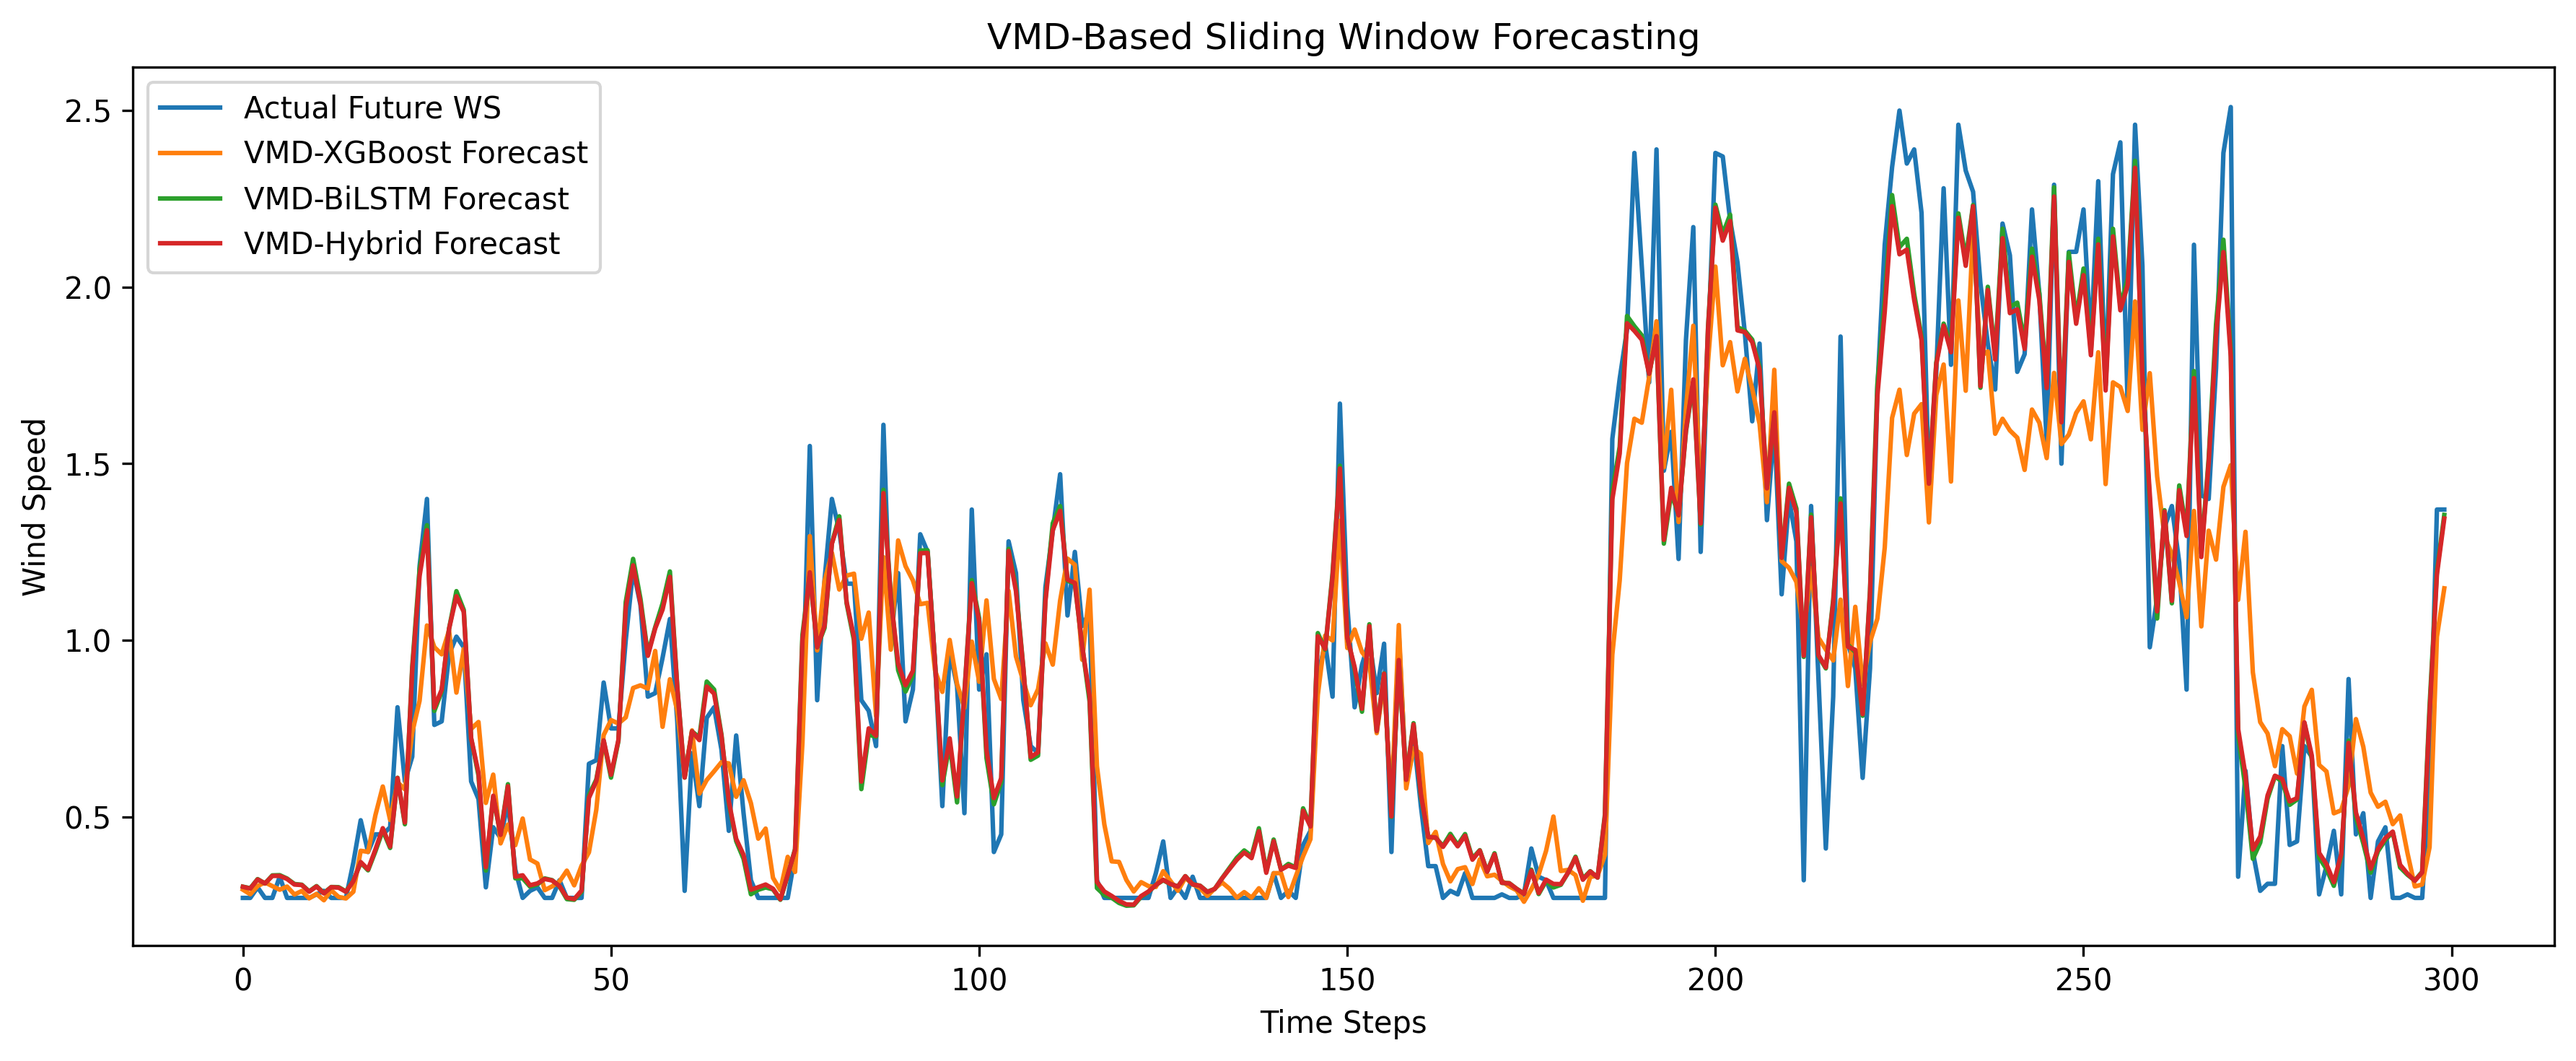

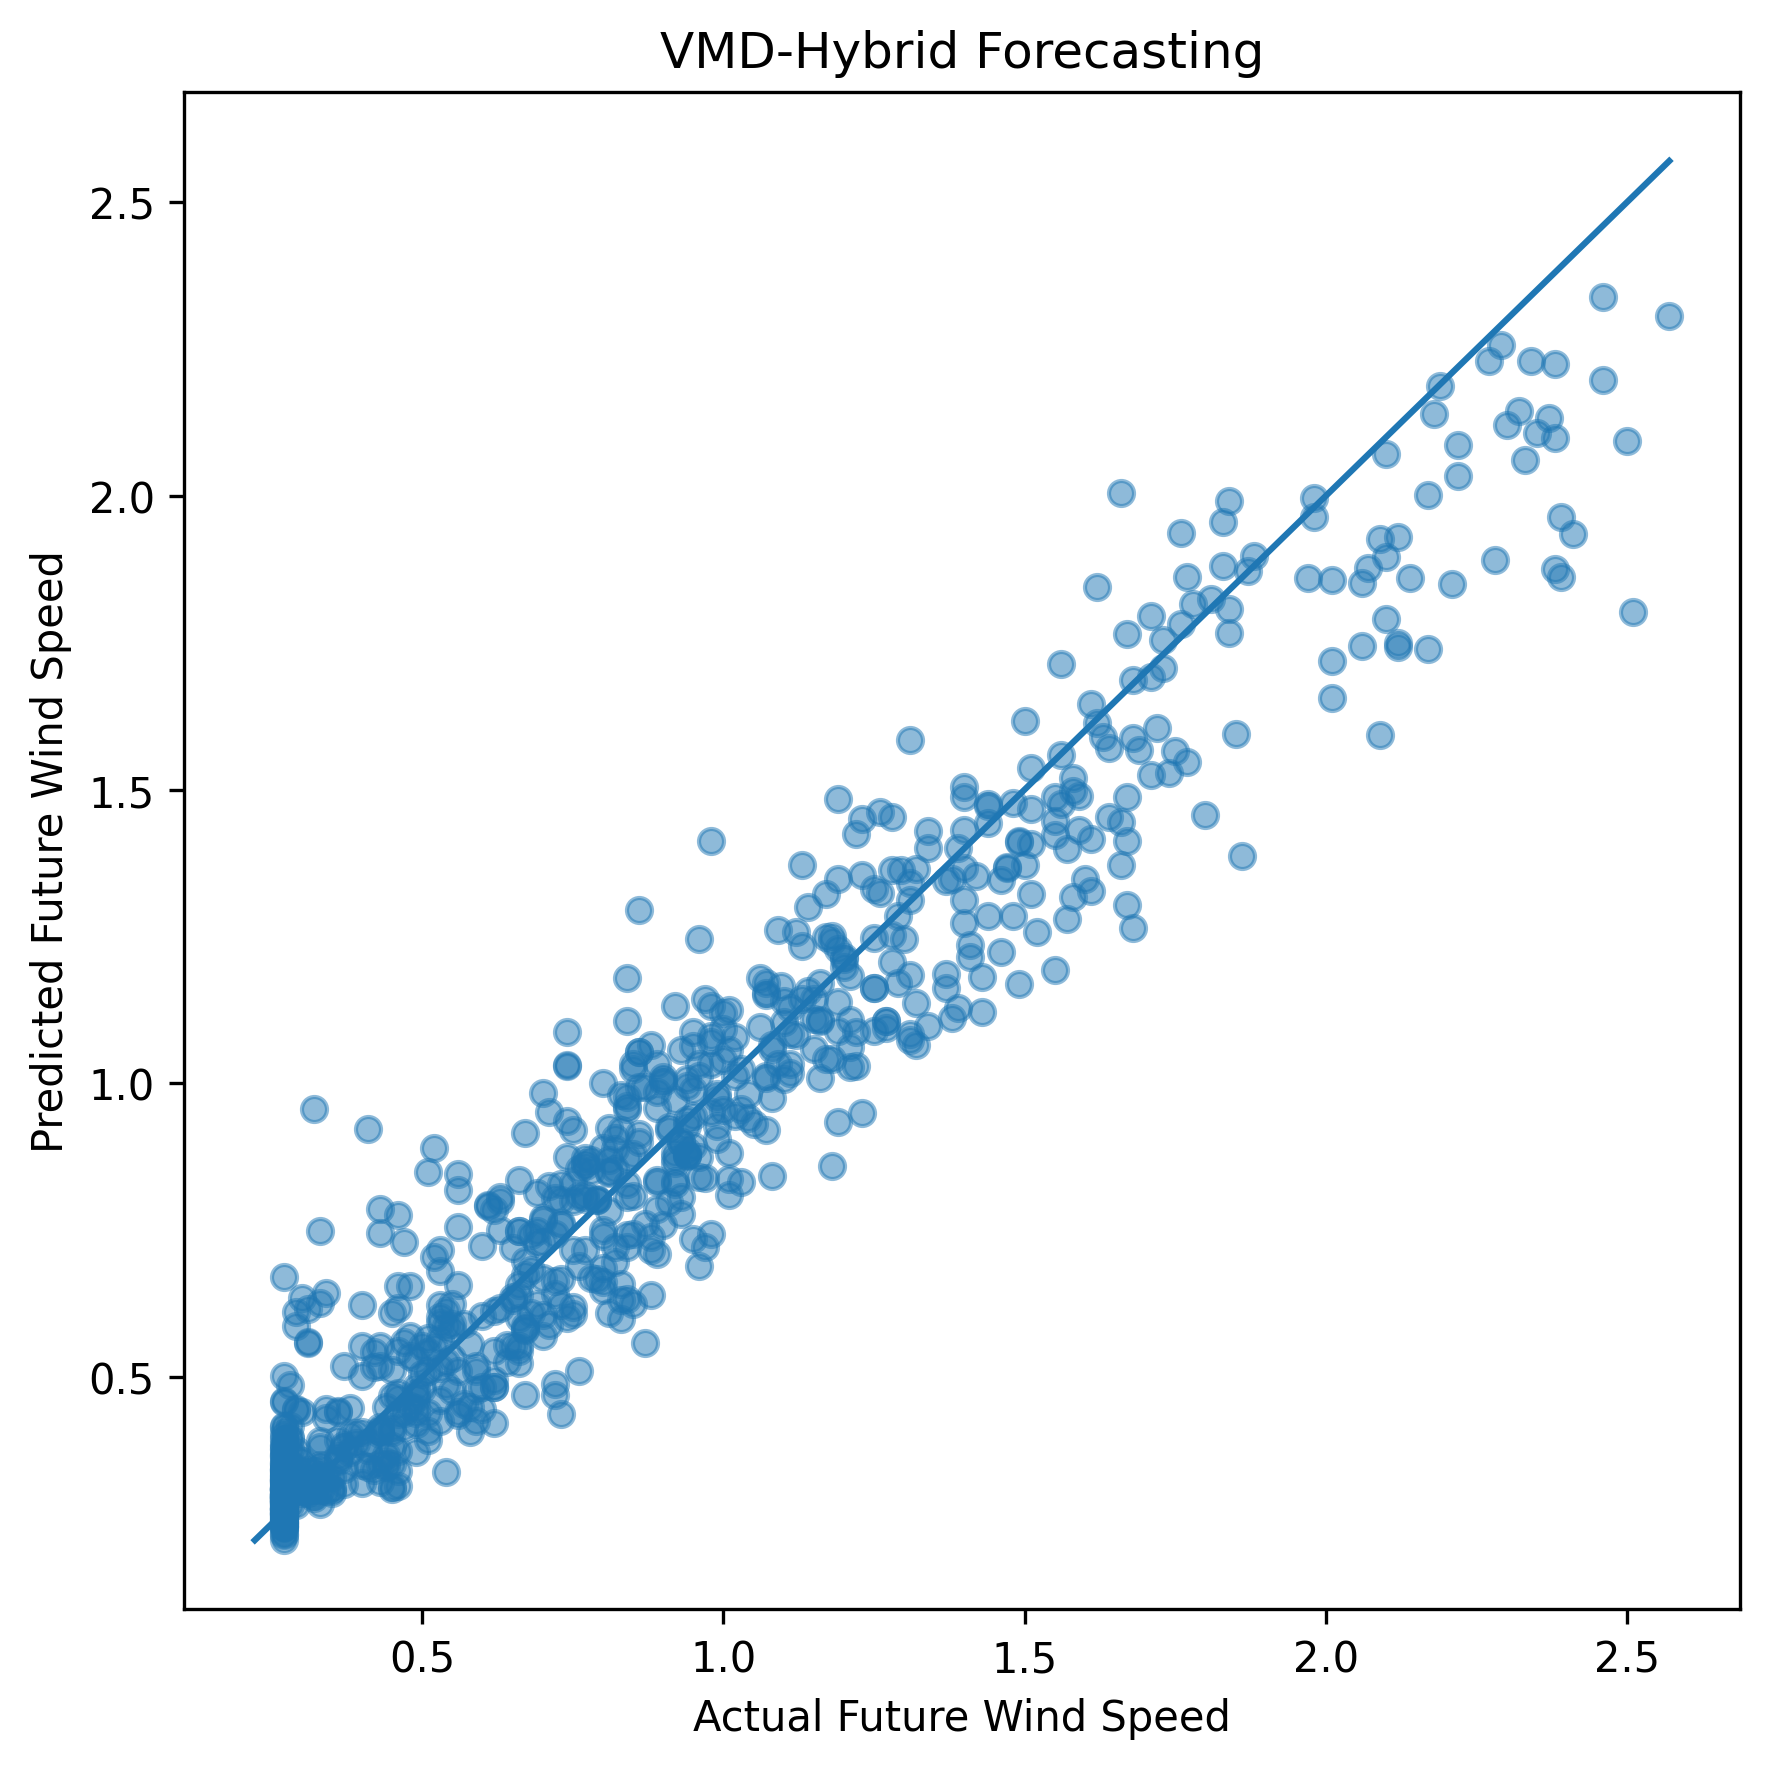

100%|===================| 499/500 [08:17<00:00]       

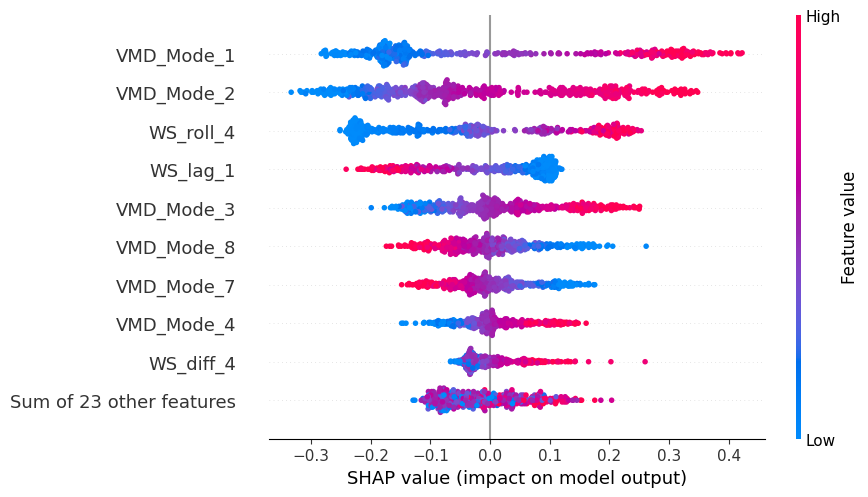

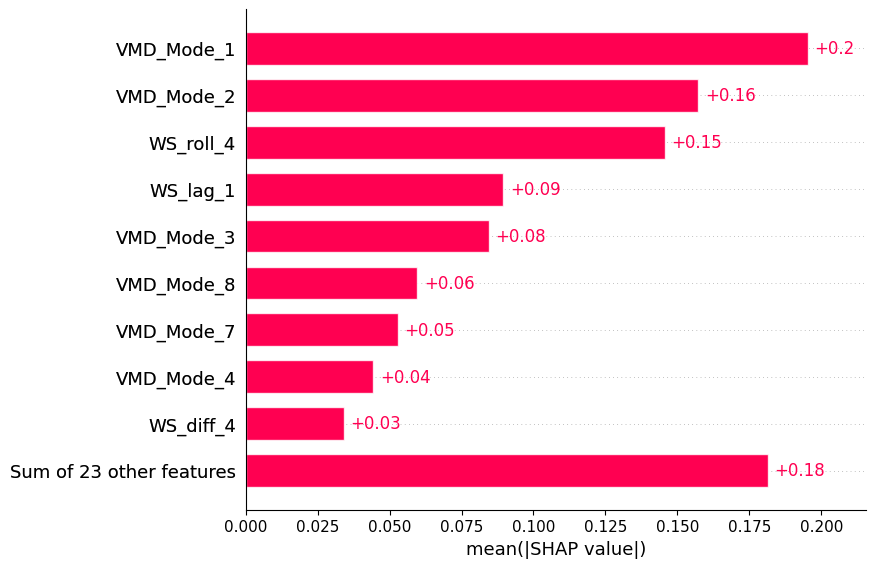

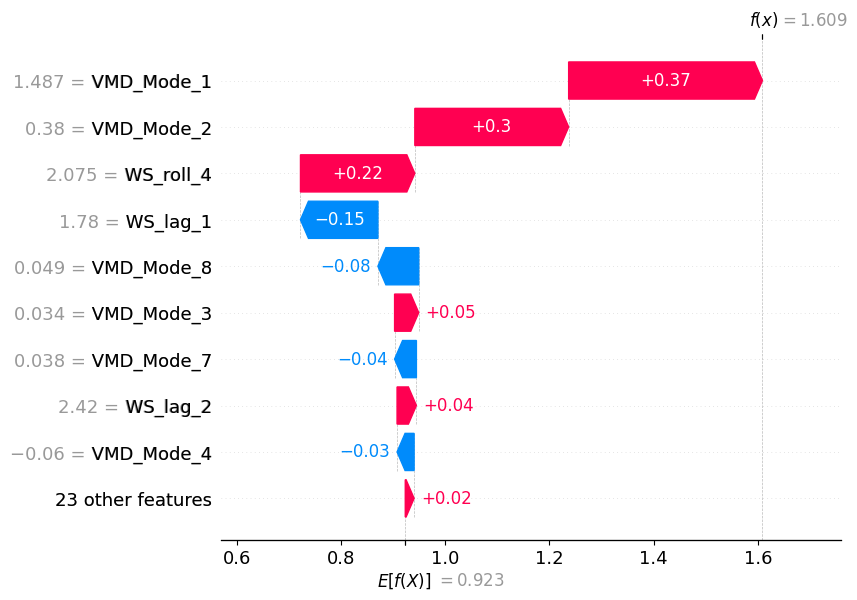

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =========================================================
# VMD–BiLSTM–XGBoost–SHAP Hybrid Forecasting Model
# With Normalization Techniques
# Leakage-Free Sliding Window Time-Series Forecasting
# Target: Future Wind Speed Prediction
# =========================================================

!pip install xgboost shap tensorflow vmdpy -q

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from vmdpy import VMD
from xgboost import XGBRegressor

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# =========================================================
# 1. LOAD DATA
# =========================================================

df = pd.read_csv("/content/royapuram_10Dec2025_to_10May2026_no_outliers.csv")

df = df.replace([np.inf, -np.inf], np.nan)

df["From_Date"] = pd.to_datetime(
    df["From_Date"],
    dayfirst=True,
    errors="coerce"
)

df = df.dropna(subset=["From_Date"])
df = df.sort_values("From_Date").reset_index(drop=True)

required_cols = ["WS", "PM2_5", "PM10", "RH", "SR", "WD_sin", "WD_cos"]
df = df.dropna(subset=required_cols).reset_index(drop=True)

print("Dataset shape after loading:", df.shape)

# =========================================================
# 2. CREATE FUTURE TARGET
# =========================================================

forecast_horizon = 1   # next 15 minutes

df["WS_future"] = df["WS"].shift(-forecast_horizon)

# =========================================================
# 3. VMD DECOMPOSITION
# =========================================================

alpha = 2000
tau = 0
K = 8
DC = 0
init = 1
tol = 1e-7

ws_signal = df["WS"].values.astype(float)
ws_signal = np.nan_to_num(ws_signal)

u, u_hat, omega = VMD(
    ws_signal,
    alpha,
    tau,
    K,
    DC,
    init,
    tol
)

print("Number of VMD modes generated:", u.shape[0])

vmd_features = []

for i in range(u.shape[0]):
    col_name = f"VMD_Mode_{i+1}"
    df[col_name] = u[i, :]
    vmd_features.append(col_name)

df["VMD_residual"] = df["WS"] - np.sum(u, axis=0)
vmd_features.append("VMD_residual")

print("VMD features created:")
print(vmd_features)

# =========================================================
# 4. FEATURE ENGINEERING
# =========================================================

# Lag features
for lag in [1, 2, 3, 4, 8, 12, 24, 48, 96, 192]:
    df[f"WS_lag_{lag}"] = df["WS"].shift(lag)

# Rolling mean features
for window in [4, 8, 12, 24, 48, 96]:
    df[f"WS_roll_{window}"] = df["WS"].rolling(window).mean()

# EMA features
for span in [12, 24, 48, 96]:
    df[f"WS_EMA_{span}"] = df["WS"].ewm(span=span, adjust=False).mean()

# Difference features
df["WS_diff_1"] = df["WS"] - df["WS_lag_1"]
df["WS_diff_4"] = df["WS"] - df["WS_lag_4"]
df["WS_diff_24"] = df["WS"] - df["WS_lag_24"]

# Time cyclic features
df["hour_sin"] = np.sin(2 * np.pi * df["From_Date"].dt.hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["From_Date"].dt.hour / 24)

df["day_sin"] = np.sin(2 * np.pi * df["From_Date"].dt.dayofyear / 365)
df["day_cos"] = np.cos(2 * np.pi * df["From_Date"].dt.dayofyear / 365)

df["month_sin"] = np.sin(2 * np.pi * df["From_Date"].dt.month / 12)
df["month_cos"] = np.cos(2 * np.pi * df["From_Date"].dt.month / 12)

# =========================================================
# 5. FEATURES AND TARGET
# =========================================================

base_features = [
    "PM2_5", "PM10", "RH", "SR",
    "WD_sin", "WD_cos",

    "WS_lag_1", "WS_lag_2", "WS_lag_3",
    "WS_lag_4", "WS_lag_8", "WS_lag_12",
    "WS_lag_24", "WS_lag_48", "WS_lag_96", "WS_lag_192",

    "WS_roll_4", "WS_roll_8", "WS_roll_12",
    "WS_roll_24", "WS_roll_48", "WS_roll_96",

    "WS_EMA_12", "WS_EMA_24", "WS_EMA_48", "WS_EMA_96",

    "WS_diff_1", "WS_diff_4", "WS_diff_24",

    "hour_sin", "hour_cos",
    "day_sin", "day_cos",
    "month_sin", "month_cos"
]

all_features = base_features + vmd_features

target = "WS_future"

df = df.dropna(subset=all_features + [target]).reset_index(drop=True)

# =========================================================
# 6. CORRELATION-BASED FEATURE SELECTION
# =========================================================

corr = df[all_features + [target]].corr()

print("\nCorrelation with Future Wind Speed:")
print(corr[target].sort_values(ascending=False))

selected_features = []

for col in all_features:
    if abs(corr.loc[col, target]) >= 0.10:
        selected_features.append(col)

print("\nSelected Features:")
print(selected_features)

X = df[selected_features]
y = df[target]

print("\nFinal dataset shape:", df.shape)
print("Forecast target:", target)
print("Forecast horizon:", forecast_horizon, "step ahead")
print("Selected feature count:", len(selected_features))

# =========================================================
# 7. TIME-BASED TRAIN TEST SPLIT
# =========================================================

split = int(len(df) * 0.8)

X_train_tab = X.iloc[:split]
X_test_tab = X.iloc[split:]

y_train_tab = y.iloc[:split]
y_test_tab = y.iloc[split:]

print("\nTrain size:", X_train_tab.shape)
print("Test size :", X_test_tab.shape)

# =========================================================
# 8. NORMALIZATION TECHNIQUE ANALYSIS
# =========================================================

print("\n================ Normalization Techniques ================")
print("Input features for BiLSTM: StandardScaler")
print("Target variable for BiLSTM: MinMaxScaler")
print("XGBoost: No normalization required")

# -----------------------------
# StandardScaler for X features
# -----------------------------

x_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train_tab)
X_test_scaled = x_scaler.transform(X_test_tab)

# -----------------------------
# MinMaxScaler for target y
# -----------------------------

y_scaler = MinMaxScaler()

y_train_scaled = y_scaler.fit_transform(
    y_train_tab.values.reshape(-1, 1)
)

y_test_scaled = y_scaler.transform(
    y_test_tab.values.reshape(-1, 1)
)

# Convert scaled arrays to DataFrame for checking
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=selected_features
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=selected_features
)

y_train_scaled_df = pd.DataFrame(
    y_train_scaled,
    columns=["WS_future_scaled"]
)

# Print scaling summary
print("\nBefore Scaling - Feature Summary:")
print(X_train_tab.describe().T[["mean", "std", "min", "max"]].head(10))

print("\nAfter StandardScaler - Feature Summary:")
print(X_train_scaled_df.describe().T[["mean", "std", "min", "max"]].head(10))

print("\nTarget Before MinMax Scaling:")
print(y_train_tab.describe())

print("\nTarget After MinMax Scaling:")
print(y_train_scaled_df.describe())

# Save normalization summary
normalization_summary = pd.DataFrame({
    "Data": ["Input Features", "Target Variable", "XGBoost Input"],
    "Technique": ["StandardScaler", "MinMaxScaler", "No Scaling"],
    "Purpose": [
        "Zero mean and unit variance for stable BiLSTM training",
        "Scale wind speed target into 0 to 1 range",
        "Tree-based model does not require scaling"
    ]
})

print("\nNormalization Summary:")
print(normalization_summary)

normalization_summary.to_csv(
    "normalization_summary.csv",
    index=False
)

# =========================================================
# 9. NORMALIZATION VISUALIZATION
# =========================================================

sample_cols = selected_features[:6]

plt.figure(figsize=(12, 6), dpi=300)
X_train_tab[sample_cols].boxplot()
plt.title("Feature Distribution Before Standardization")
plt.ylabel("Original Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("features_before_standardization.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 6), dpi=300)
X_train_scaled_df[sample_cols].boxplot()
plt.title("Feature Distribution After StandardScaler")
plt.ylabel("Standardized Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("features_after_standardization.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5), dpi=300)
plt.hist(y_train_tab, bins=40)
plt.title("Target Distribution Before MinMax Scaling")
plt.xlabel("Future Wind Speed")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("target_before_minmax_scaling.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5), dpi=300)
plt.hist(y_train_scaled, bins=40)
plt.title("Target Distribution After MinMax Scaling")
plt.xlabel("Scaled Future Wind Speed")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("target_after_minmax_scaling.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 10. XGBOOST MODEL
# =========================================================

xgb_model = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    max_depth=8,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=1,
    gamma=0,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train_tab, y_train_tab)

xgb_pred = xgb_model.predict(X_test_tab)

# =========================================================
# 11. LEAKAGE-FREE BiLSTM SLIDING WINDOW MODEL
# =========================================================

def create_sliding_window(X_data, y_data, window_size=96):
    X_window, y_window = [], []

    for i in range(window_size, len(X_data)):
        X_window.append(X_data[i-window_size:i])
        y_window.append(y_data[i])

    return np.array(X_window), np.array(y_window)

window_size = 96   # 96 × 15 min = 24 hours history

X_train_seq, y_train_seq = create_sliding_window(
    X_train_scaled,
    y_train_scaled,
    window_size
)

X_test_seq, y_test_seq = create_sliding_window(
    X_test_scaled,
    y_test_scaled,
    window_size
)

print("\nBiLSTM X_train shape:", X_train_seq.shape)
print("BiLSTM X_test shape :", X_test_seq.shape)

bilstm_model = Sequential()

bilstm_model.add(Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])))

bilstm_model.add(Bidirectional(LSTM(
    128,
    activation="tanh",
    return_sequences=True
)))
bilstm_model.add(Dropout(0.2))

bilstm_model.add(Bidirectional(LSTM(
    64,
    activation="tanh",
    return_sequences=True
)))
bilstm_model.add(Dropout(0.2))

bilstm_model.add(Bidirectional(LSTM(
    32,
    activation="tanh"
)))
bilstm_model.add(Dropout(0.2))

bilstm_model.add(Dense(64, activation="relu"))
bilstm_model.add(Dense(32, activation="relu"))
bilstm_model.add(Dense(1))

optimizer = Adam(learning_rate=0.0003)

bilstm_model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.Huber()
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=7,
    min_lr=0.00001
)

history = bilstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=200,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

bilstm_pred_scaled = bilstm_model.predict(X_test_seq)

# Convert prediction back to original scale
bilstm_pred = y_scaler.inverse_transform(
    bilstm_pred_scaled
).flatten()

# =========================================================
# 12. ALIGN PREDICTIONS
# =========================================================

xgb_pred_aligned = xgb_pred[window_size:]
y_test_aligned = y_test_tab.values[window_size:]

min_len = min(len(xgb_pred_aligned), len(bilstm_pred))

xgb_pred_aligned = xgb_pred_aligned[-min_len:]
bilstm_pred_aligned = bilstm_pred[-min_len:]
y_test_aligned = y_test_aligned[-min_len:]

# =========================================================
# 13. OPTIMIZED HYBRID WEIGHT
# =========================================================

best_r2 = -999
best_weight = None
best_hybrid_pred = None

for w in np.arange(0, 1.01, 0.05):

    hybrid_temp = (
        w * xgb_pred_aligned +
        (1 - w) * bilstm_pred_aligned
    )

    score = r2_score(y_test_aligned, hybrid_temp)

    if score > best_r2:
        best_r2 = score
        best_weight = w
        best_hybrid_pred = hybrid_temp

hybrid_pred = best_hybrid_pred

print("\nBest Hybrid Weight")
print("---------------------")
print("XGBoost weight:", best_weight)
print("BiLSTM weight :", round(1 - best_weight, 2))
print("Best Hybrid R²:", round(best_r2, 4))

# =========================================================
# 14. MODEL EVALUATION
# =========================================================

def evaluate_model(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    mape = np.mean(
        np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-8, y_true))
    ) * 100

    error_percentage = np.abs(
        (y_true - y_pred) / np.where(y_true == 0, 1e-8, y_true)
    ) * 100

    acc_10 = np.mean(error_percentage <= 10) * 100
    acc_20 = np.mean(error_percentage <= 20) * 100

    print(f"\n{model_name} Performance")
    print("--------------------------------")
    print("MAE  :", round(mae, 4))
    print("RMSE :", round(rmse, 4))
    print("R²   :", round(r2, 4))
    print("MAPE :", round(mape, 2), "%")
    print("Accuracy within ±10%:", round(acc_10, 2), "%")
    print("Accuracy within ±20%:", round(acc_20, 2), "%")

evaluate_model(y_test_aligned, xgb_pred_aligned, "VMD-XGBoost Forecasting")
evaluate_model(y_test_aligned, bilstm_pred_aligned, "VMD-BiLSTM Forecasting")
evaluate_model(y_test_aligned, hybrid_pred, "VMD-Hybrid Forecasting")

# =========================================================
# 15. ACTUAL VS PREDICTED PLOT
# =========================================================

plt.figure(figsize=(12, 5), dpi=300)
plt.plot(y_test_aligned[:300], label="Actual Future WS")
plt.plot(xgb_pred_aligned[:300], label="VMD-XGBoost Forecast")
plt.plot(bilstm_pred_aligned[:300], label="VMD-BiLSTM Forecast")
plt.plot(hybrid_pred[:300], label="VMD-Hybrid Forecast")
plt.xlabel("Time Steps")
plt.ylabel("Wind Speed")
plt.title("VMD-Based Sliding Window Forecasting")
plt.legend()
plt.tight_layout()
plt.savefig("actual_vs_predicted_vmd_hybrid.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 16. SCATTER PLOT
# =========================================================

plt.figure(figsize=(6, 6), dpi=300)
plt.scatter(y_test_aligned, hybrid_pred, alpha=0.5)

min_val = min(y_test_aligned.min(), hybrid_pred.min())
max_val = max(y_test_aligned.max(), hybrid_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Future Wind Speed")
plt.ylabel("Predicted Future Wind Speed")
plt.title("VMD-Hybrid Forecasting")
plt.tight_layout()
plt.savefig("scatter_actual_vs_predicted_vmd_hybrid.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 17. SHAP EXPLAINABILITY FOR XGBOOST
# =========================================================

explainer = shap.Explainer(xgb_model, X_train_tab)
shap_values = explainer(X_test_tab.iloc[:500])

shap.plots.beeswarm(shap_values)
shap.plots.bar(shap_values)
shap.plots.waterfall(shap_values[0])

# =========================================================
# 18. DOWNLOAD FILES IN COLAB
# =========================================================

try:
    from google.colab import files

    files.download("normalization_summary.csv")
    files.download("features_before_standardization.png")
    files.download("features_after_standardization.png")
    files.download("target_before_minmax_scaling.png")
    files.download("target_after_minmax_scaling.png")
    files.download("actual_vs_predicted_vmd_hybrid.png")
    files.download("scatter_actual_vs_predicted_vmd_hybrid.png")

except:
    pass

Initial dataset shape: (4556, 23)
Forecast horizon: 15 minutes ahead
Dataset after feature engineering: (4363, 49)

Training samples: 3490
Testing samples : 873
Training period: 2026-01-01 08:45:00 to 2026-10-01 07:15:00
Testing period: 2026-10-01 07:30:00 to 2026-12-04 23:15:00

Correlation with future wind speed:
WS_future     1.000000
WS_roll_4     0.804468
WS_roll_8     0.762144
WS_EMA_12     0.752849
WS_lag_1      0.745809
WS_lag_2      0.713433
WS_roll_12    0.708421
WS_lag_3      0.670175
WS_EMA_24     0.654205
WS_lag_4      0.639455
WS_roll_24    0.549375
WS_diff_24    0.523849
WS_EMA_48     0.511126
WS_lag_8      0.498371
WS_lag_12     0.364015
WS_EMA_96     0.349990
WS_roll_48    0.305005
SR            0.302386
WS_diff_4     0.177700
WS_roll_96    0.120348
WS_lag_24     0.083060
WD_sin        0.057370
WS_diff_1     0.054822
PM10          0.016998
WS_lag_192    0.016624
day_sin      -0.010990
month_sin    -0.037495
month_cos    -0.044663
day_cos      -0.054222
PM2_5        -0.

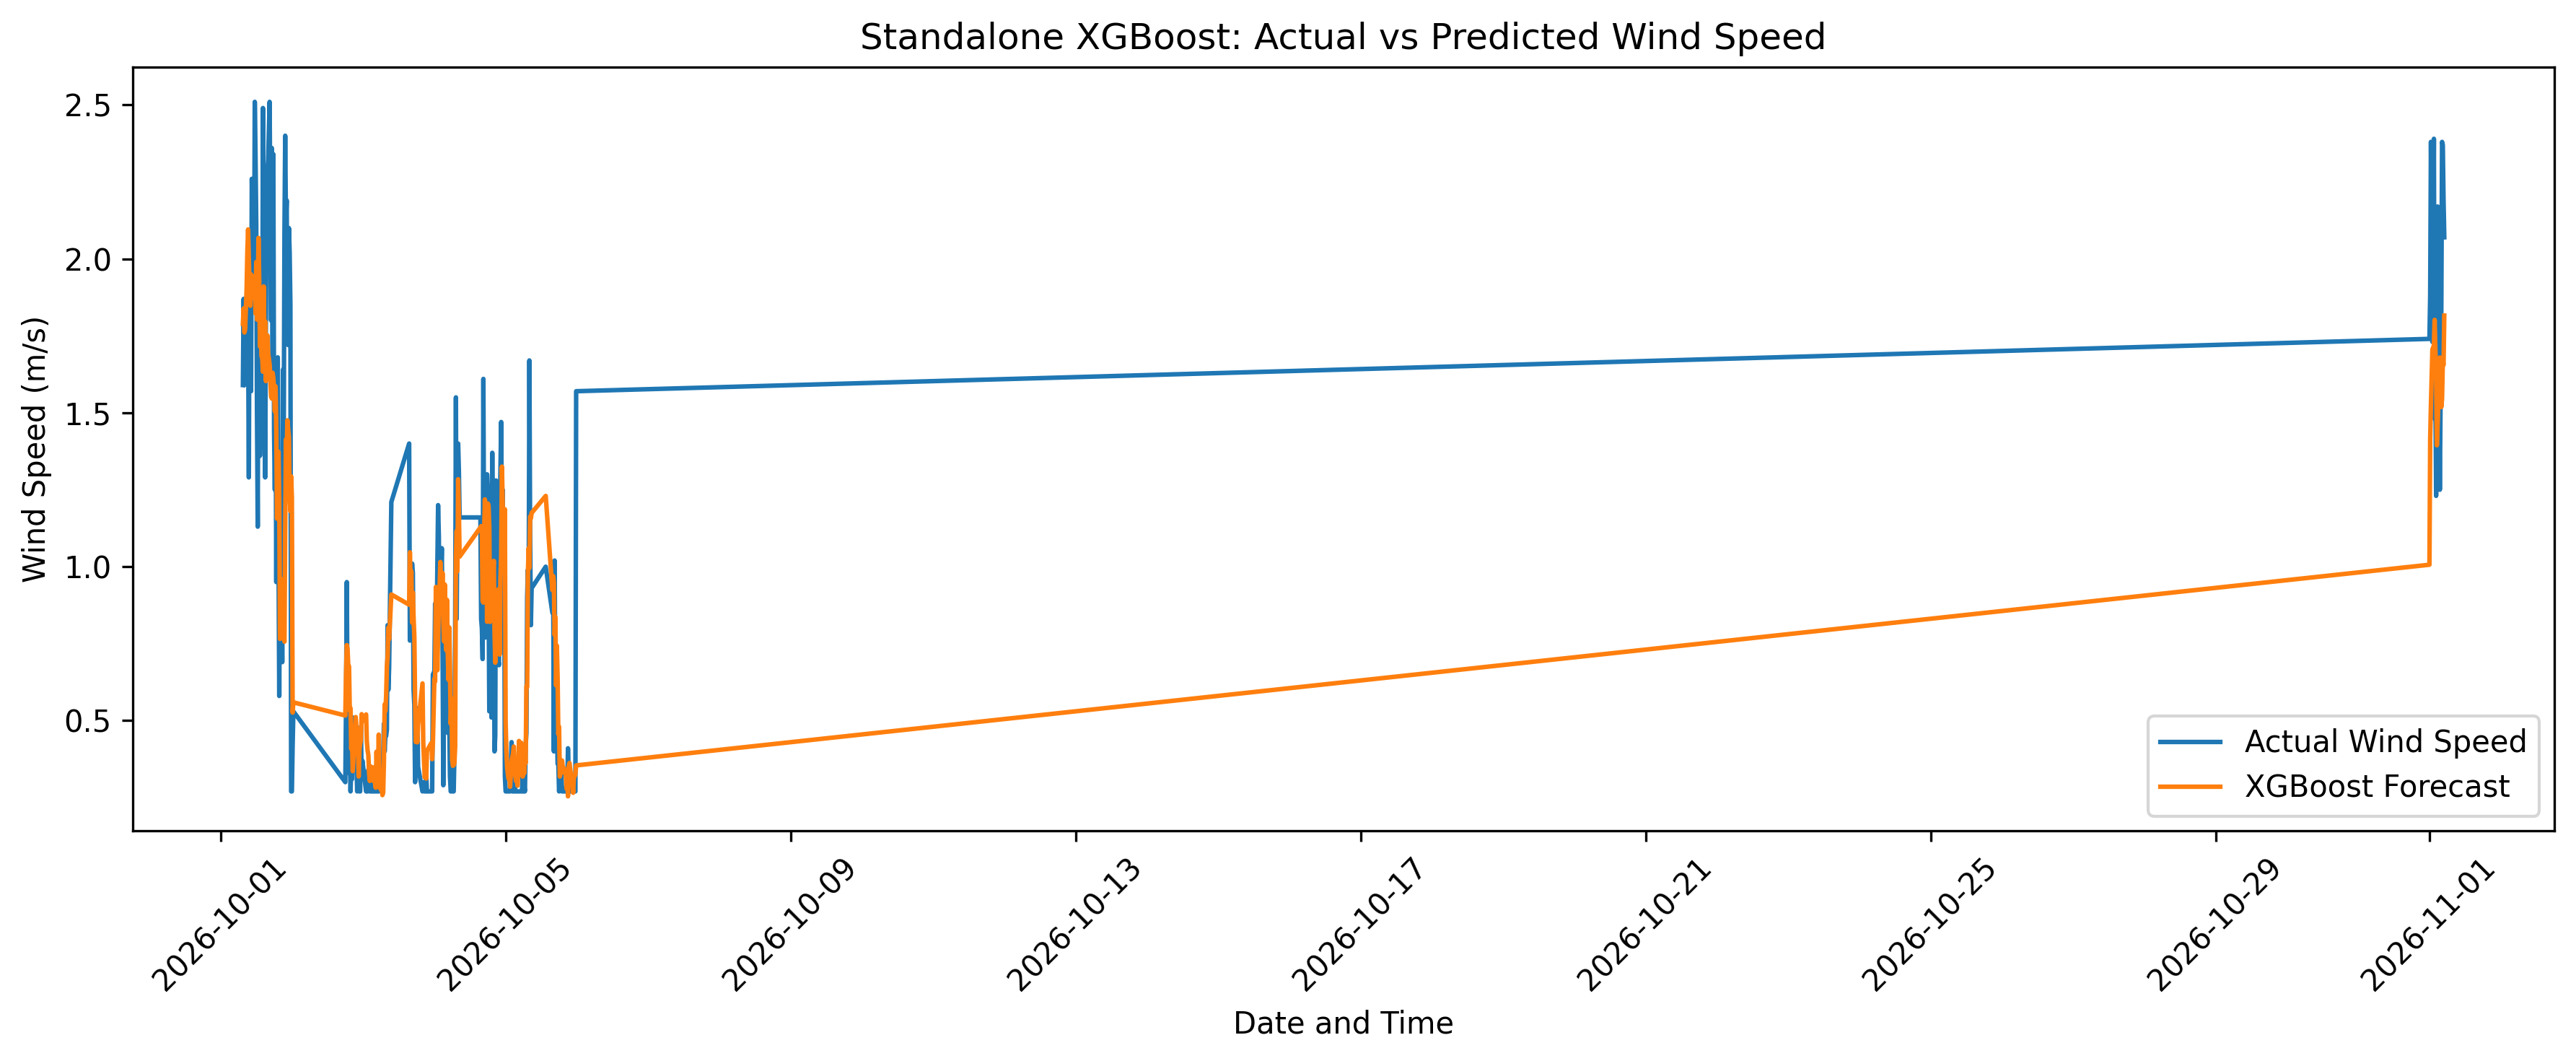

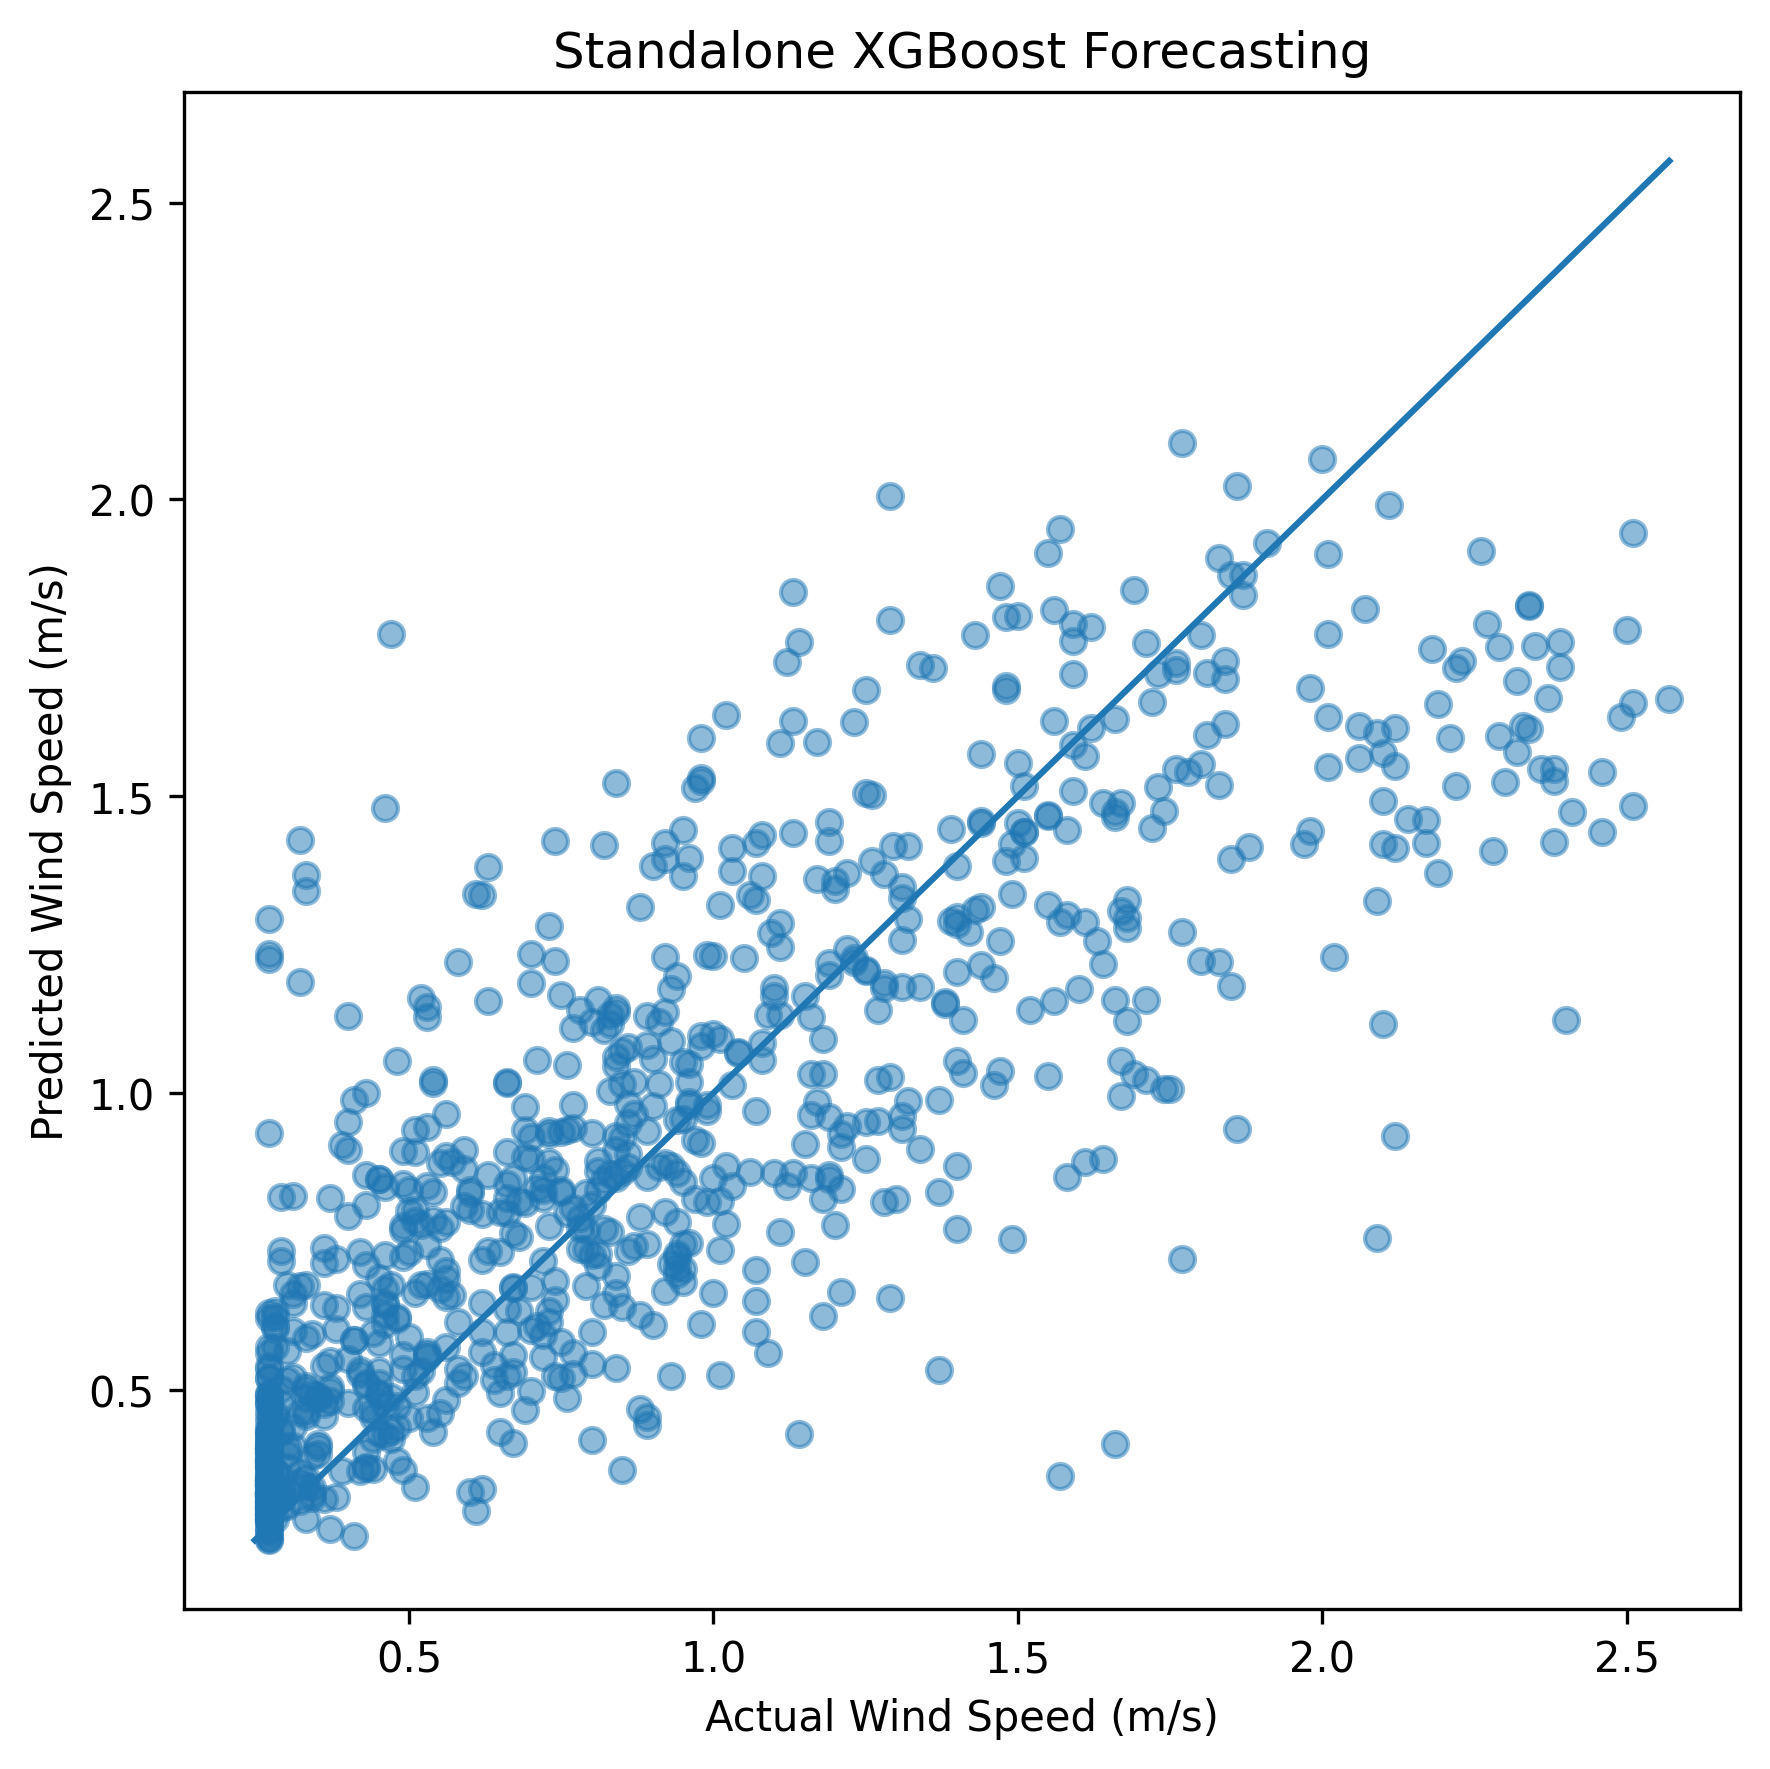

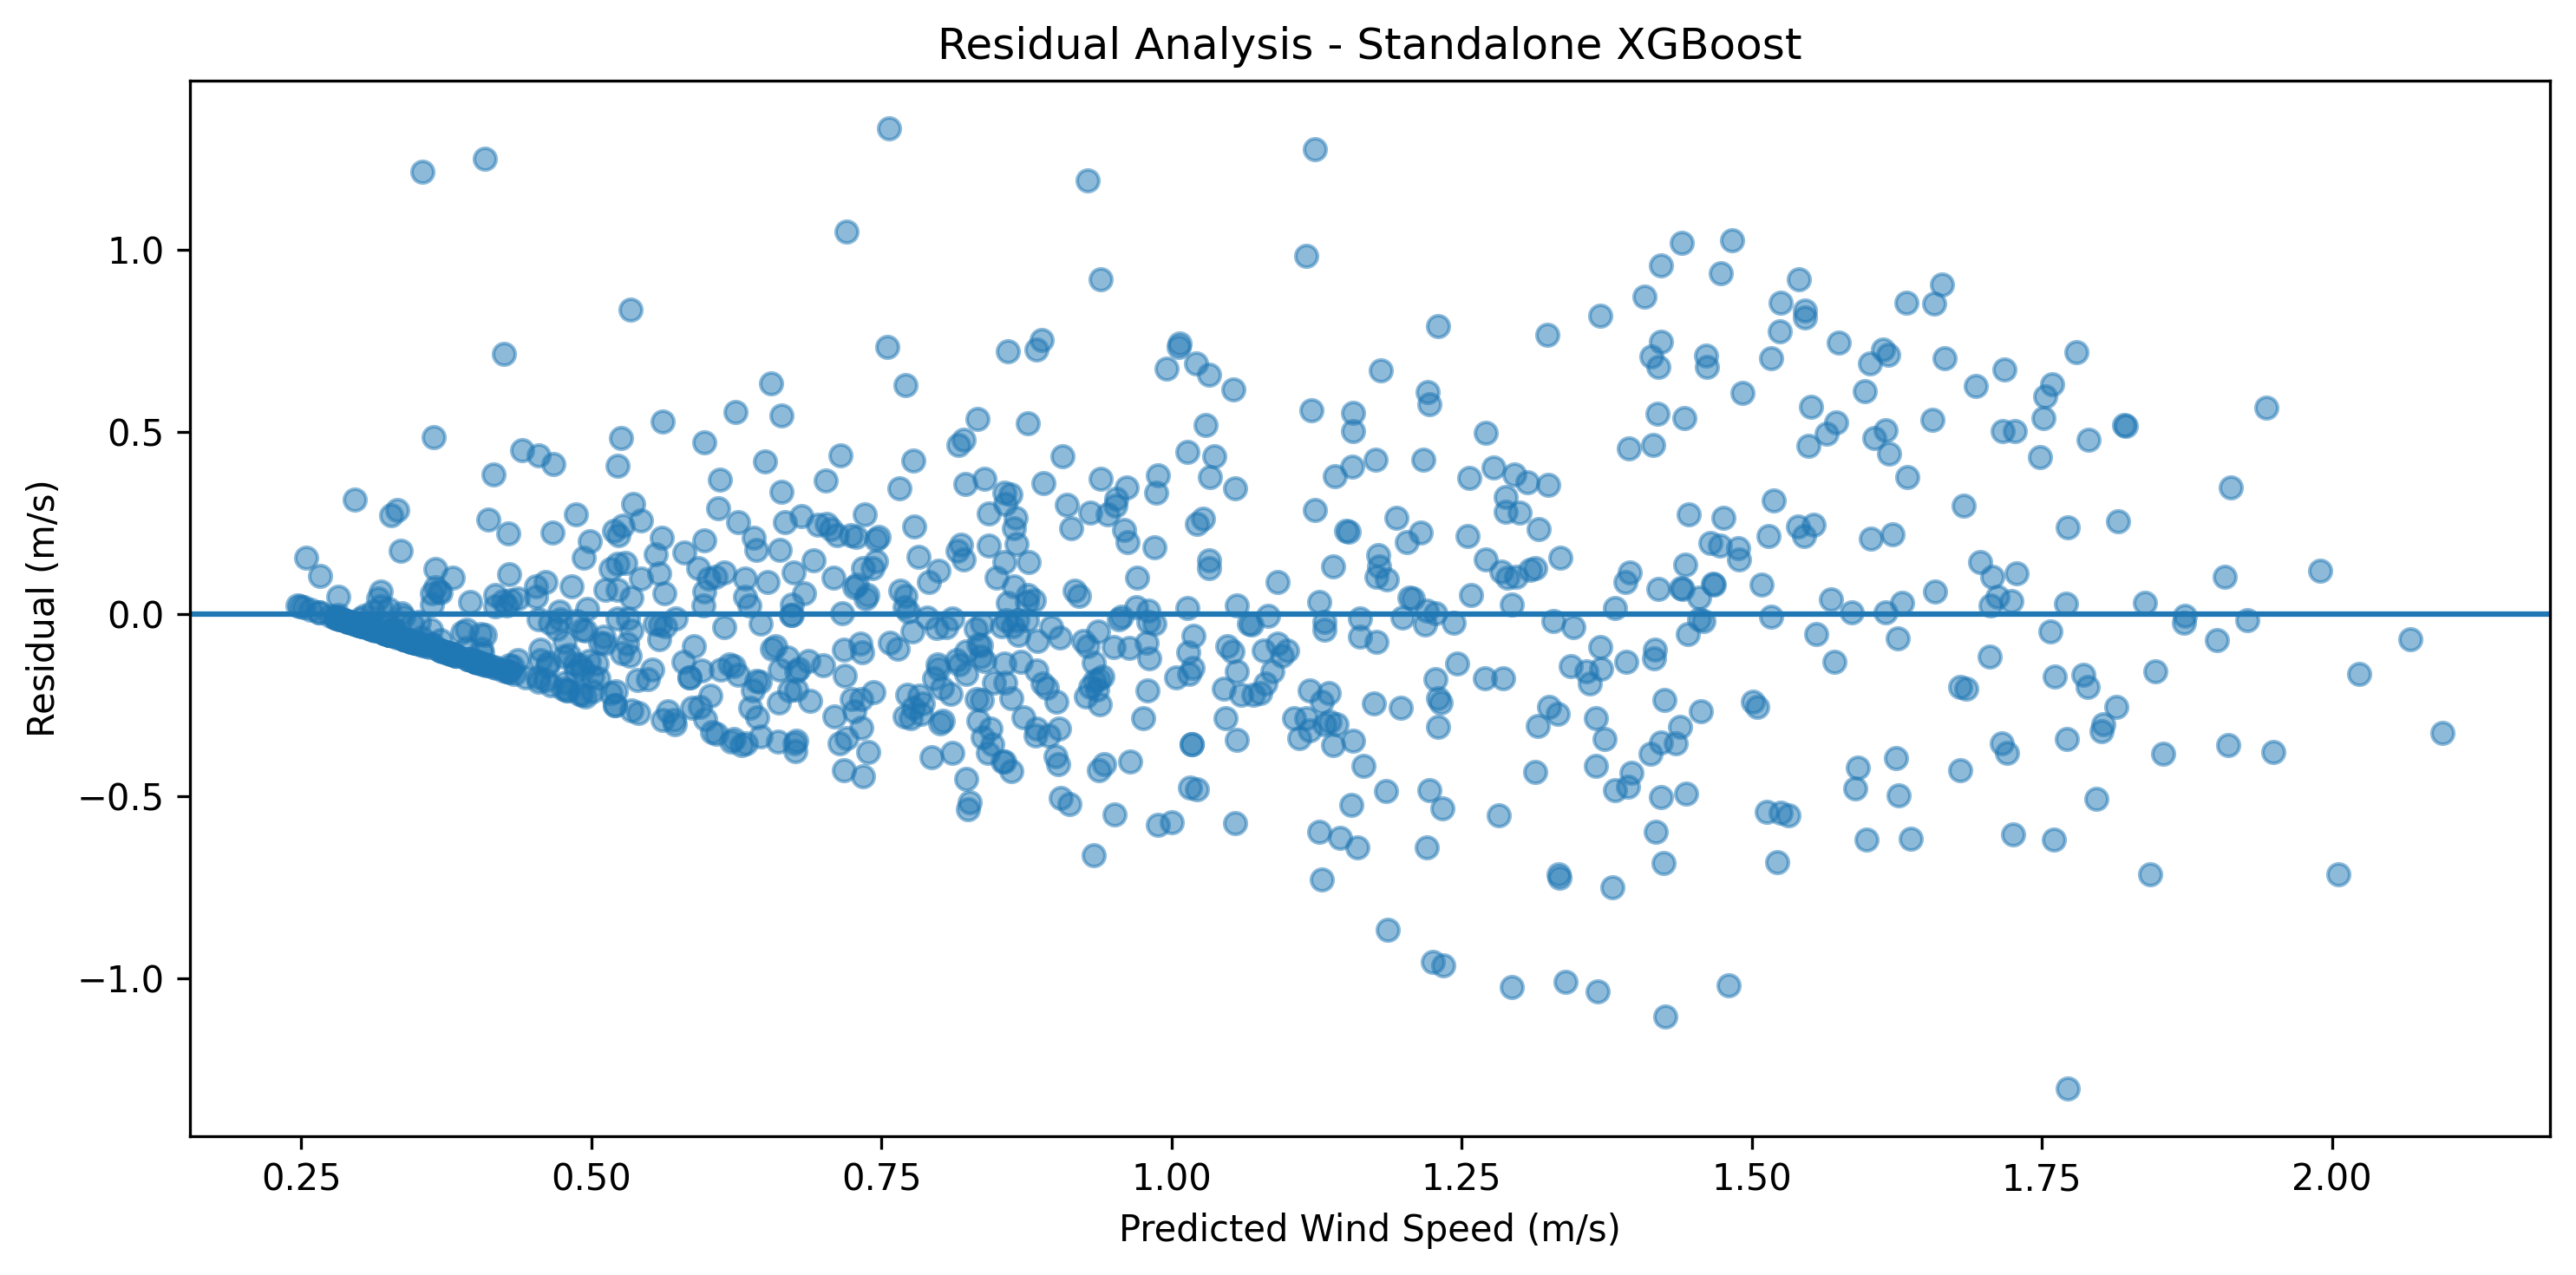


Top XGBoost features:
       Feature  Importance
0    WS_roll_4    0.586713
1    WS_roll_8    0.093510
2    WS_EMA_12    0.032310
3     hour_cos    0.028172
4    WS_diff_4    0.019568
5     WS_lag_1    0.019141
6    WS_EMA_24    0.016076
7   WS_diff_24    0.015744
8    WS_EMA_96    0.015161
9   WS_roll_96    0.014086
10  WS_roll_48    0.013900
11  WS_roll_12    0.013814
12    WS_lag_3    0.013611
13          SR    0.013519
14  WS_roll_24    0.013415
15    WS_lag_4    0.012870
16   WS_EMA_48    0.012085
17    WS_lag_2    0.011998
18   WS_lag_12    0.011855
19    WS_lag_8    0.011223


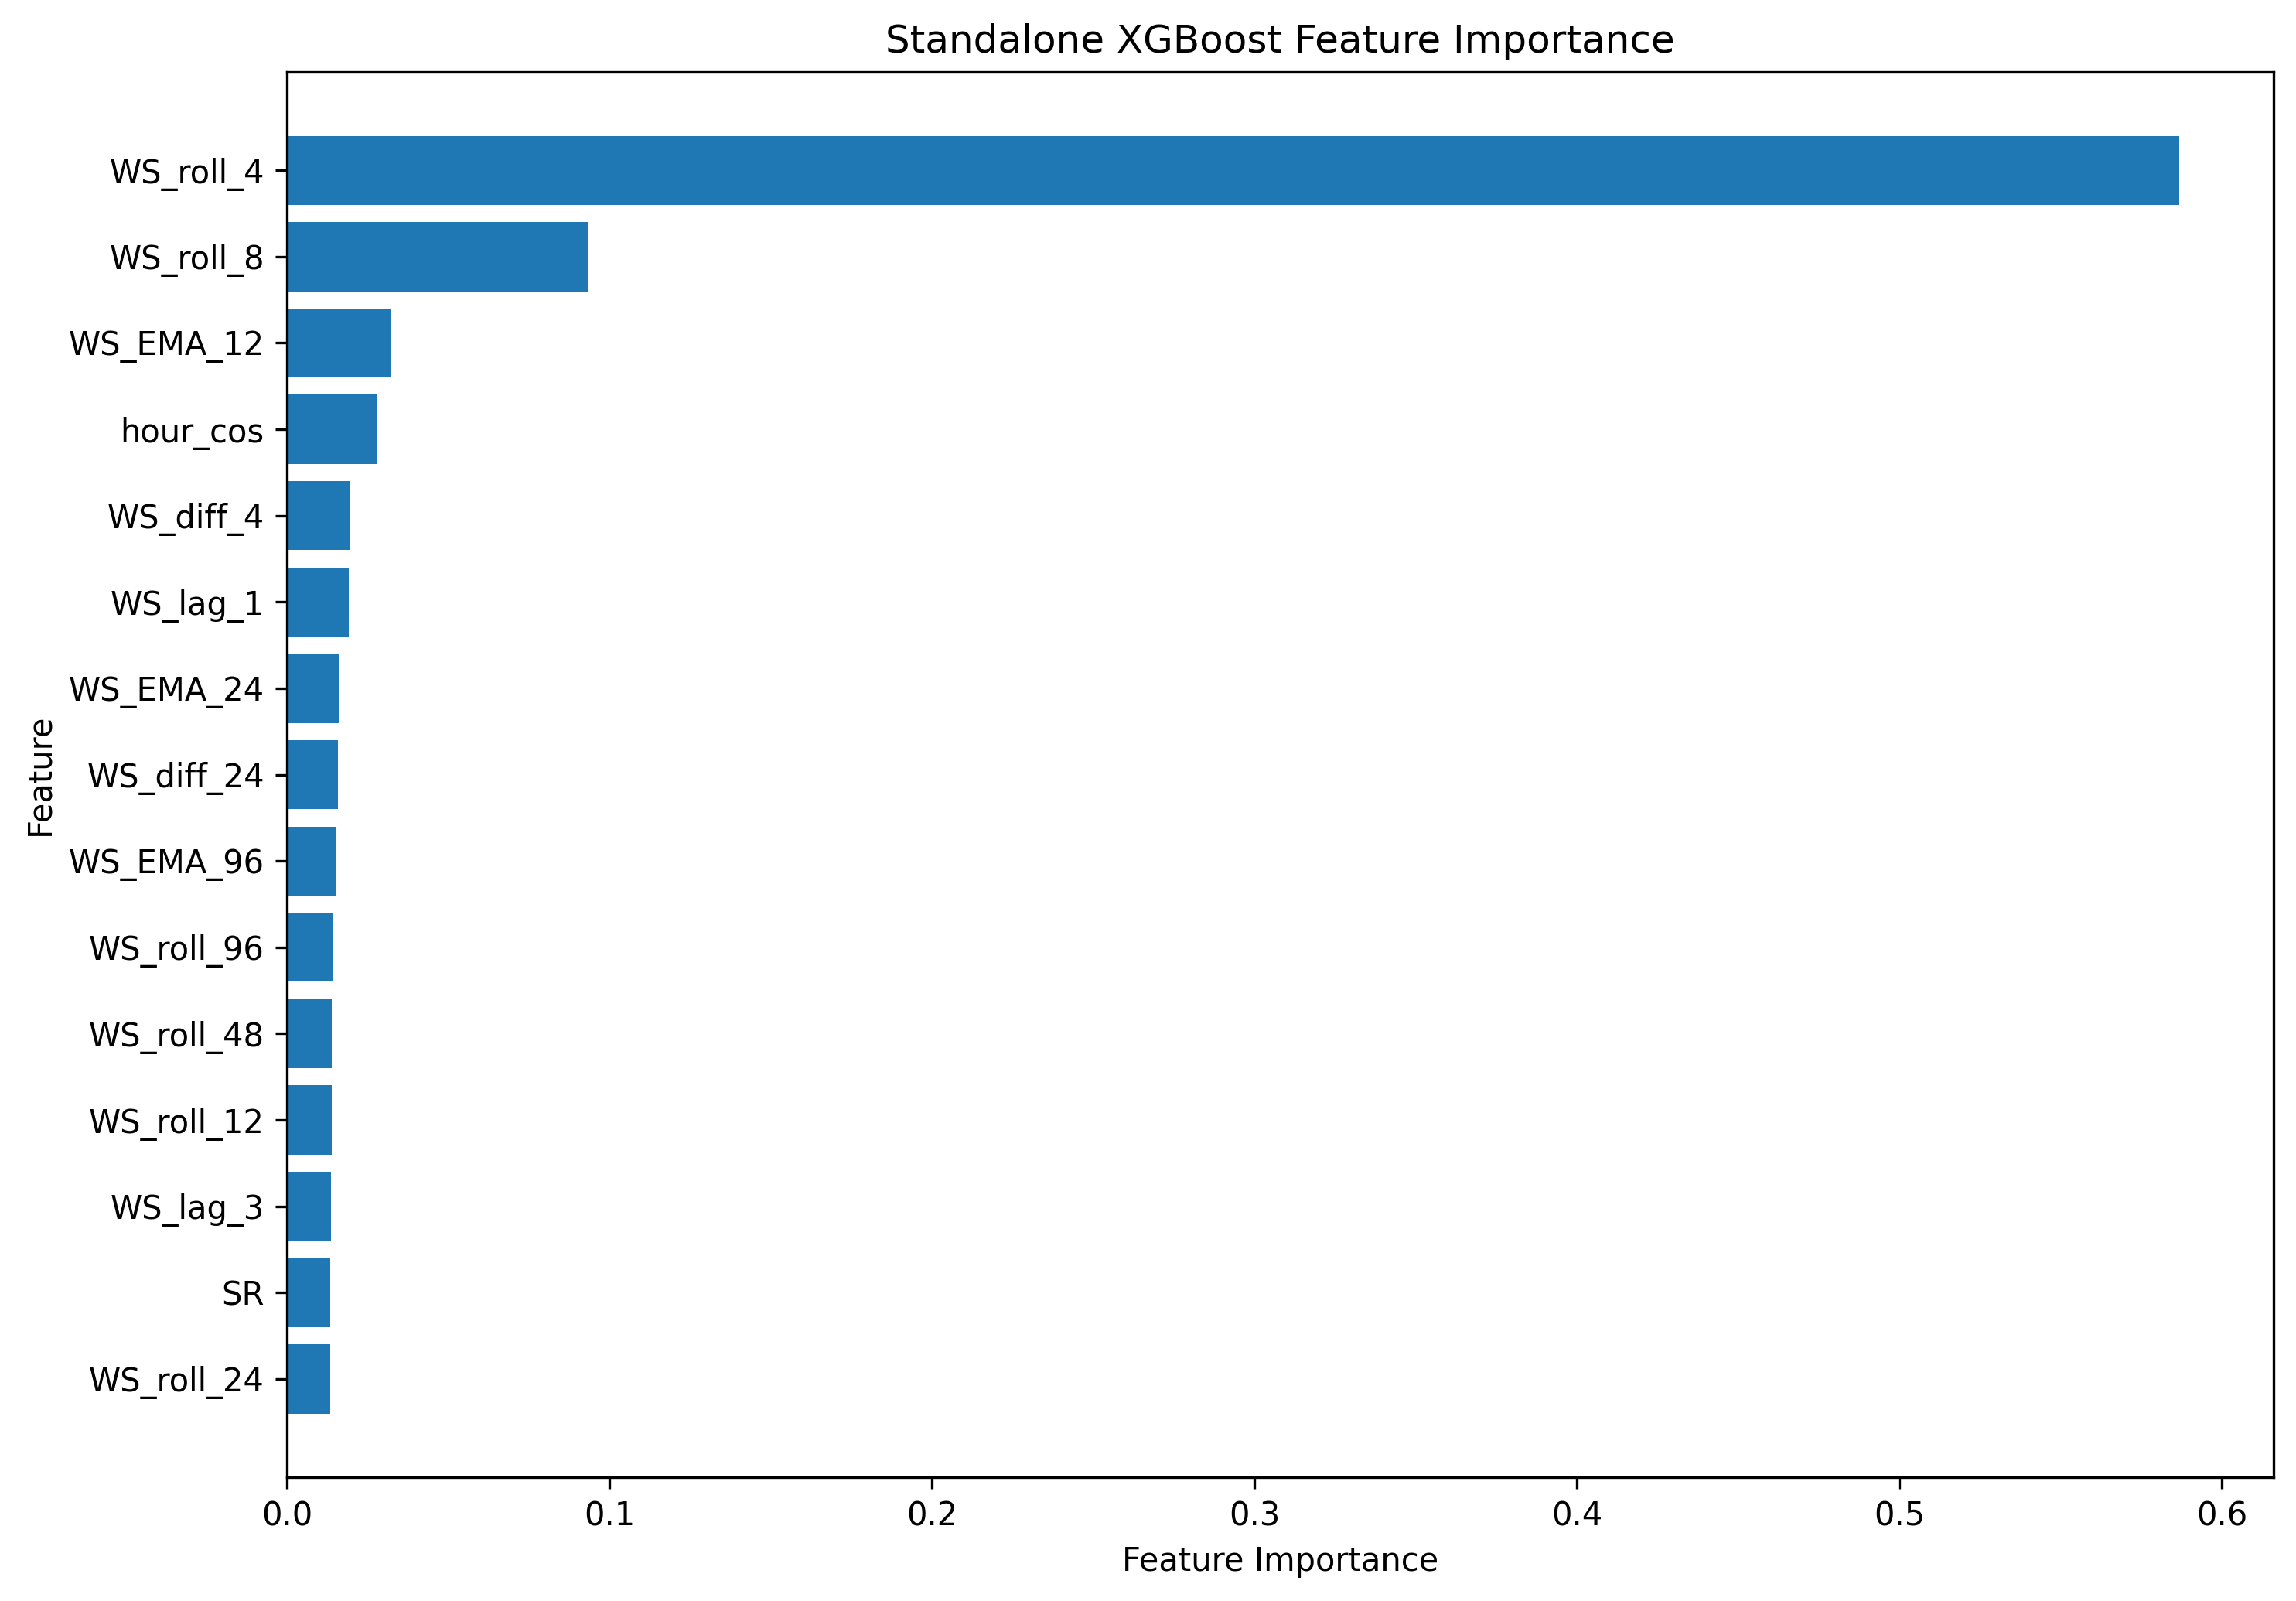

NotImplementedError: Categorical split is not yet supported. You can still use TreeExplainer with `feature_perturbation=tree_path_dependent`.

In [ ]:
# =========================================================
# STANDALONE XGBOOST MODEL
# 15-Minute-Ahead Wind Speed Forecasting
# No VMD
# No BiLSTM
# No Hybrid Weighted Averaging
# =========================================================

!pip install xgboost shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =========================================================
# 1. LOAD DATA
# =========================================================

df = pd.read_csv(
    "/content/royapuram_10Dec2025_to_10May2026_no_outliers.csv"
)

df = df.replace([np.inf, -np.inf], np.nan)

df["From_Date"] = pd.to_datetime(
    df["From_Date"],
    dayfirst=True,
    errors="coerce"
)

df = df.dropna(subset=["From_Date"])

df = df.sort_values(
    "From_Date"
).reset_index(drop=True)

required_cols = [
    "WS",
    "PM2_5",
    "PM10",
    "RH",
    "SR",
    "WD_sin",
    "WD_cos"
]

df = df.dropna(
    subset=required_cols
).reset_index(drop=True)

print("Initial dataset shape:", df.shape)

# =========================================================
# 2. CREATE 15-MIN-AHEAD TARGET
# =========================================================

forecast_horizon = 1

df["WS_future"] = df["WS"].shift(
    -forecast_horizon
)

print("Forecast horizon: 15 minutes ahead")

# =========================================================
# 3. FEATURE ENGINEERING
# =========================================================

# ---------------------------------------------------------
# 3.1 Lag features
# ---------------------------------------------------------

lag_values = [
    1, 2, 3, 4, 8,
    12, 24, 48, 96, 192
]

for lag in lag_values:

    df[f"WS_lag_{lag}"] = (
        df["WS"].shift(lag)
    )

# ---------------------------------------------------------
# 3.2 Rolling mean features
# ---------------------------------------------------------

rolling_windows = [
    4, 8, 12, 24, 48, 96
]

for window in rolling_windows:

    df[f"WS_roll_{window}"] = (
        df["WS"]
        .rolling(window=window)
        .mean()
    )

# ---------------------------------------------------------
# 3.3 EMA features
# ---------------------------------------------------------

ema_spans = [
    12, 24, 48, 96
]

for span in ema_spans:

    df[f"WS_EMA_{span}"] = (
        df["WS"]
        .ewm(
            span=span,
            adjust=False
        )
        .mean()
    )

# ---------------------------------------------------------
# 3.4 Difference features
# ---------------------------------------------------------

df["WS_diff_1"] = (
    df["WS"] - df["WS_lag_1"]
)

df["WS_diff_4"] = (
    df["WS"] - df["WS_lag_4"]
)

df["WS_diff_24"] = (
    df["WS"] - df["WS_lag_24"]
)

# ---------------------------------------------------------
# 3.5 Cyclic temporal features
# ---------------------------------------------------------

df["hour_sin"] = np.sin(
    2 * np.pi *
    df["From_Date"].dt.hour / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi *
    df["From_Date"].dt.hour / 24
)

df["day_sin"] = np.sin(
    2 * np.pi *
    df["From_Date"].dt.dayofyear / 365
)

df["day_cos"] = np.cos(
    2 * np.pi *
    df["From_Date"].dt.dayofyear / 365
)

df["month_sin"] = np.sin(
    2 * np.pi *
    df["From_Date"].dt.month / 12
)

df["month_cos"] = np.cos(
    2 * np.pi *
    df["From_Date"].dt.month / 12
)

# =========================================================
# 4. DEFINE FEATURES
# =========================================================

all_features = [

    # Meteorological variables
    "PM2_5",
    "PM10",
    "RH",
    "SR",
    "WD_sin",
    "WD_cos",

    # Lag features
    "WS_lag_1",
    "WS_lag_2",
    "WS_lag_3",
    "WS_lag_4",
    "WS_lag_8",
    "WS_lag_12",
    "WS_lag_24",
    "WS_lag_48",
    "WS_lag_96",
    "WS_lag_192",

    # Rolling features
    "WS_roll_4",
    "WS_roll_8",
    "WS_roll_12",
    "WS_roll_24",
    "WS_roll_48",
    "WS_roll_96",

    # EMA features
    "WS_EMA_12",
    "WS_EMA_24",
    "WS_EMA_48",
    "WS_EMA_96",

    # Difference features
    "WS_diff_1",
    "WS_diff_4",
    "WS_diff_24",

    # Temporal features
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "month_sin",
    "month_cos"
]

target = "WS_future"

df = df.dropna(
    subset=all_features + [target]
).reset_index(drop=True)

print(
    "Dataset after feature engineering:",
    df.shape
)

# =========================================================
# 5. CHRONOLOGICAL TRAIN / TEST SPLIT
# =========================================================

split = int(
    len(df) * 0.80
)

train_df = df.iloc[
    :split
].copy()

test_df = df.iloc[
    split:
].copy()

print("\nTraining samples:", len(train_df))
print("Testing samples :", len(test_df))

print(
    "Training period:",
    train_df["From_Date"].min(),
    "to",
    train_df["From_Date"].max()
)

print(
    "Testing period:",
    test_df["From_Date"].min(),
    "to",
    test_df["From_Date"].max()
)

# =========================================================
# 6. CORRELATION-BASED FEATURE SELECTION
#    TRAINING DATA ONLY
# =========================================================

train_corr = train_df[
    all_features + [target]
].corr(
    numeric_only=True
)

print(
    "\nCorrelation with future wind speed:"
)

print(
    train_corr[target]
    .sort_values(
        ascending=False
    )
)

selected_features = []

for col in all_features:

    correlation_value = (
        train_corr.loc[
            col,
            target
        ]
    )

    if abs(
        correlation_value
    ) >= 0.10:

        selected_features.append(
            col
        )

print(
    "\nSelected features:"
)

for feature in selected_features:

    print(feature)

print(
    "\nNumber of selected features:",
    len(selected_features)
)

# =========================================================
# 7. CREATE TRAIN AND TEST MATRICES
# =========================================================

X_train = train_df[
    selected_features
].copy()

y_train = train_df[
    target
].copy()

X_test = test_df[
    selected_features
].copy()

y_test = test_df[
    target
].copy()

test_dates = test_df[
    "From_Date"
].copy()

# =========================================================
# 8. XGBOOST MODEL
# =========================================================

xgb_model = XGBRegressor(

    n_estimators=3000,

    learning_rate=0.01,

    max_depth=8,

    subsample=0.85,

    colsample_bytree=0.85,

    min_child_weight=1,

    gamma=0,

    reg_alpha=0.1,

    reg_lambda=1.0,

    objective="reg:squarederror",

    random_state=42,

    n_jobs=-1
)

# =========================================================
# 9. TRAIN MODEL
# =========================================================

xgb_model.fit(
    X_train,
    y_train
)

print(
    "\nXGBoost training completed."
)

# =========================================================
# 10. TEST PREDICTION
# =========================================================

xgb_pred = xgb_model.predict(
    X_test
)

# =========================================================
# 11. MODEL EVALUATION
# =========================================================

mae = mean_absolute_error(
    y_test,
    xgb_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

r2 = r2_score(
    y_test,
    xgb_pred
)

denominator = np.where(
    np.abs(y_test.values) < 1e-8,
    1e-8,
    np.abs(y_test.values)
)

percentage_error = (
    np.abs(
        y_test.values -
        xgb_pred
    )
    /
    denominator
    *
    100
)

mape = np.mean(
    percentage_error
)

accuracy_10 = np.mean(
    percentage_error <= 10
) * 100

accuracy_20 = np.mean(
    percentage_error <= 20
) * 100

print(
    "\n=========================================="
)

print(
    "STANDALONE XGBOOST PERFORMANCE"
)

print(
    "=========================================="
)

print(
    "MAE  :", round(mae, 4)
)

print(
    "RMSE :", round(rmse, 4)
)

print(
    "R²   :", round(r2, 4)
)

print(
    "MAPE :", round(mape, 2), "%"
)

print(
    "Accuracy within ±10%:",
    round(accuracy_10, 2), "%"
)

print(
    "Accuracy within ±20%:",
    round(accuracy_20, 2), "%"
)

# =========================================================
# 12. SAVE PERFORMANCE METRICS
# =========================================================

performance_df = pd.DataFrame({

    "Model": [
        "Standalone XGBoost"
    ],

    "MAE": [
        mae
    ],

    "RMSE": [
        rmse
    ],

    "R2": [
        r2
    ],

    "MAPE": [
        mape
    ],

    "Accuracy_10_percent": [
        accuracy_10
    ],

    "Accuracy_20_percent": [
        accuracy_20
    ]

})

performance_df.to_csv(
    "standalone_xgboost_performance.csv",
    index=False
)

print(
    "\nPerformance summary:"
)

print(
    performance_df.round(4)
)

# =========================================================
# 13. SAVE TEST PREDICTIONS
# =========================================================

prediction_results = pd.DataFrame({

    "Date_Time":
        test_dates.values,

    "Actual_WS":
        y_test.values,

    "XGBoost_Predicted_WS":
        xgb_pred

})

prediction_results.to_csv(
    "standalone_xgboost_predictions.csv",
    index=False
)

# =========================================================
# 14. ACTUAL VS PREDICTED PLOT
# =========================================================

plot_samples = min(
    300,
    len(y_test)
)

plt.figure(
    figsize=(12, 5),
    dpi=300
)

plt.plot(
    test_dates.iloc[:plot_samples],
    y_test.iloc[:plot_samples],
    label="Actual Wind Speed"
)

plt.plot(
    test_dates.iloc[:plot_samples],
    xgb_pred[:plot_samples],
    label="XGBoost Forecast"
)

plt.xlabel(
    "Date and Time"
)

plt.ylabel(
    "Wind Speed (m/s)"
)

plt.title(
    "Standalone XGBoost: Actual vs Predicted Wind Speed"
)

plt.xticks(
    rotation=45
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "xgboost_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# 15. SCATTER PLOT
# =========================================================

plt.figure(
    figsize=(6, 6),
    dpi=300
)

plt.scatter(
    y_test,
    xgb_pred,
    alpha=0.5
)

min_val = min(
    y_test.min(),
    xgb_pred.min()
)

max_val = max(
    y_test.max(),
    xgb_pred.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val]
)

plt.xlabel(
    "Actual Wind Speed (m/s)"
)

plt.ylabel(
    "Predicted Wind Speed (m/s)"
)

plt.title(
    "Standalone XGBoost Forecasting"
)

plt.tight_layout()

plt.savefig(
    "xgboost_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# 16. RESIDUAL ANALYSIS
# =========================================================

residuals = (
    y_test.values -
    xgb_pred
)

plt.figure(
    figsize=(10, 5),
    dpi=300
)

plt.scatter(
    xgb_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0
)

plt.xlabel(
    "Predicted Wind Speed (m/s)"
)

plt.ylabel(
    "Residual (m/s)"
)

plt.title(
    "Residual Analysis - Standalone XGBoost"
)

plt.tight_layout()

plt.savefig(
    "xgboost_residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# 17. FEATURE IMPORTANCE
# =========================================================

feature_importance = pd.DataFrame({

    "Feature":
        selected_features,

    "Importance":
        xgb_model.feature_importances_

})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

print(
    "\nTop XGBoost features:"
)

print(
    feature_importance.head(20)
)

feature_importance.to_csv(
    "xgboost_feature_importance.csv",
    index=False
)

# =========================================================
# 18. FEATURE IMPORTANCE PLOT
# =========================================================

top_n = min(
    15,
    len(feature_importance)
)

plt.figure(
    figsize=(10, 7),
    dpi=300
)

plt.barh(

    feature_importance[
        "Feature"
    ].head(top_n)[::-1],

    feature_importance[
        "Importance"
    ].head(top_n)[::-1]

)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Standalone XGBoost Feature Importance"
)

plt.tight_layout()

plt.savefig(
    "xgboost_feature_importance_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# 19. SHAP ANALYSIS
# =========================================================

shap_sample_size = min(
    500,
    len(X_test)
)

X_shap = X_test.iloc[
    :shap_sample_size
]

explainer = shap.Explainer(
    xgb_model,
    X_train
)

shap_values = explainer(
    X_shap
)

# Beeswarm
shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    "xgboost_shap_beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# SHAP bar plot
shap.plots.bar(
    shap_values,
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    "xgboost_shap_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# SHAP waterfall plot
shap.plots.waterfall(
    shap_values[0],
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    "xgboost_shap_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# 20. SAVE MEAN ABSOLUTE SHAP VALUES
# =========================================================

mean_abs_shap = (
    np.abs(
        shap_values.values
    )
    .mean(axis=0)
)

shap_importance_df = pd.DataFrame({

    "Feature":
        selected_features,

    "Mean_Absolute_SHAP":
        mean_abs_shap

})

shap_importance_df = (
    shap_importance_df
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

shap_importance_df.to_csv(
    "xgboost_mean_absolute_shap.csv",
    index=False
)

print(
    "\nMean absolute SHAP importance:"
)

print(
    shap_importance_df.head(20)
)

# =========================================================
# 21. DOWNLOAD OUTPUTS
# =========================================================

try:

    from google.colab import files

    output_files = [

        "standalone_xgboost_performance.csv",

        "standalone_xgboost_predictions.csv",

        "xgboost_actual_vs_predicted.png",

        "xgboost_scatter.png",

        "xgboost_residual_plot.png",

        "xgboost_feature_importance.csv",

        "xgboost_feature_importance_plot.png",

        "xgboost_shap_beeswarm.png",

        "xgboost_shap_bar.png",

        "xgboost_shap_waterfall.png",

        "xgboost_mean_absolute_shap.csv"

    ]

    for file_name in output_files:

        try:

            files.download(
                file_name
            )

        except:

            pass

except:

    print(
        "Automatic download available only in Google Colab."
    )

Original dataset shape: (4556, 23)
Dataset shape after cleaning: (4556, 23)
Start date: 2025-11-12 00:00:00
End date: 2026-12-04 23:30:00

Forecast horizon: 1 step = 15 minutes ahead

Dataset after feature engineering: (4363, 49)
Total candidate features: 35

CHRONOLOGICAL DATA SPLIT
Training samples: 3490
Testing samples: 873

Training period:
2026-01-01 08:45:00 to 2026-10-01 07:15:00

Testing period:
2026-10-01 07:30:00 to 2026-12-04 23:15:00

CORRELATION WITH FUTURE WIND SPEED
WS_roll_4     0.804468
WS_roll_8     0.762144
WS_EMA_12     0.752849
WS_lag_1      0.745809
WS_lag_2      0.713433
WS_roll_12    0.708421
WS_lag_3      0.670175
WS_EMA_24     0.654205
WS_lag_4      0.639455
WS_roll_24    0.549375
WS_diff_24    0.523849
WS_EMA_48     0.511126
WS_lag_8      0.498371
WS_lag_12     0.364015
WS_EMA_96     0.349990
WS_roll_48    0.305005
SR            0.302386
WS_diff_4     0.177700
WS_roll_96    0.120348
WS_lag_24     0.083060
WD_sin        0.057370
WS_diff_1     0.054822
PM10    

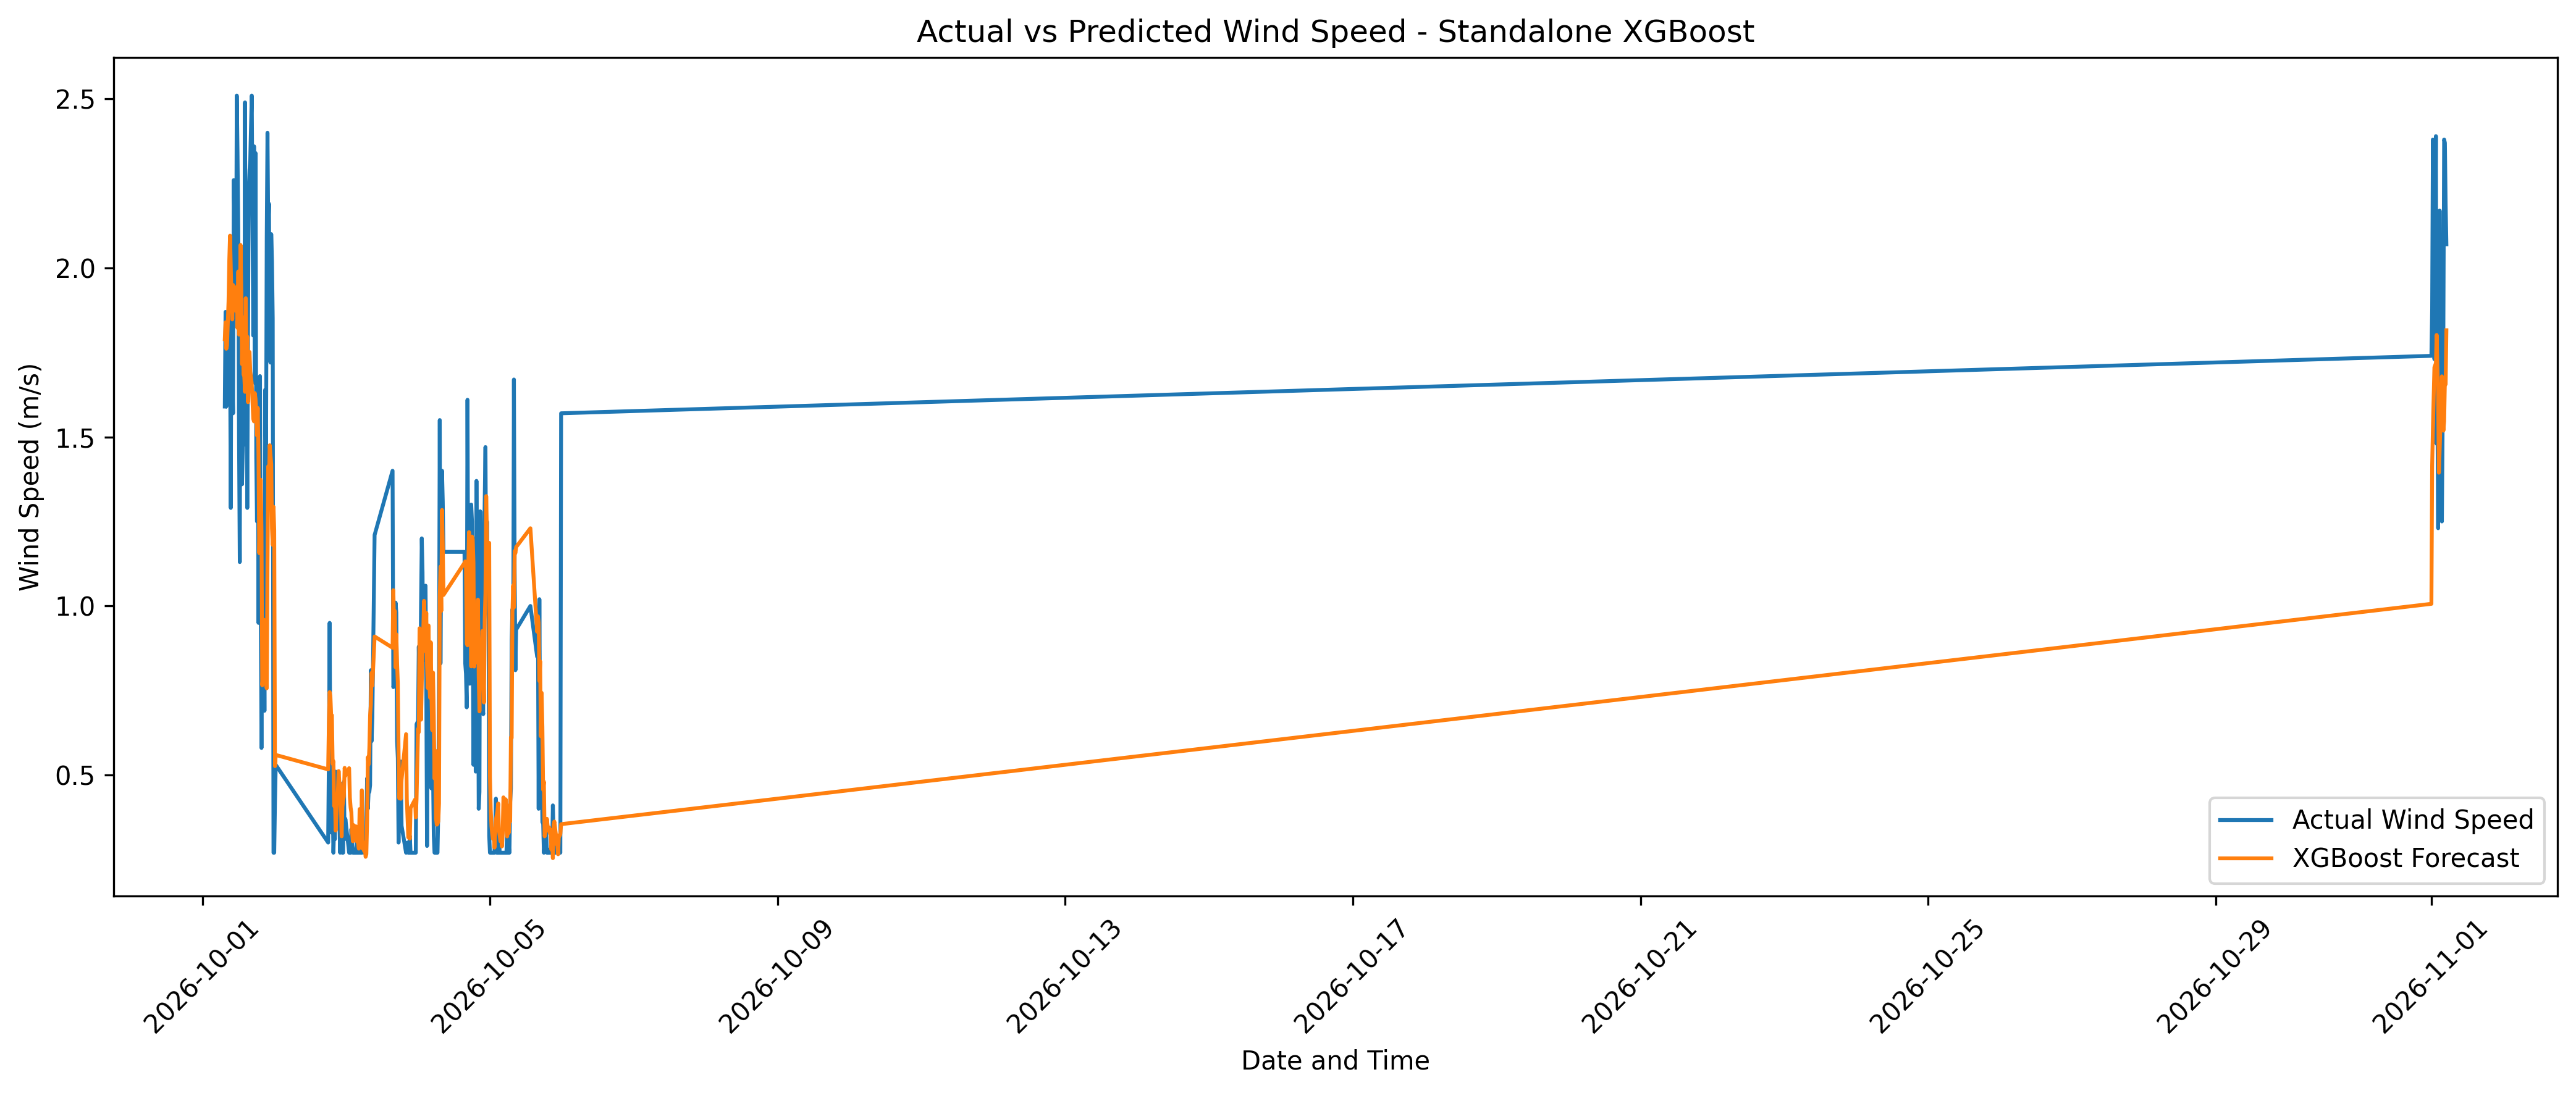

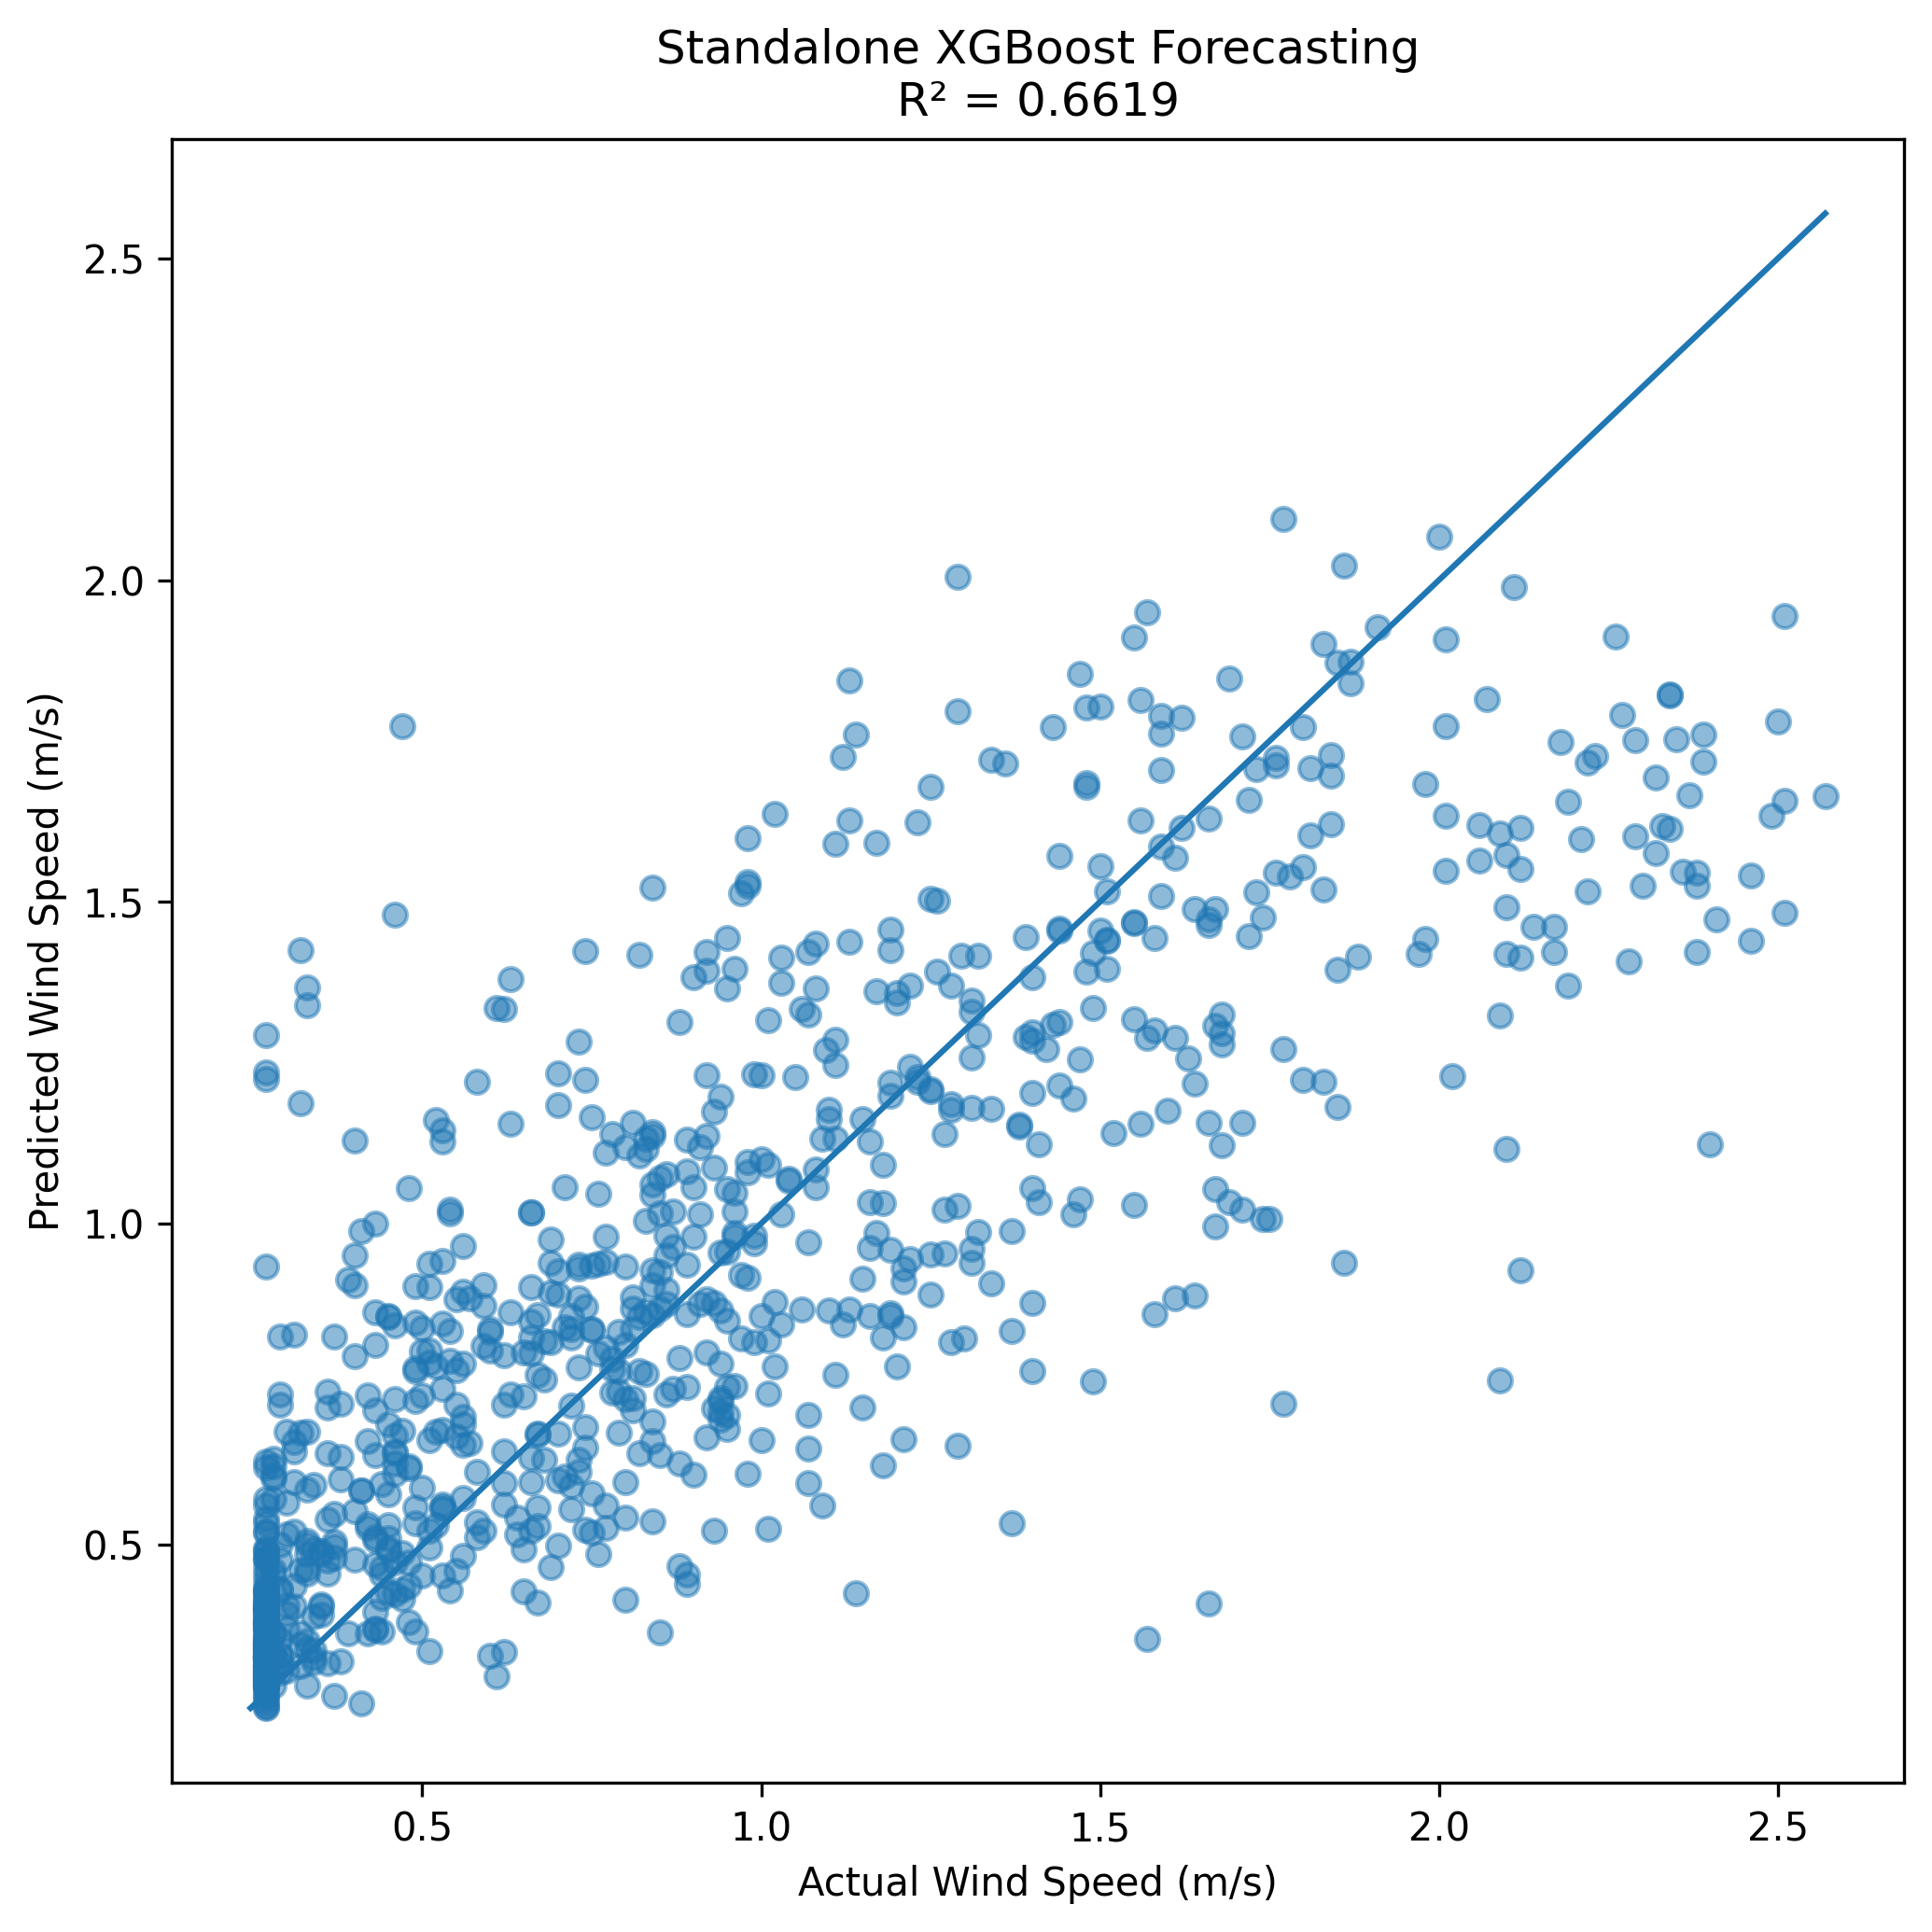

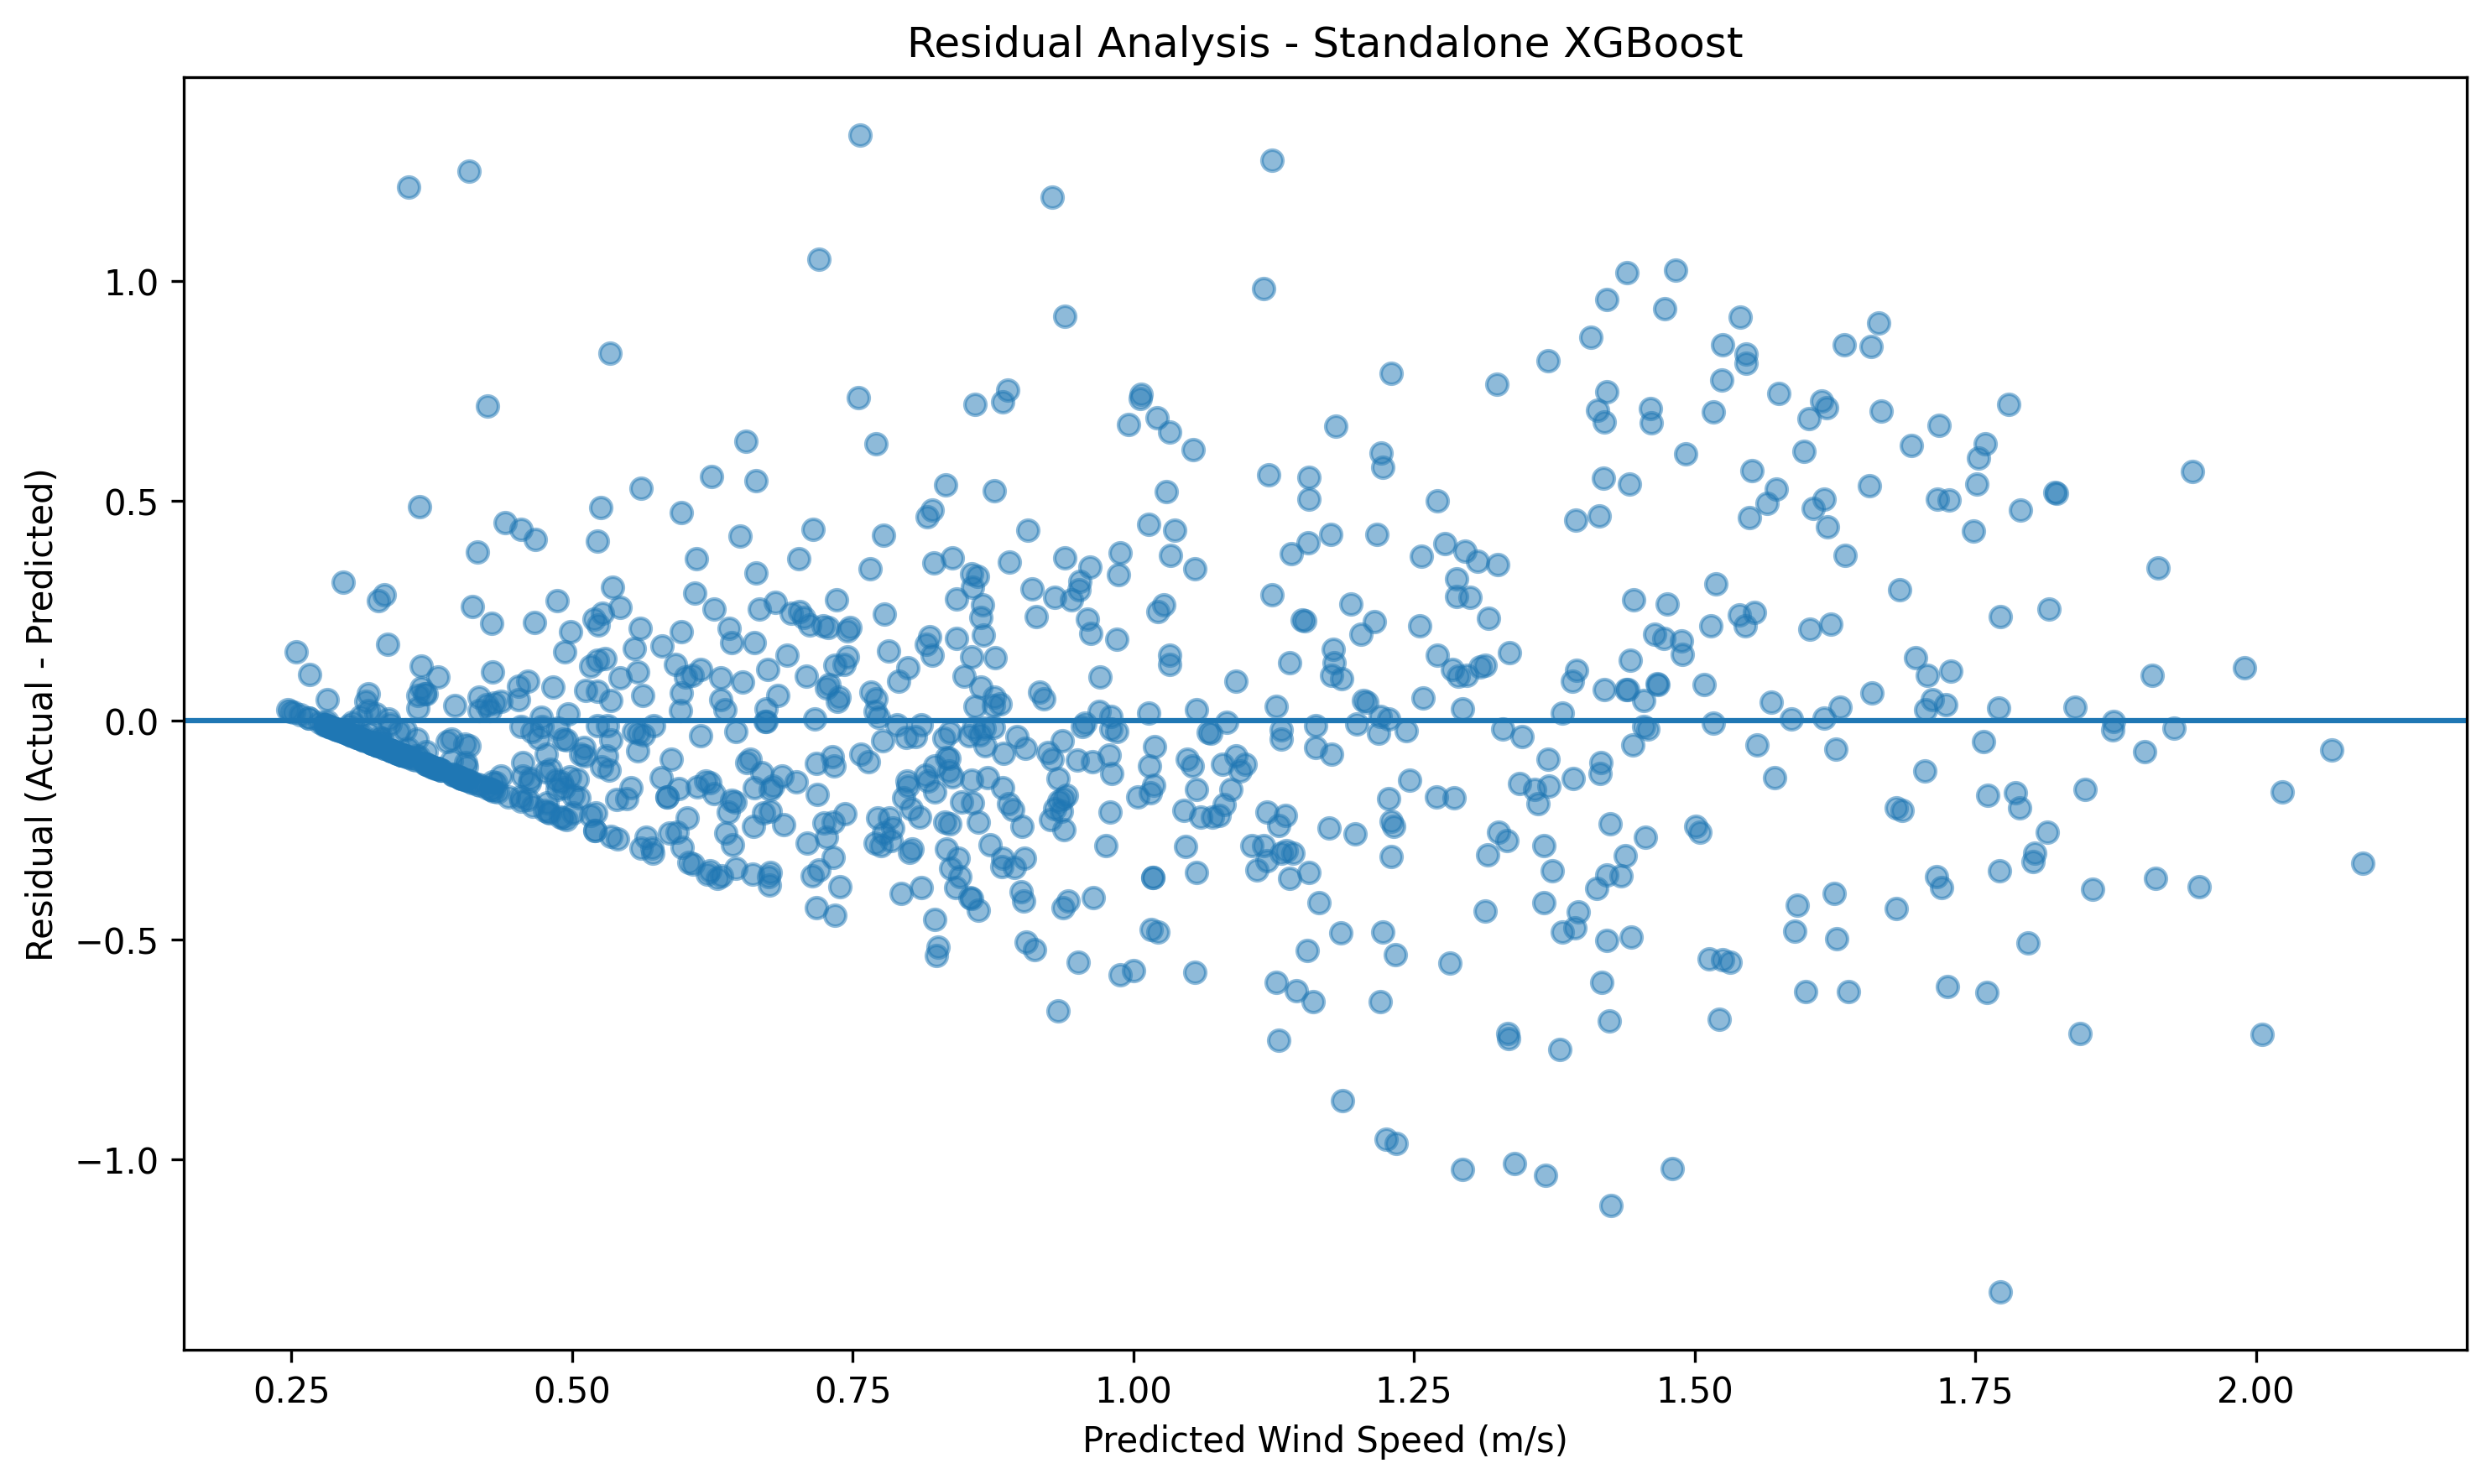

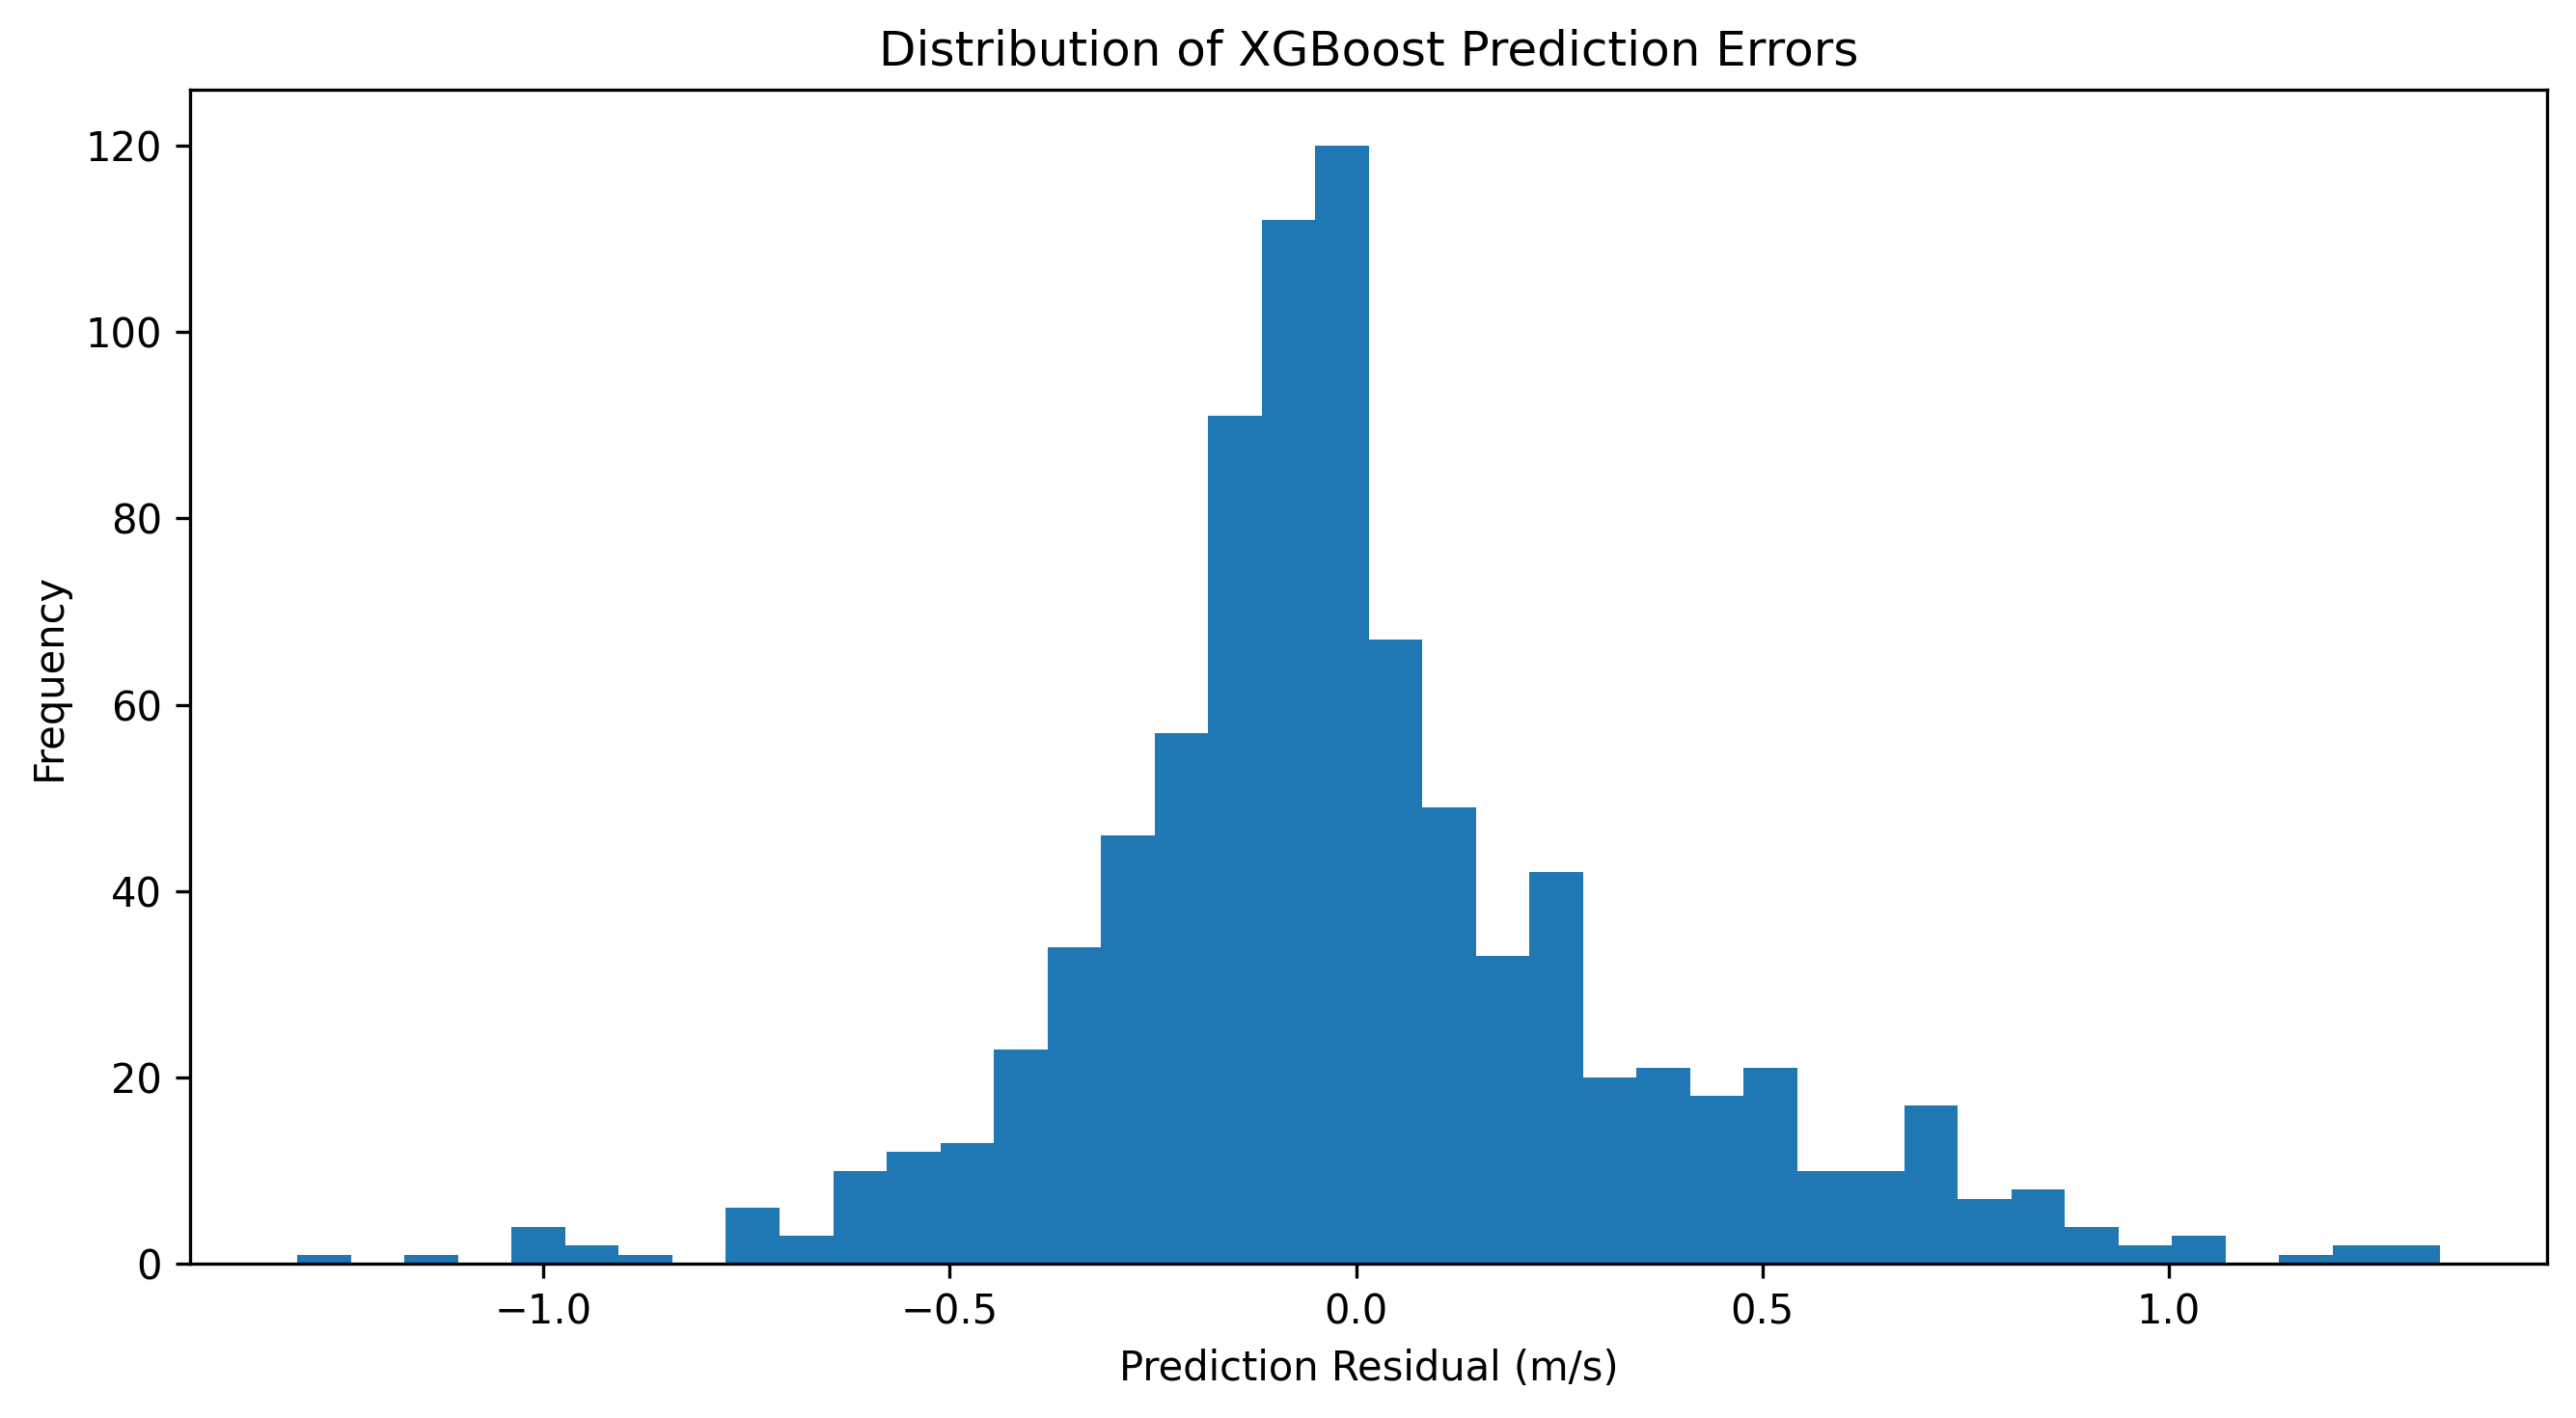


XGBOOST FEATURE IMPORTANCE
       Feature  Importance
0    WS_roll_4    0.586713
1    WS_roll_8    0.093510
2    WS_EMA_12    0.032310
3     hour_cos    0.028172
4    WS_diff_4    0.019568
5     WS_lag_1    0.019141
6    WS_EMA_24    0.016076
7   WS_diff_24    0.015744
8    WS_EMA_96    0.015161
9   WS_roll_96    0.014086
10  WS_roll_48    0.013900
11  WS_roll_12    0.013814
12    WS_lag_3    0.013611
13          SR    0.013519
14  WS_roll_24    0.013415
15    WS_lag_4    0.012870
16   WS_EMA_48    0.012085
17    WS_lag_2    0.011998
18   WS_lag_12    0.011855
19    WS_lag_8    0.011223


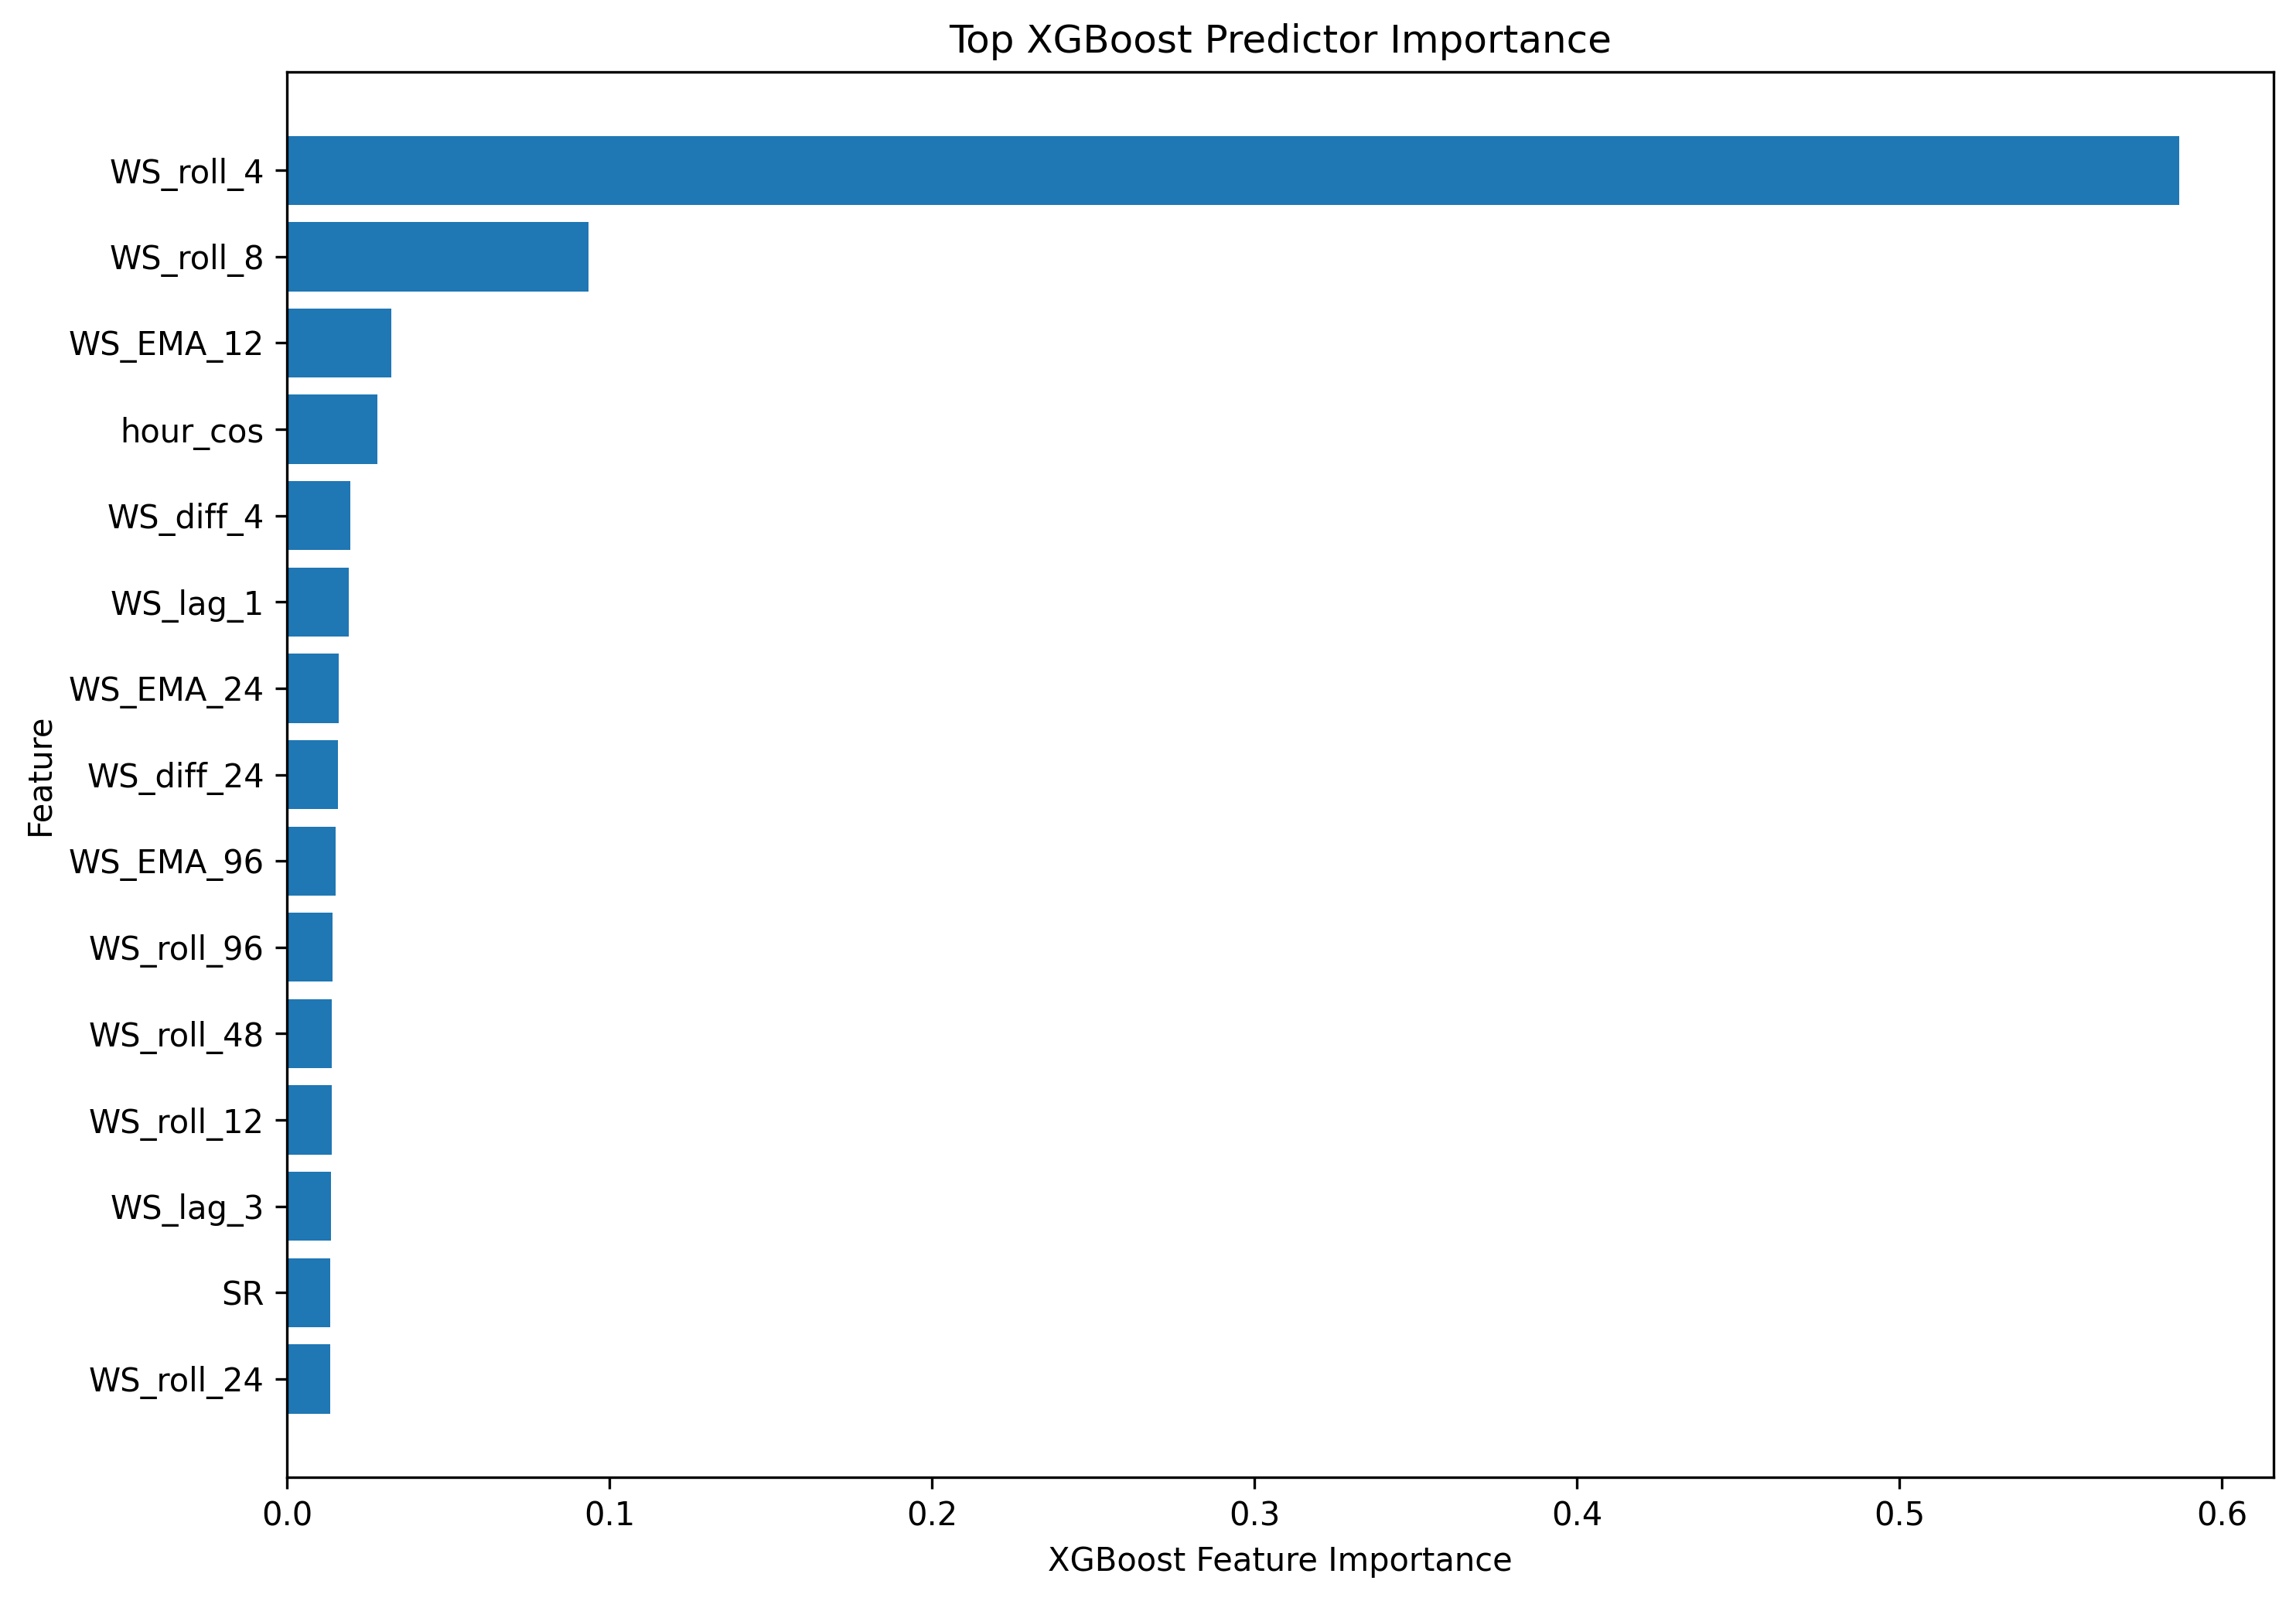


SHAP ANALYSIS
SHAP observations: 500
SHAP features: 23
SHAP calculation completed.
SHAP value shape: (500, 23)


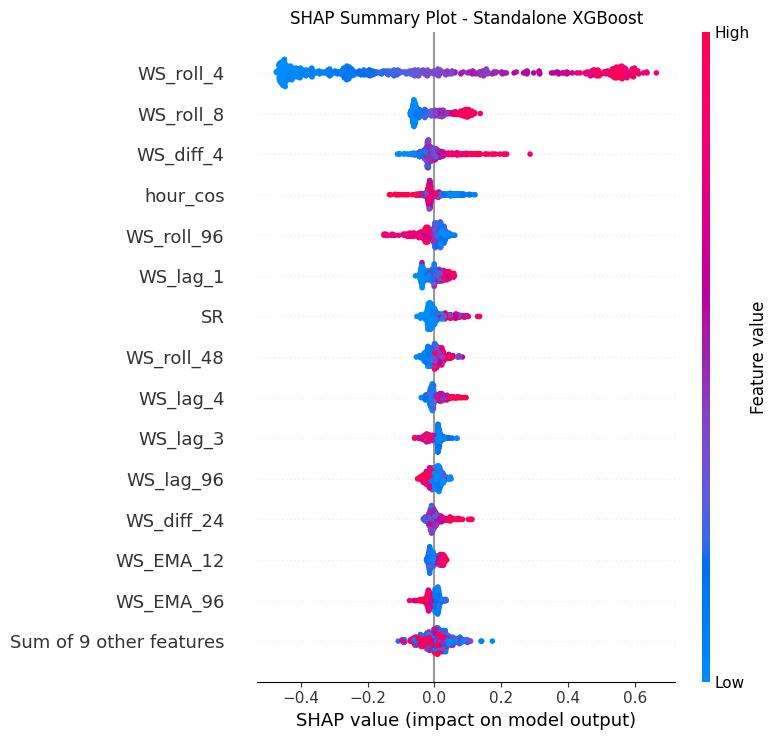

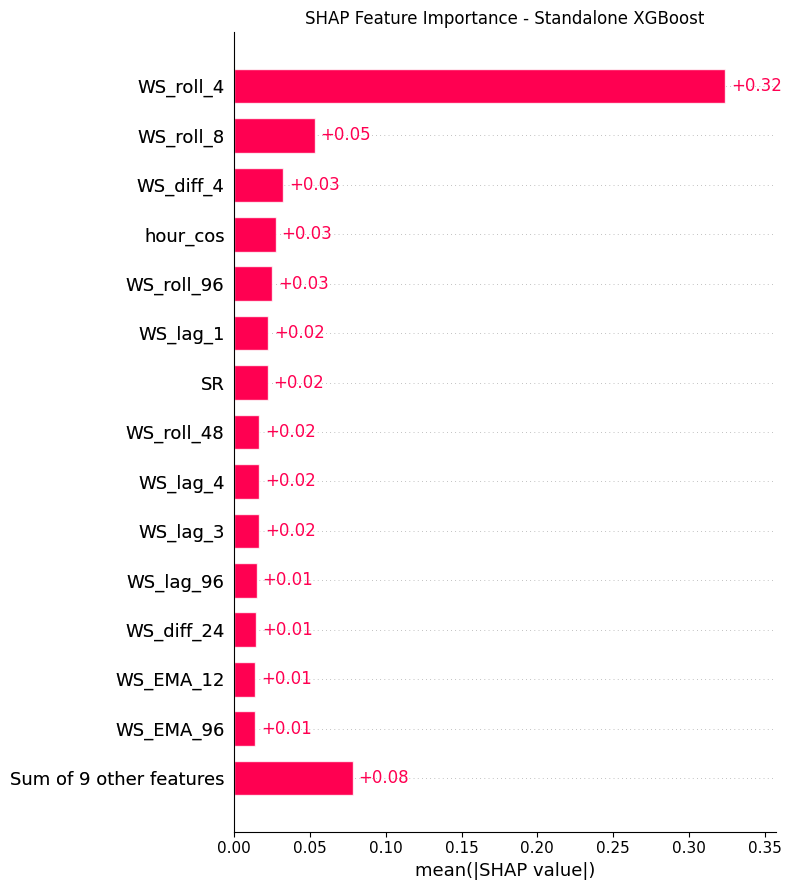

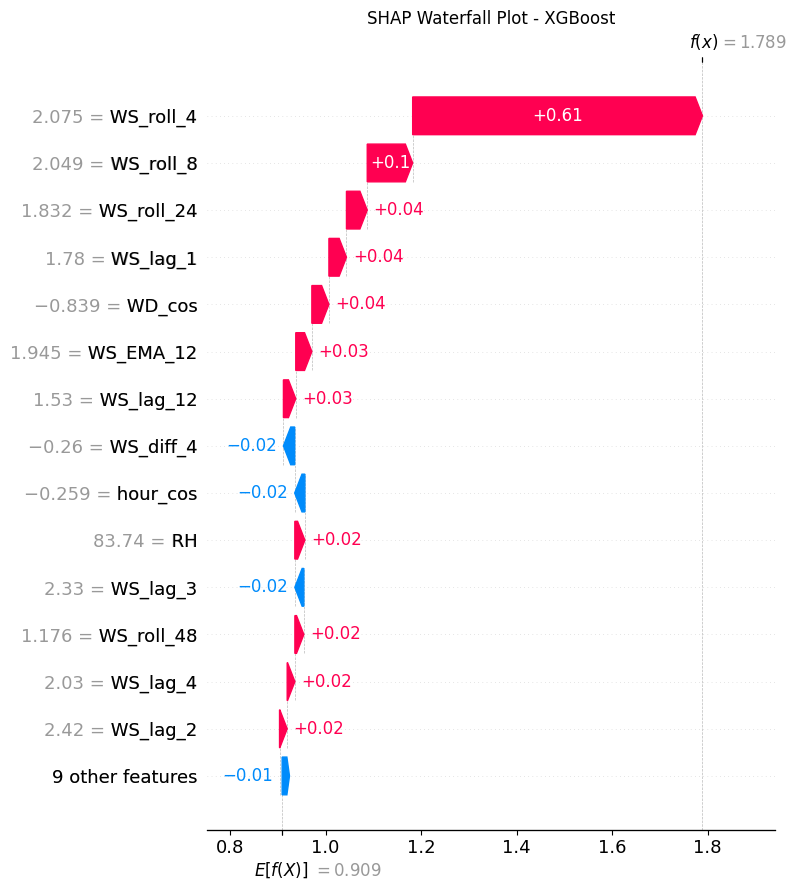


MEAN ABSOLUTE SHAP IMPORTANCE
       Feature  Mean_Absolute_SHAP
0    WS_roll_4            0.323967
1    WS_roll_8            0.053219
2    WS_diff_4            0.032481
3     hour_cos            0.027279
4   WS_roll_96            0.025206
5     WS_lag_1            0.022612
6           SR            0.022050
7   WS_roll_48            0.016631
8     WS_lag_4            0.016591
9     WS_lag_3            0.016575
10   WS_lag_96            0.014785
11  WS_diff_24            0.014450
12   WS_EMA_12            0.013951
13   WS_EMA_96            0.013721
14      WD_cos            0.013620
15  WS_roll_24            0.012865
16          RH            0.011092
17   WS_EMA_24            0.008748
18   WS_lag_12            0.008448
19    WS_lag_2            0.008003


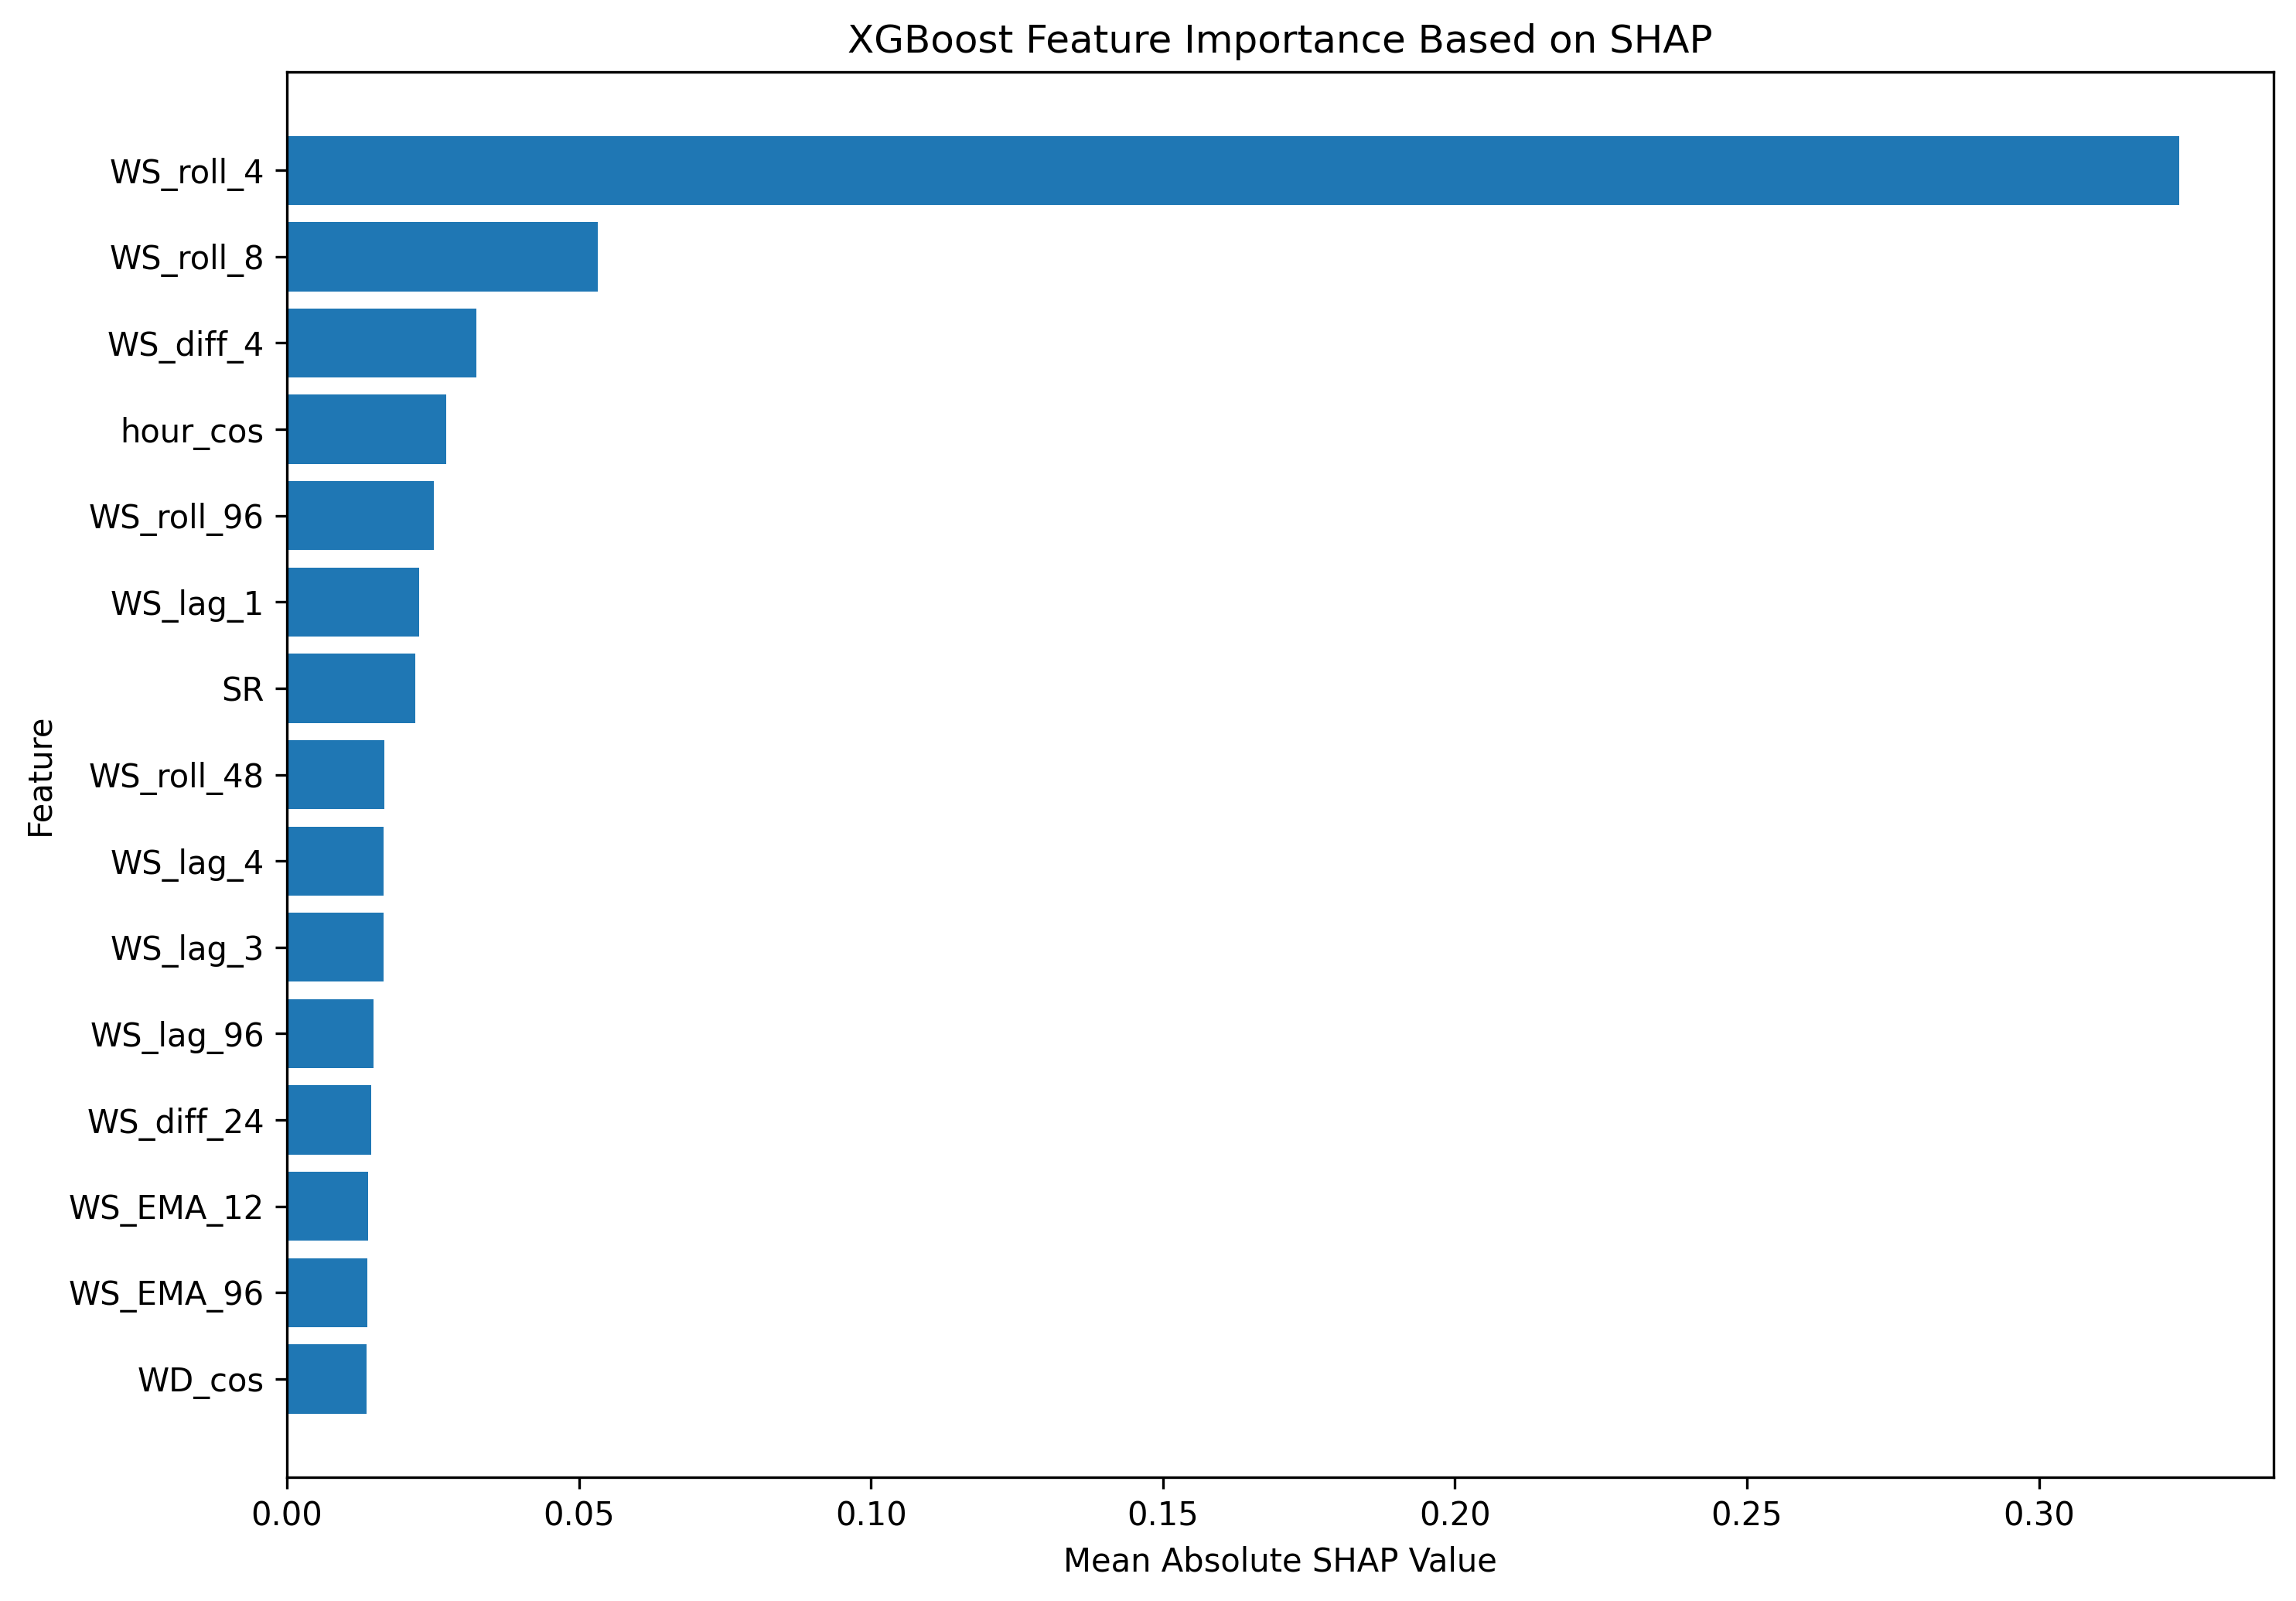


ERROR ANALYSIS BY WIND REGIME
  Wind_Regime  Number_of_Observations  Mean_Actual_WS       MAE  \
0         Low                     296        0.327095  0.168628   
1    Moderate                     286        0.763497  0.207199   
2        High                     291        1.599588  0.363266   

   Mean_Percentage_Error  
0              51.318260  
1              28.495926  
2              22.014135  

ERROR DURING WIND-SPEED CHANGES
       Change_Regime  Number_of_Observations  Mean_Absolute_Error  \
0       Rapid Change                     435             0.303128   
1  Relatively Stable                     438             0.189549   

   Mean_WS_Change  
0        0.444483  
1        0.058101  

ANALYSIS COMPLETED SUCCESSFULLY

Main outputs generated:
- standalone_xgboost_performance.csv
- standalone_xgboost_predictions.csv
- xgboost_feature_correlations.csv
- xgboost_feature_importance.csv
- xgboost_mean_absolute_shap.csv
- xgboost_error_by_wind_regime.csv
- xgboost_error_by_chan

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =========================================================
# STANDALONE XGBOOST MODEL
# 15-MINUTE-AHEAD WIND SPEED FORECASTING
# WITHOUT VMD / BiLSTM / HYBRID MODEL
# WITH SHAP EXPLAINABILITY
# =========================================================

!pip install xgboost shap -q

# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =========================================================
# 2. LOAD DATA
# =========================================================

file_path = "/content/royapuram_10Dec2025_to_10May2026_no_outliers.csv"

df = pd.read_csv(file_path)

print("Original dataset shape:", df.shape)

# Replace infinity values with NaN
df = df.replace(
    [np.inf, -np.inf],
    np.nan
)

# Convert date column
df["From_Date"] = pd.to_datetime(
    df["From_Date"],
    dayfirst=True,
    errors="coerce"
)

# Remove invalid timestamps
df = df.dropna(
    subset=["From_Date"]
)

# Sort chronologically
df = df.sort_values(
    "From_Date"
).reset_index(drop=True)

# Required original variables
required_cols = [
    "WS",
    "PM2_5",
    "PM10",
    "RH",
    "SR",
    "WD_sin",
    "WD_cos"
]

df = df.dropna(
    subset=required_cols
).reset_index(drop=True)

print(
    "Dataset shape after cleaning:",
    df.shape
)

print(
    "Start date:",
    df["From_Date"].min()
)

print(
    "End date:",
    df["From_Date"].max()
)

# =========================================================
# 3. CREATE FUTURE WIND-SPEED TARGET
# =========================================================

forecast_horizon = 1

# One time step = 15 minutes
df["WS_future"] = df["WS"].shift(
    -forecast_horizon
)

print(
    "\nForecast horizon:",
    forecast_horizon,
    "step = 15 minutes ahead"
)

# =========================================================
# 4. FEATURE ENGINEERING
# =========================================================

# =========================================================
# 4.1 LAG FEATURES
# =========================================================

lag_values = [
    1,
    2,
    3,
    4,
    8,
    12,
    24,
    48,
    96,
    192
]

for lag in lag_values:

    df[f"WS_lag_{lag}"] = (
        df["WS"].shift(lag)
    )

# =========================================================
# 4.2 ROLLING MEAN FEATURES
# =========================================================

rolling_windows = [
    4,
    8,
    12,
    24,
    48,
    96
]

for window in rolling_windows:

    df[f"WS_roll_{window}"] = (
        df["WS"]
        .rolling(
            window=window
        )
        .mean()
    )

# =========================================================
# 4.3 EXPONENTIAL MOVING AVERAGE FEATURES
# =========================================================

ema_spans = [
    12,
    24,
    48,
    96
]

for span in ema_spans:

    df[f"WS_EMA_{span}"] = (
        df["WS"]
        .ewm(
            span=span,
            adjust=False
        )
        .mean()
    )

# =========================================================
# 4.4 DIFFERENCE FEATURES
# =========================================================

df["WS_diff_1"] = (
    df["WS"] -
    df["WS_lag_1"]
)

df["WS_diff_4"] = (
    df["WS"] -
    df["WS_lag_4"]
)

df["WS_diff_24"] = (
    df["WS"] -
    df["WS_lag_24"]
)

# =========================================================
# 4.5 CYCLIC TIME FEATURES
# =========================================================

# Hour
df["hour_sin"] = np.sin(
    2 *
    np.pi *
    df["From_Date"].dt.hour /
    24
)

df["hour_cos"] = np.cos(
    2 *
    np.pi *
    df["From_Date"].dt.hour /
    24
)

# Day of year
df["day_sin"] = np.sin(
    2 *
    np.pi *
    df["From_Date"].dt.dayofyear /
    365
)

df["day_cos"] = np.cos(
    2 *
    np.pi *
    df["From_Date"].dt.dayofyear /
    365
)

# Month
df["month_sin"] = np.sin(
    2 *
    np.pi *
    df["From_Date"].dt.month /
    12
)

df["month_cos"] = np.cos(
    2 *
    np.pi *
    df["From_Date"].dt.month /
    12
)

# =========================================================
# 5. DEFINE INPUT FEATURES
# =========================================================

all_features = [

    # Meteorological variables
    "PM2_5",
    "PM10",
    "RH",
    "SR",
    "WD_sin",
    "WD_cos",

    # Lag features
    "WS_lag_1",
    "WS_lag_2",
    "WS_lag_3",
    "WS_lag_4",
    "WS_lag_8",
    "WS_lag_12",
    "WS_lag_24",
    "WS_lag_48",
    "WS_lag_96",
    "WS_lag_192",

    # Rolling mean
    "WS_roll_4",
    "WS_roll_8",
    "WS_roll_12",
    "WS_roll_24",
    "WS_roll_48",
    "WS_roll_96",

    # EMA
    "WS_EMA_12",
    "WS_EMA_24",
    "WS_EMA_48",
    "WS_EMA_96",

    # Difference features
    "WS_diff_1",
    "WS_diff_4",
    "WS_diff_24",

    # Time features
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "month_sin",
    "month_cos"
]

target = "WS_future"

# Remove rows containing missing engineered features
df = df.dropna(
    subset=all_features + [target]
).reset_index(drop=True)

print(
    "\nDataset after feature engineering:",
    df.shape
)

print(
    "Total candidate features:",
    len(all_features)
)

# =========================================================
# 6. CHRONOLOGICAL TRAIN / TEST SPLIT
# =========================================================

split_index = int(
    len(df) * 0.80
)

train_df = df.iloc[
    :split_index
].copy()

test_df = df.iloc[
    split_index:
].copy()

print(
    "\n================================="
)

print(
    "CHRONOLOGICAL DATA SPLIT"
)

print(
    "================================="
)

print(
    "Training samples:",
    len(train_df)
)

print(
    "Testing samples:",
    len(test_df)
)

print(
    "\nTraining period:"
)

print(
    train_df["From_Date"].min(),
    "to",
    train_df["From_Date"].max()
)

print(
    "\nTesting period:"
)

print(
    test_df["From_Date"].min(),
    "to",
    test_df["From_Date"].max()
)

# =========================================================
# 7. TRAINING-ONLY CORRELATION FEATURE SELECTION
# =========================================================

train_corr = train_df[
    all_features + [target]
].corr(
    numeric_only=True
)

correlation_target = (
    train_corr[target]
    .drop(
        target
    )
    .sort_values(
        ascending=False
    )
)

print(
    "\n================================="
)

print(
    "CORRELATION WITH FUTURE WIND SPEED"
)

print(
    "================================="
)

print(
    correlation_target
)

# Threshold
correlation_threshold = 0.10

selected_features = []

for feature in all_features:

    corr_value = train_corr.loc[
        feature,
        target
    ]

    if abs(corr_value) >= correlation_threshold:

        selected_features.append(
            feature
        )

print(
    "\n================================="
)

print(
    "SELECTED FEATURES"
)

print(
    "================================="
)

for feature in selected_features:

    print(feature)

print(
    "\nNumber of selected features:",
    len(selected_features)
)

# Save correlation results
correlation_df = pd.DataFrame({

    "Feature":
        correlation_target.index,

    "Correlation":
        correlation_target.values

})

correlation_df.to_csv(
    "xgboost_feature_correlations.csv",
    index=False
)

# =========================================================
# 8. CREATE TRAIN / TEST MATRICES
# =========================================================

X_train = train_df[
    selected_features
].copy()

y_train = train_df[
    target
].copy()

X_test = test_df[
    selected_features
].copy()

y_test = test_df[
    target
].copy()

test_dates = test_df[
    "From_Date"
].copy()

# Force all XGBoost predictors to numeric float
X_train = X_train.astype(float)

X_test = X_test.astype(float)

y_train = y_train.astype(float)

y_test = y_test.astype(float)

print(
    "\nX_train shape:",
    X_train.shape
)

print(
    "X_test shape:",
    X_test.shape
)

# =========================================================
# 9. XGBOOST MODEL
# =========================================================

xgb_model = XGBRegressor(

    n_estimators=3000,

    learning_rate=0.01,

    max_depth=8,

    subsample=0.85,

    colsample_bytree=0.85,

    min_child_weight=1,

    gamma=0,

    reg_alpha=0.1,

    reg_lambda=1.0,

    objective="reg:squarederror",

    random_state=42,

    n_jobs=-1,

    enable_categorical=False
)

print(
    "\n================================="
)

print(
    "TRAINING XGBOOST MODEL"
)

print(
    "================================="
)

# =========================================================
# 10. MODEL TRAINING
# =========================================================

xgb_model.fit(
    X_train,
    y_train
)

print(
    "XGBoost training completed successfully."
)

# =========================================================
# 11. MODEL PREDICTION
# =========================================================

xgb_pred = xgb_model.predict(
    X_test
)

print(
    "Prediction completed."
)

# =========================================================
# 12. MODEL EVALUATION
# =========================================================

mae = mean_absolute_error(
    y_test,
    xgb_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

r2 = r2_score(
    y_test,
    xgb_pred
)

# =========================================================
# MAPE
# =========================================================

y_true_array = y_test.values

safe_denominator = np.where(
    np.abs(y_true_array) < 1e-8,
    1e-8,
    np.abs(y_true_array)
)

percentage_error = (
    np.abs(
        y_true_array -
        xgb_pred
    )
    /
    safe_denominator
) * 100

mape = np.mean(
    percentage_error
)

# =========================================================
# ±10% AND ±20% ACCURACY
# =========================================================

accuracy_10 = (
    np.mean(
        percentage_error <= 10
    ) *
    100
)

accuracy_20 = (
    np.mean(
        percentage_error <= 20
    ) *
    100
)

print(
    "\n=========================================="
)

print(
    "STANDALONE XGBOOST PERFORMANCE"
)

print(
    "=========================================="
)

print(
    "MAE                :",
    round(mae, 4),
    "m/s"
)

print(
    "RMSE               :",
    round(rmse, 4),
    "m/s"
)

print(
    "R²                 :",
    round(r2, 4)
)

print(
    "MAPE               :",
    round(mape, 2),
    "%"
)

print(
    "Accuracy within ±10%:",
    round(accuracy_10, 2),
    "%"
)

print(
    "Accuracy within ±20%:",
    round(accuracy_20, 2),
    "%"
)

# =========================================================
# 13. PERFORMANCE SUMMARY CSV
# =========================================================

performance_df = pd.DataFrame({

    "Model": [
        "Standalone XGBoost"
    ],

    "Forecast_Horizon": [
        "15 min"
    ],

    "MAE_m_s": [
        mae
    ],

    "RMSE_m_s": [
        rmse
    ],

    "R2": [
        r2
    ],

    "MAPE_percent": [
        mape
    ],

    "Accuracy_within_10_percent": [
        accuracy_10
    ],

    "Accuracy_within_20_percent": [
        accuracy_20
    ]

})

performance_df.to_csv(
    "standalone_xgboost_performance.csv",
    index=False
)

print(
    "\nPerformance summary:"
)

print(
    performance_df.round(4)
)

# =========================================================
# 14. SAVE INDIVIDUAL PREDICTIONS
# =========================================================

prediction_results = pd.DataFrame({

    "Date_Time":
        test_dates.values,

    "Actual_WS":
        y_test.values,

    "XGBoost_Predicted_WS":
        xgb_pred,

    "Absolute_Error":
        np.abs(
            y_test.values -
            xgb_pred
        ),

    "Percentage_Error":
        percentage_error
})

prediction_results.to_csv(
    "standalone_xgboost_predictions.csv",
    index=False
)

# =========================================================
# 15. ACTUAL VS PREDICTED PLOT
# =========================================================

plot_samples = min(
    300,
    len(y_test)
)

plt.figure(
    figsize=(14, 6),
    dpi=300
)

plt.plot(
    test_dates.iloc[:plot_samples],
    y_test.iloc[:plot_samples],
    label="Actual Wind Speed"
)

plt.plot(
    test_dates.iloc[:plot_samples],
    xgb_pred[:plot_samples],
    label="XGBoost Forecast"
)

plt.xlabel(
    "Date and Time"
)

plt.ylabel(
    "Wind Speed (m/s)"
)

plt.title(
    "Actual vs Predicted Wind Speed - Standalone XGBoost"
)

plt.xticks(
    rotation=45
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "xgboost_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# 16. SCATTER PLOT
# =========================================================

plt.figure(
    figsize=(7, 7),
    dpi=300
)

plt.scatter(
    y_test,
    xgb_pred,
    alpha=0.5
)

min_value = min(
    y_test.min(),
    np.min(xgb_pred)
)

max_value = max(
    y_test.max(),
    np.max(xgb_pred)
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value]
)

plt.xlabel(
    "Actual Wind Speed (m/s)"
)

plt.ylabel(
    "Predicted Wind Speed (m/s)"
)

plt.title(
    f"Standalone XGBoost Forecasting\nR² = {r2:.4f}"
)

plt.tight_layout()

plt.savefig(
    "xgboost_scatter_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# 17. RESIDUAL ANALYSIS
# =========================================================

residuals = (
    y_test.values -
    xgb_pred
)

plt.figure(
    figsize=(10, 6),
    dpi=300
)

plt.scatter(
    xgb_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0
)

plt.xlabel(
    "Predicted Wind Speed (m/s)"
)

plt.ylabel(
    "Residual (Actual - Predicted)"
)

plt.title(
    "Residual Analysis - Standalone XGBoost"
)

plt.tight_layout()

plt.savefig(
    "xgboost_residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# 18. ERROR DISTRIBUTION
# =========================================================

plt.figure(
    figsize=(9, 5),
    dpi=300
)

plt.hist(
    residuals,
    bins=40
)

plt.xlabel(
    "Prediction Residual (m/s)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Distribution of XGBoost Prediction Errors"
)

plt.tight_layout()

plt.savefig(
    "xgboost_error_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# 19. XGBOOST BUILT-IN FEATURE IMPORTANCE
# =========================================================

feature_importance_df = pd.DataFrame({

    "Feature":
        selected_features,

    "Importance":
        xgb_model.feature_importances_

})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

print(
    "\n================================="
)

print(
    "XGBOOST FEATURE IMPORTANCE"
)

print(
    "================================="
)

print(
    feature_importance_df.head(20)
)

feature_importance_df.to_csv(
    "xgboost_feature_importance.csv",
    index=False
)

# =========================================================
# 20. FEATURE IMPORTANCE PLOT
# =========================================================

top_n = min(
    15,
    len(feature_importance_df)
)

top_features = (
    feature_importance_df
    .head(top_n)
    .sort_values(
        "Importance",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 7),
    dpi=300
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel(
    "XGBoost Feature Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top XGBoost Predictor Importance"
)

plt.tight_layout()

plt.savefig(
    "xgboost_feature_importance_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# 21. SHAP EXPLAINABILITY ANALYSIS
# =========================================================

print(
    "\n=========================================="
)

print(
    "SHAP ANALYSIS"
)

print(
    "=========================================="
)

# Use numerical copies
X_train_shap = (
    X_train
    .copy()
    .astype(float)
)

X_test_shap = (
    X_test
    .copy()
    .astype(float)
)

# Use maximum 500 observations
shap_sample_size = min(
    500,
    len(X_test_shap)
)

X_shap = (
    X_test_shap
    .iloc[:shap_sample_size]
    .copy()
)

print(
    "SHAP observations:",
    X_shap.shape[0]
)

print(
    "SHAP features:",
    X_shap.shape[1]
)

# =========================================================
# TREE EXPLAINER
# =========================================================

explainer = shap.TreeExplainer(
    xgb_model,
    feature_perturbation="tree_path_dependent"
)

shap_values = explainer(
    X_shap
)

print(
    "SHAP calculation completed."
)

print(
    "SHAP value shape:",
    shap_values.values.shape
)

# =========================================================
# 22. SHAP BEESWARM PLOT
# =========================================================

shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False
)

plt.title(
    "SHAP Summary Plot - Standalone XGBoost"
)

plt.tight_layout()

plt.savefig(
    "xgboost_shap_beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# 23. SHAP BAR PLOT
# =========================================================

shap.plots.bar(
    shap_values,
    max_display=15,
    show=False
)

plt.title(
    "SHAP Feature Importance - Standalone XGBoost"
)

plt.tight_layout()

plt.savefig(
    "xgboost_shap_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# 24. SHAP WATERFALL PLOT
# =========================================================

shap.plots.waterfall(
    shap_values[0],
    max_display=15,
    show=False
)

plt.title(
    "SHAP Waterfall Plot - XGBoost"
)

plt.tight_layout()

plt.savefig(
    "xgboost_shap_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# 25. MEAN ABSOLUTE SHAP VALUES
# =========================================================

mean_abs_shap = (
    np.abs(
        shap_values.values
    )
    .mean(
        axis=0
    )
)

shap_importance_df = pd.DataFrame({

    "Feature":
        X_shap.columns,

    "Mean_Absolute_SHAP":
        mean_abs_shap
})

shap_importance_df = (
    shap_importance_df
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

print(
    "\n================================="
)

print(
    "MEAN ABSOLUTE SHAP IMPORTANCE"
)

print(
    "================================="
)

print(
    shap_importance_df.head(20)
)

shap_importance_df.to_csv(
    "xgboost_mean_absolute_shap.csv",
    index=False
)

# =========================================================
# 26. MEAN ABSOLUTE SHAP BAR CHART
# =========================================================

top_n = min(
    15,
    len(shap_importance_df)
)

top_shap = (
    shap_importance_df
    .head(top_n)
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 7),
    dpi=300
)

plt.barh(
    top_shap["Feature"],
    top_shap["Mean_Absolute_SHAP"]
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "XGBoost Feature Importance Based on SHAP"
)

plt.tight_layout()

plt.savefig(
    "xgboost_mean_absolute_shap_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# 27. ERROR STRATIFICATION BY WIND-SPEED REGIME
# =========================================================
# Useful for reviewer comment regarding conditions where
# larger forecast errors occur.
# =========================================================

error_analysis_df = pd.DataFrame({

    "Actual_WS":
        y_test.values,

    "Predicted_WS":
        xgb_pred,

    "Absolute_Error":
        np.abs(
            y_test.values -
            xgb_pred
        ),

    "Percentage_Error":
        percentage_error
})

# Divide observed WS into three data-driven regimes
error_analysis_df[
    "Wind_Regime"
] = pd.qcut(
    error_analysis_df[
        "Actual_WS"
    ],
    q=3,
    labels=[
        "Low",
        "Moderate",
        "High"
    ],
    duplicates="drop"
)

regime_results = (
    error_analysis_df
    .groupby(
        "Wind_Regime",
        observed=True
    )
    .agg(

        Number_of_Observations=(
            "Actual_WS",
            "count"
        ),

        Mean_Actual_WS=(
            "Actual_WS",
            "mean"
        ),

        MAE=(
            "Absolute_Error",
            "mean"
        ),

        Mean_Percentage_Error=(
            "Percentage_Error",
            "mean"
        )
    )
    .reset_index()
)

print(
    "\n================================="
)

print(
    "ERROR ANALYSIS BY WIND REGIME"
)

print(
    "================================="
)

print(
    regime_results
)

regime_results.to_csv(
    "xgboost_error_by_wind_regime.csv",
    index=False
)

# =========================================================
# 28. RAPID WIND-SPEED CHANGE ANALYSIS
# =========================================================

test_analysis = test_df[
    ["From_Date", "WS", target]
].copy()

test_analysis[
    "Predicted_WS"
] = xgb_pred

test_analysis[
    "Absolute_Error"
] = np.abs(
    test_analysis[target] -
    test_analysis["Predicted_WS"]
)

test_analysis[
    "WS_Change"
] = np.abs(
    test_analysis["WS"].diff()
)

# Median used only as a descriptive split
change_threshold = (
    test_analysis[
        "WS_Change"
    ]
    .median()
)

test_analysis[
    "Change_Regime"
] = np.where(
    test_analysis[
        "WS_Change"
    ] >
    change_threshold,
    "Rapid Change",
    "Relatively Stable"
)

change_results = (
    test_analysis
    .groupby(
        "Change_Regime"
    )
    .agg(

        Number_of_Observations=(
            "Absolute_Error",
            "count"
        ),

        Mean_Absolute_Error=(
            "Absolute_Error",
            "mean"
        ),

        Mean_WS_Change=(
            "WS_Change",
            "mean"
        )
    )
    .reset_index()
)

print(
    "\n================================="
)

print(
    "ERROR DURING WIND-SPEED CHANGES"
)

print(
    "================================="
)

print(
    change_results
)

change_results.to_csv(
    "xgboost_error_by_change_regime.csv",
    index=False
)

# =========================================================
# 29. COMPLETE OUTPUT SUMMARY
# =========================================================

print(
    "\n=========================================="
)

print(
    "ANALYSIS COMPLETED SUCCESSFULLY"
)

print(
    "=========================================="
)

print(
    "\nMain outputs generated:"
)

output_files = [

    "standalone_xgboost_performance.csv",

    "standalone_xgboost_predictions.csv",

    "xgboost_feature_correlations.csv",

    "xgboost_feature_importance.csv",

    "xgboost_mean_absolute_shap.csv",

    "xgboost_error_by_wind_regime.csv",

    "xgboost_error_by_change_regime.csv",

    "xgboost_actual_vs_predicted.png",

    "xgboost_scatter_plot.png",

    "xgboost_residual_plot.png",

    "xgboost_error_distribution.png",

    "xgboost_feature_importance_plot.png",

    "xgboost_shap_beeswarm.png",

    "xgboost_shap_bar.png",

    "xgboost_shap_waterfall.png",

    "xgboost_mean_absolute_shap_plot.png"
]

for output_file in output_files:

    print(
        "-",
        output_file
    )

# =========================================================
# 30. DOWNLOAD OUTPUT FILES IN GOOGLE COLAB
# =========================================================

try:

    from google.colab import files

    for output_file in output_files:

        try:

            files.download(
                output_file
            )

        except Exception as e:

            print(
                "Could not download:",
                output_file
            )

except:

    print(
        "\nAutomatic download is available only in Google Colab."
    )